**Download the UniProt/Swiss-Prot enzyme dataset (TSV + FASTA)**

This cell downloads a trusted dataset from UniProtKB/Swiss-Prot for my project: predicting EC level-2 enzyme classes from protein sequences.

**What it does**

* Queries UniProt for reviewed proteins that have an EC annotation and are not fragments: reviewed:true AND ec:* AND fragment:false

* Downloads two files using the UniProt REST API (with proper pagination):

  1.  swissprot_ec.tsv → metadata/labels (accession, EC number, protein name organism, length)

  2.  swissprot_ec.fasta → amino-acid sequences for the same entries

**Why this is needed**

The TSV provides the ground-truth labels (EC numbers).

The FASTA provides the model input (protein sequences).

Together, they form the raw dataset that was later cleaned, filter to EC level-2 single-label, and split using similarity-aware clustering (to avoid inflated results).

**Output files created**

* swissprot_ec.tsv

* swissprot_ec.fasta

In [ ]:
!pip install -U pandas biopython

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 60.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 96.8 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.2 which is incompatible.
dask-cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.2 which is incompatible.
bqplot 0.12.45 requires pandas<3.0.0,>=1.0.0, but you have pandas 3.0.2 which is incompatible.
cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.2 which is incompatible.
db-dtypes 1.5.1 requires pandas<3.0.0,>=1.5.3, but you 

In [ ]:
from google.colab import drive
import os
import re
import glob
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from Bio import SeqIO
from urllib.parse import urlencode

In [ ]:
# Connect to google drive

drive.mount("/content/drive")

PROJECT = "/content/drive/MyDrive/MSc_Protein_EC_Project"
os.makedirs(PROJECT, exist_ok=True)

print("Project folder:", PROJECT)

Mounted at /content/drive
Project folder: /content/drive/MyDrive/MSc_Protein_EC_Project


**IBM Colorblind Safe Palette**

In [ ]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

# Colorblind-safe palette
COLORS = {
    "blue":   "#0072B2",
    "orange": "#E69F00",
    "green":  "#009E73",
    "red":    "#D55E00",
    "purple": "#CC79A7",
    "yellow": "#F0E442",
    "sky":    "#56B4E9",
    "black":  "#000000"
}

# Global plot style
mpl.rcParams.update({
    "figure.dpi":        150,
    "figure.facecolor":  "white",
    "axes.facecolor":    "white",
    "axes.grid":         True,
    "grid.alpha":        0.3,
    "grid.color":        "#cccccc",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "font.family":       "DejaVu Sans",
    "font.size":         11,
    "axes.titlesize":    13,
    "axes.titleweight":  "bold",
    "axes.labelsize":    11,
    "xtick.labelsize":   9,
    "ytick.labelsize":   9,
    "legend.frameon":    True,
    "legend.framealpha": 0.9,
    "legend.fontsize":   10,
})

**PART A**

In [ ]:

BASE = "https://rest.uniprot.org/uniprotkb/search"
QUERY = "reviewed:true AND ec:* AND fragment:false"

# Choose return UniProt fields
FIELDS = [
    "accession",
    "ec",
    "protein_name",
    "organism_name",
    "length",
]

def download_all(url, out_path, chunk_size=1024*1024):
    """
    Downloads all pages from UniProt REST API using Link-header pagination.
    Writes bytes to out_path.
    """
    session = requests.Session()
    next_url = url
    with open(out_path, "wb") as f:
        while next_url:
            r = session.get(next_url, timeout=60)
            r.raise_for_status()
            f.write(r.content)

            # UniProt uses RFC5988 pagination
            link = r.headers.get("Link", "")
            m = re.search(r'<([^>]+)>;\s*rel="next"', link)
            next_url = m.group(1) if m else None

def build_url(fmt: str, fields: list[str] | None = None):
    params = {
        "query": QUERY,
        "format": fmt,
        "size": 500,
    }
    if fields:
        params["fields"] = ",".join(fields)
    # Build URL manually
    from urllib.parse import urlencode
    return f"{BASE}?{urlencode(params)}"

# 1) TSV labels table
tsv_url = build_url("tsv", FIELDS)
download_all(tsv_url, f"{PROJECT}/swissprot_ec.tsv")

# 2) FASTA sequences
fasta_url = build_url("fasta")
download_all(fasta_url, f"{PROJECT}/swissprot_ec.fasta")

print("Done: swissprot_ec.tsv and swissprot_ec.fasta")


Done: swissprot_ec.tsv and swissprot_ec.fasta


In [ ]:
# Check downloaded UniProt files

# list files
for f in sorted(glob.glob("swissprot_ec*")):
    print(f, os.path.getsize(f)/1e6, "MB")


In [ ]:
# Checking the directory

print("Current directory:", os.getcwd())
print("Files here:", os.listdir())

Current directory: /content
Files here: ['.config', 'drive', 'sample_data']


In [ ]:
# Cheking the TSV file

df_meta = df_meta = pd.read_csv(f"{PROJECT}/swissprot_ec.tsv", sep="\t")
print("Shape (rows, columns):", df_meta.shape)
df_meta.head()

Shape (rows, columns): (276615, 5)


,Entry,EC number,Protein names,Organism,Length
0,A0A1B0GTW7,3.4.24.-,Ciliated left-right organizer metallopeptidase...,Homo sapiens (Human),788
1,A1L3X0,2.3.1.199,Very long chain fatty acid elongase 7 (EC 2.3....,Homo sapiens (Human),281
2,A2RUC4,1.14.11.42,tRNA wybutosine-synthesizing protein 5 (hTYW5)...,Homo sapiens (Human),315
3,A5PLL7,1.14.19.77,Plasmanylethanolamine desaturase 1 (EC 1.14.19...,Homo sapiens (Human),270
4,C9JRZ8,1.1.1.-; 1.1.1.216; 1.1.1.300; 1.1.1.54; 1.1.1.64,Aldo-keto reductase family 1 member B15 (EC 1....,Homo sapiens (Human),316


In [ ]:
df_meta.columns.tolist()

['Entry', 'EC number', 'Protein names', 'Organism', 'Length']

In [ ]:
selected_columns = [
    "Entry",
    "Protein names",
    "EC number",
    "Length",
    "Organism"
]

df_meta_clean = df_meta[selected_columns].dropna(subset=["Entry"])
print("Clean metadata shape:", df_meta_clean.shape)
df_meta_clean.head()

Clean metadata shape: (276615, 5)


,Entry,Protein names,EC number,Length,Organism
0,A0A1B0GTW7,Ciliated left-right organizer metallopeptidase...,3.4.24.-,788,Homo sapiens (Human)
1,A1L3X0,Very long chain fatty acid elongase 7 (EC 2.3....,2.3.1.199,281,Homo sapiens (Human)
2,A2RUC4,tRNA wybutosine-synthesizing protein 5 (hTYW5)...,1.14.11.42,315,Homo sapiens (Human)
3,A5PLL7,Plasmanylethanolamine desaturase 1 (EC 1.14.19...,1.14.19.77,270,Homo sapiens (Human)
4,C9JRZ8,Aldo-keto reductase family 1 member B15 (EC 1....,1.1.1.-; 1.1.1.216; 1.1.1.300; 1.1.1.54; 1.1.1.64,316,Homo sapiens (Human)


In [ ]:
# Checking the fasta file

records = []
fasta_path = fasta_path = f"{PROJECT}/swissprot_ec.fasta"

for record in SeqIO.parse(fasta_path, "fasta"):
    records.append({
        "Entry": record.id.split("|")[1],   # UniProt accession
        "Sequence": str(record.seq),
        "Seq_Length": len(record.seq)
    })

df_seq = pd.DataFrame(records)
print("Sequence dataframe shape:", df_seq.shape)
df_seq.head()

Sequence dataframe shape: (276063, 3)


,Entry,Sequence,Seq_Length
0,A0A1B0GTW7,MLLLLLLLLLLPPLVLRVAASRCLHDETQKSVSLLRPPFSQLPSKS...,788
1,A1L3X0,MAFSDLTSRTVHLYDNWIKDADPRVEDWLLMSSPLPQTILLGFYVY...,281
2,A2RUC4,MAGQHLPVPRLEGVSREQFMQHLYPQRKPLVLEGIDLGPCTSKWTV...,315
3,A5PLL7,MAGAENWPGQQLELDEDEASCCRWGAQHAGARELAALYSPGKRLQE...,270
4,C9JRZ8,MATFVELSTKAKMPIVGLGTWRSLLGKVKEAVKVAIDAEYRHIDCA...,316


In [ ]:
df_merged = df_meta_clean.merge(
    df_seq,
    on="Entry",
    how="inner"
)

print("Merged dataset shape:", df_merged.shape)
df_merged.head()

Merged dataset shape: (276063, 7)


,Entry,Protein names,EC number,Length,Organism,Sequence,Seq_Length
0,A0A1B0GTW7,Ciliated left-right organizer metallopeptidase...,3.4.24.-,788,Homo sapiens (Human),MLLLLLLLLLLPPLVLRVAASRCLHDETQKSVSLLRPPFSQLPSKS...,788
1,A1L3X0,Very long chain fatty acid elongase 7 (EC 2.3....,2.3.1.199,281,Homo sapiens (Human),MAFSDLTSRTVHLYDNWIKDADPRVEDWLLMSSPLPQTILLGFYVY...,281
2,A2RUC4,tRNA wybutosine-synthesizing protein 5 (hTYW5)...,1.14.11.42,315,Homo sapiens (Human),MAGQHLPVPRLEGVSREQFMQHLYPQRKPLVLEGIDLGPCTSKWTV...,315
3,A5PLL7,Plasmanylethanolamine desaturase 1 (EC 1.14.19...,1.14.19.77,270,Homo sapiens (Human),MAGAENWPGQQLELDEDEASCCRWGAQHAGARELAALYSPGKRLQE...,270
4,C9JRZ8,Aldo-keto reductase family 1 member B15 (EC 1....,1.1.1.-; 1.1.1.216; 1.1.1.300; 1.1.1.54; 1.1.1.64,316,Homo sapiens (Human),MATFVELSTKAKMPIVGLGTWRSLLGKVKEAVKVAIDAEYRHIDCA...,316


In [ ]:
# Drop the TSV "Length" column
if "Length" in df_merged.columns:
    df_merged = df_merged.drop(columns=["Length"])

df_merged["Seq_Length"] = pd.to_numeric(df_merged["Seq_Length"], errors="coerce")
df_merged["Seq_Length"].dtype

dtype('int64')

**Part A(ii)**

In [ ]:
# Data cleaning and enigineering

# 1) Drop missing key fields
df_clean = df_merged.dropna(subset=["Entry", "Sequence", "EC number"]).copy()

# 2) Keep single-label EC only
def is_single_ec(x):
    s = str(x).strip()
    return (";" not in s) and ("," not in s) and (" " not in s)

df_clean = df_clean[df_clean["EC number"].apply(is_single_ec)].copy()

# 3) Extract EC level-2
def to_ec_level2(ec):
    s = str(ec).strip()
    parts = s.split(".")
    if len(parts) < 2:
        return np.nan
    if not (parts[0].isdigit() and parts[1].isdigit()):
        return np.nan
    return f"{parts[0]}.{parts[1]}"

df_clean["EC_level2"] = df_clean["EC number"].apply(to_ec_level2)
df_clean = df_clean.dropna(subset=["EC_level2"]).copy()

# 4) Sequence validity
valid = re.compile(r"^[ACDEFGHIKLMNPQRSTVWY]+$")
df_clean = df_clean[df_clean["Sequence"].str.match(valid)].copy()

# 5) Length filtering
df_clean["Seq_Length"] = df_clean["Sequence"].str.len()
MIN_LEN, MAX_LEN = 50, 1024
df_clean = df_clean[(df_clean["Seq_Length"] >= MIN_LEN) & (df_clean["Seq_Length"] <= MAX_LEN)].copy()

print("Cleaned dataset shape:", df_clean.shape)
print("Unique EC level-2 classes:", df_clean["EC_level2"].nunique())
print(df_clean["EC_level2"].value_counts().head(10))

print("Rows before any dedup:", len(df_clean))

# Remove exact duplicate rows
before = len(df_clean)
df_clean = df_clean.drop_duplicates().copy()
print(f"Removed {before - len(df_clean)} exact duplicate rows. Rows now: {len(df_clean)}")

# Remove duplicate accessions
before = len(df_clean)
df_clean = df_clean.drop_duplicates(subset=["Entry"]).copy()
print(f"Removed {before - len(df_clean)} duplicate Entry rows. Rows now: {len(df_clean)}")

# 6) Save for EDA
df_clean.to_csv(f"{PROJECT}/ec2_singlelabel_clean.csv", index=False)
print("Saved:", f"{PROJECT}/ec2_singlelabel_clean.csv")

Cleaned dataset shape: (246368, 7)
Unique EC level-2 classes: 75
EC_level2
2.7    28895
3.1    17485
2.1    17172
6.3    12616
3.6    12532
6.1    12522
2.3    11214
4.2    10300
2.4    10189
3.4     9926
Name: count, dtype: int64
Rows before any dedup: 246368
Removed 0 exact duplicate rows. Rows now: 246368
Removed 0 duplicate Entry rows. Rows now: 246368
Saved: /content/drive/MyDrive/MSc_Protein_EC_Project/ec2_singlelabel_clean.csv


In [ ]:
df_clean = pd.read_csv(f"{PROJECT}/ec2_singlelabel_clean.csv")
print(df_clean.shape)
df_clean.head()

(246368, 7)


,Entry,Protein names,EC number,Organism,Sequence,Seq_Length,EC_level2
0,A0A1B0GTW7,Ciliated left-right organizer metallopeptidase...,3.4.24.-,Homo sapiens (Human),MLLLLLLLLLLPPLVLRVAASRCLHDETQKSVSLLRPPFSQLPSKS...,788,3.40
1,A1L3X0,Very long chain fatty acid elongase 7 (EC 2.3....,2.3.1.199,Homo sapiens (Human),MAFSDLTSRTVHLYDNWIKDADPRVEDWLLMSSPLPQTILLGFYVY...,281,2.30
2,A2RUC4,tRNA wybutosine-synthesizing protein 5 (hTYW5)...,1.14.11.42,Homo sapiens (Human),MAGQHLPVPRLEGVSREQFMQHLYPQRKPLVLEGIDLGPCTSKWTV...,315,1.14
3,A5PLL7,Plasmanylethanolamine desaturase 1 (EC 1.14.19...,1.14.19.77,Homo sapiens (Human),MAGAENWPGQQLELDEDEASCCRWGAQHAGARELAALYSPGKRLQE...,270,1.14
4,O00115,Deoxyribonuclease-2-alpha (EC 3.1.22.1) (Acid ...,3.1.22.1,Homo sapiens (Human),MIPLLLAALLCVPAGALTCYGDSGQPVDWFVVYKLPALRGSGEAAQ...,360,3.10


In [ ]:
# If EC_level2 exists, EC_level1 is the first number
df_clean["EC_level1"] = df_clean["EC_level2"].astype(str).str.split(".").str[0]

# Valid level-1 digits (1–7)
df_clean = df_clean[df_clean["EC_level1"].str.match(r"^[1-7]$")].copy()

print("Unique EC level-1 classes:", sorted(df_clean["EC_level1"].unique()))

Unique EC level-1 classes: ['1', '2', '3', '4', '5', '6', '7']


In [ ]:
# EC Level-1 Distribution

ec1_counts = df_clean["EC_level1"].value_counts().sort_index()

ec1_labels = {
    "1": "Oxidoreductases",
    "2": "Transferases",
    "3": "Hydrolases",
    "4": "Lyases",
    "5": "Isomerases",
    "6": "Ligases",
    "7": "Translocases",
}

ec1_table = ec1_counts.reset_index()
ec1_table.columns = ["EC_level1", "Count"]
ec1_table["Class_Name"] = ec1_table["EC_level1"].map(ec1_labels)
print(ec1_table)

  EC_level1  Count       Class_Name
0         1  29451  Oxidoreductases
1         2  84381     Transferases
2         3  53527       Hydrolases
3         4  22621           Lyases
4         5  15254       Isomerases
5         6  27760          Ligases
6         7  13374     Translocases


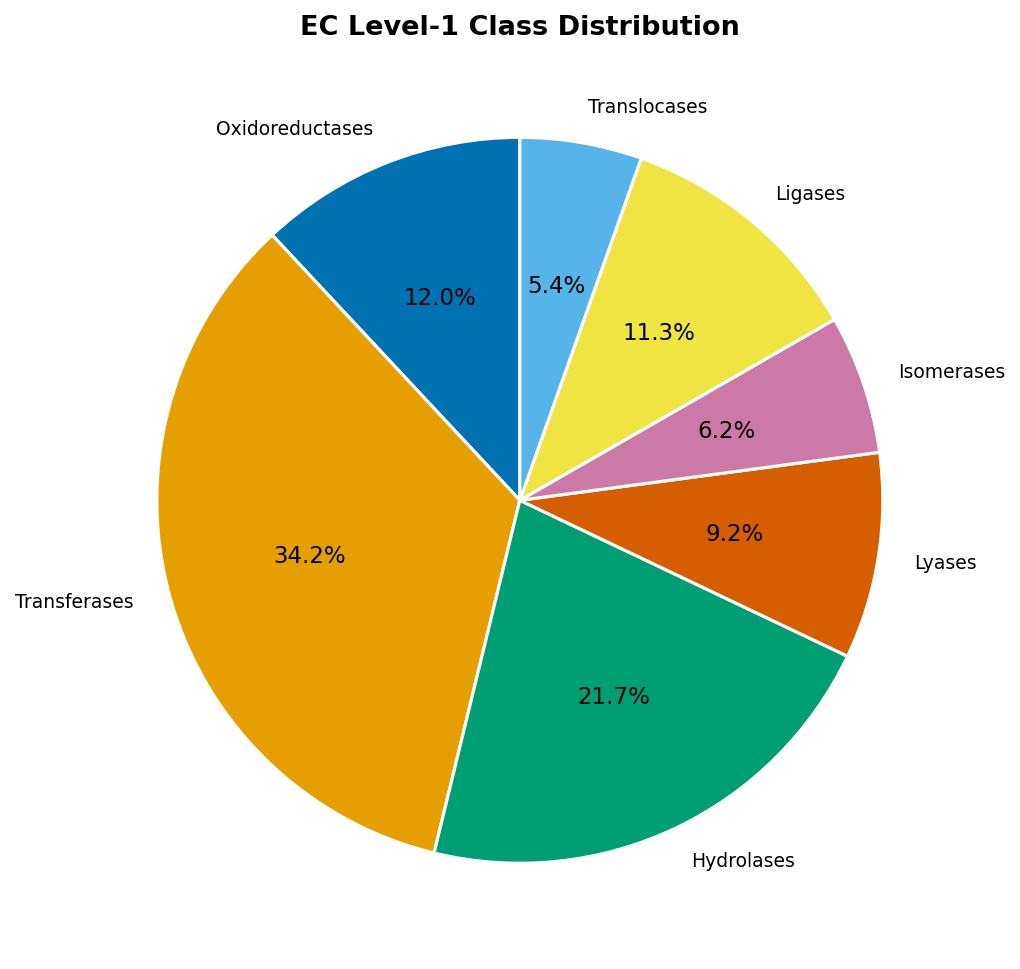

In [ ]:
# EC Level-1 Class Distribution
fig, ax = plt.subplots(figsize=(7, 7))
ax.pie(
    ec1_table["Count"],
    labels=ec1_table["Class_Name"],
    autopct="%1.1f%%",
    startangle=90,
    colors=[COLORS["blue"], COLORS["orange"], COLORS["green"],
            COLORS["red"],  COLORS["purple"], COLORS["yellow"],
            COLORS["sky"]],
    wedgeprops={"edgecolor": "white", "linewidth": 1.5}
)
ax.set_title("EC Level-1 Class Distribution")
plt.tight_layout()
plt.savefig(f"{PROJECT}/ec1_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# Human Emzyme Distribution

human_mask = df_clean["Organism"].str.contains("Homo sapiens", case=False, na=False)

human_count = human_mask.sum()
total = len(df_clean)

print(f"Human entries (Homo sapiens): {human_count} out of {total}")

Human entries (Homo sapiens): 3294 out of 246368


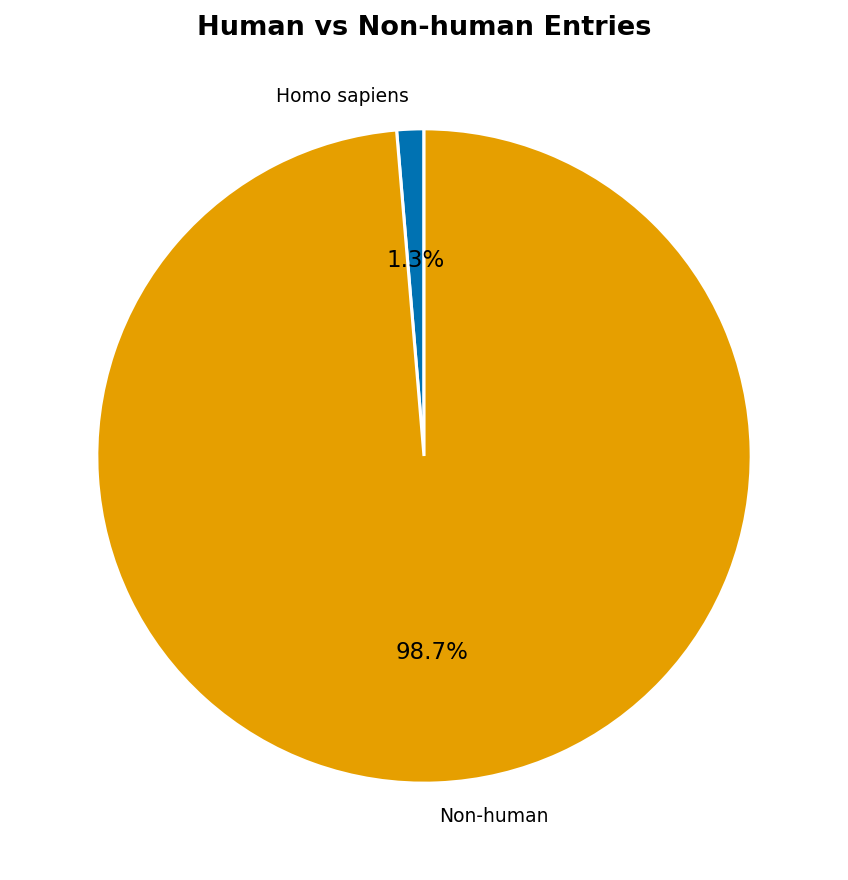

In [ ]:
non_human_count = total - human_count

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(
    [human_count, non_human_count],
    labels=["Homo sapiens", "Non-human"],
    autopct="%1.1f%%",
    startangle=90,
    colors=[COLORS["blue"], COLORS["orange"]],
    wedgeprops={"edgecolor": "white", "linewidth": 1.5}
)
ax.set_title("Human vs Non-human Entries")
plt.tight_layout()
plt.savefig(f"{PROJECT}/human_vs_nonhuman.png", dpi=150, bbox_inches="tight")
plt.show()

EC_level1
1     361
2    1327
3    1280
4      99
5     107
6      75
7      45
Name: count, dtype: int64


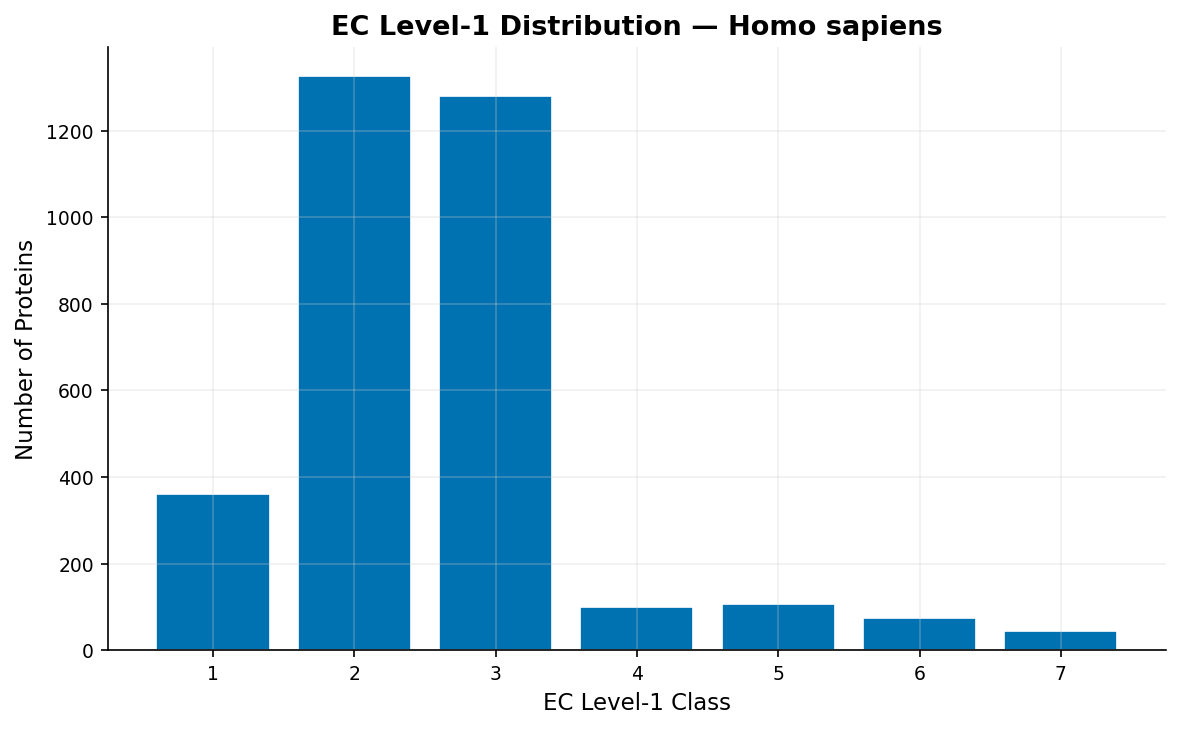

In [ ]:
# EC Level-1 Distribution for Human

human_ec1_counts = df_clean[human_mask]["EC_level1"].value_counts().sort_index()
print(human_ec1_counts)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(
    human_ec1_counts.index.astype(str),
    human_ec1_counts.values,
    color=COLORS["blue"],
    edgecolor="white",
    linewidth=0.8
)
ax.set_title("EC Level-1 Distribution — Homo sapiens")
ax.set_xlabel("EC Level-1 Class")
ax.set_ylabel("Number of Proteins")
plt.tight_layout()
plt.savefig(f"{PROJECT}/human_ec1_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# 1) Total rows after cleaning
total_rows = len(df_clean)

# 2) Number of EC level-2 classes
num_classes = df_clean["EC_level2"].nunique()

# 3) Class distribution table (top 20)
top20 = df_clean["EC_level2"].value_counts().head(20).reset_index()
top20.columns = ["EC_level2", "Count"]

# 4) Sequence length summary
df_clean["Seq_Length"] = pd.to_numeric(df_clean["Seq_Length"], errors="coerce")
length_summary = df_clean["Seq_Length"].describe()

print("Total rows after cleaning:", total_rows)
print("Number of EC level-2 classes:", num_classes)
print("\nTop 20 EC level-2 classes:")
print(top20.to_string(index=False))
print("\nSequence length summary:")
print(length_summary)

Total rows after cleaning: 246368
Number of EC level-2 classes: 71

Top 20 EC level-2 classes:
 EC_level2  Count
      2.70  28895
      3.10  17486
      2.10  17191
      6.30  12616
      3.60  12532
      6.10  12522
      2.30  11214
      4.20  10300
      2.40  10189
      3.40   9926
      7.10   8902
      3.50   8334
      1.10   8116
      2.50   8107
      4.10   7392
      2.80   5021
      5.30   4685
      5.40   4653
      3.20   4573
      1.14   4002

Sequence length summary:
count    246368.000000
mean        374.569924
std         176.966403
min          50.000000
25%         248.000000
50%         344.000000
75%         463.000000
max        1024.000000
Name: Seq_Length, dtype: float64


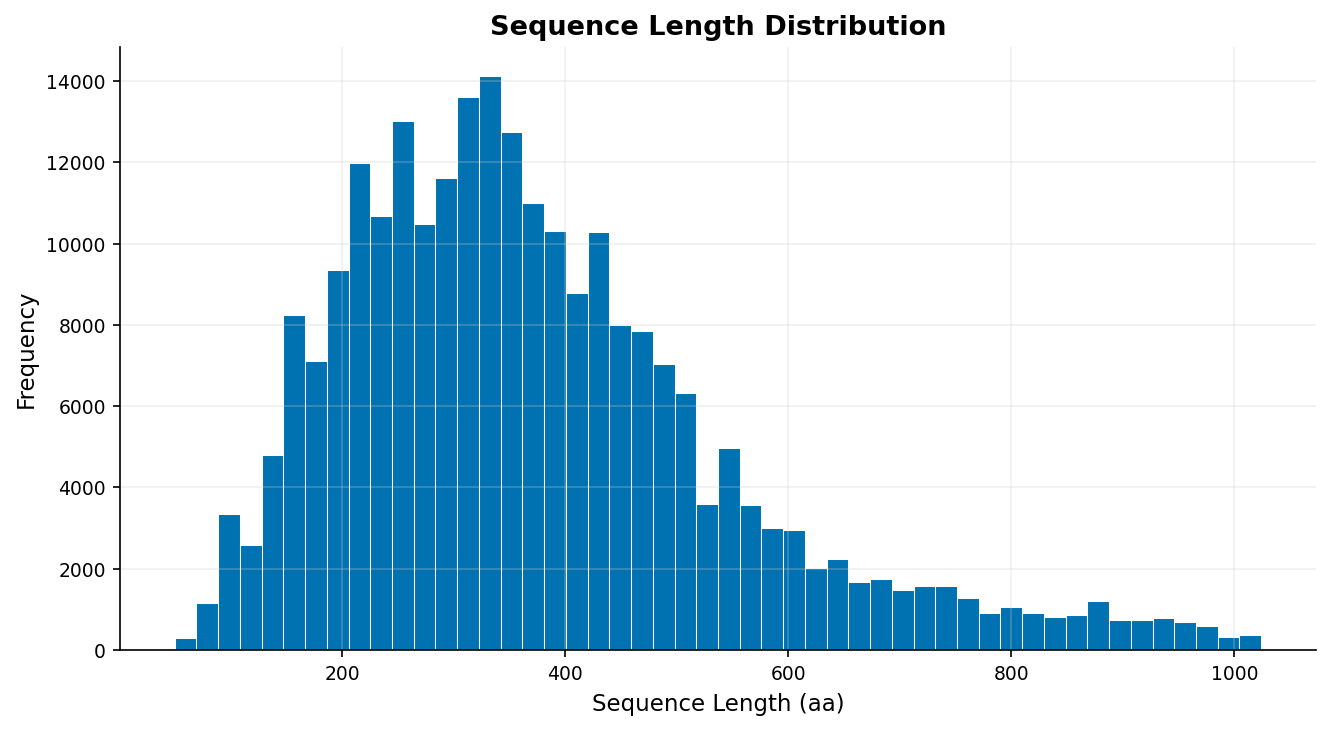

In [ ]:
# Sequence Length Distribution

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(
    df_clean["Seq_Length"].dropna(),
    bins=50,
    color=COLORS["blue"],
    edgecolor="white",
    linewidth=0.5
)
ax.set_title("Sequence Length Distribution")
ax.set_xlabel("Sequence Length (aa)")
ax.set_ylabel("Frequency")
plt.tight_layout()
plt.savefig(f"{PROJECT}/sequence_length_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

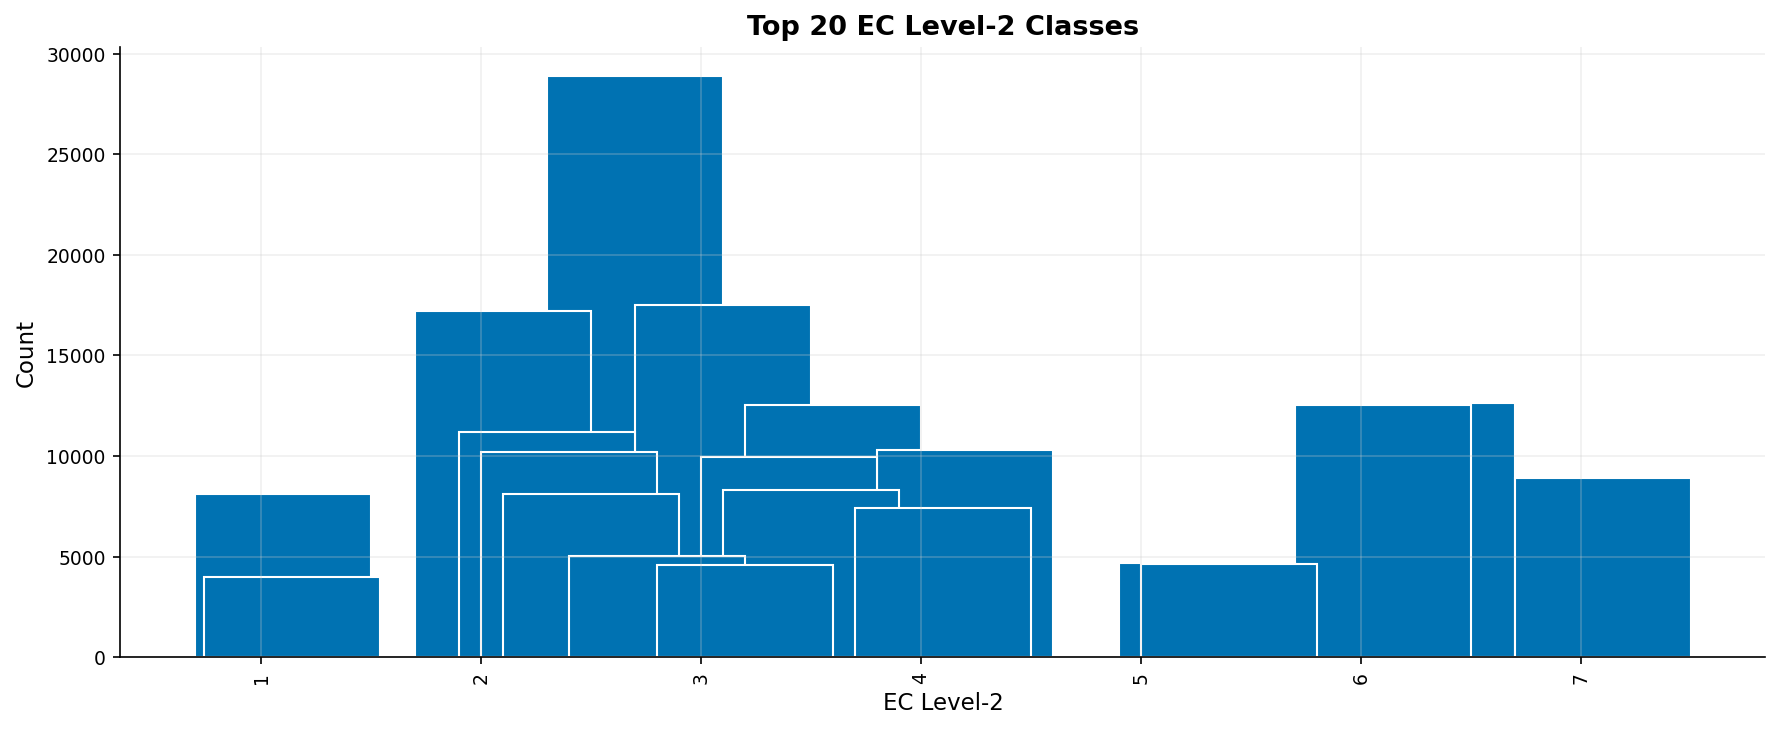

In [ ]:
# Top 20 EC level-2 Classes

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(
    top20["EC_level2"],
    top20["Count"],
    color=COLORS["blue"],
    edgecolor="white"
)
ax.set_title("Top 20 EC Level-2 Classes")
ax.set_xlabel("EC Level-2")
ax.set_ylabel("Count")
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig(f"{PROJECT}/top20_ec2_classes.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
df = pd.read_csv(f"{PROJECT}/ec2_singlelabel_clean.csv")
print(df.shape)
df.head()

(246368, 7)


,Entry,Protein names,EC number,Organism,Sequence,Seq_Length,EC_level2
0,A0A1B0GTW7,Ciliated left-right organizer metallopeptidase...,3.4.24.-,Homo sapiens (Human),MLLLLLLLLLLPPLVLRVAASRCLHDETQKSVSLLRPPFSQLPSKS...,788,3.40
1,A1L3X0,Very long chain fatty acid elongase 7 (EC 2.3....,2.3.1.199,Homo sapiens (Human),MAFSDLTSRTVHLYDNWIKDADPRVEDWLLMSSPLPQTILLGFYVY...,281,2.30
2,A2RUC4,tRNA wybutosine-synthesizing protein 5 (hTYW5)...,1.14.11.42,Homo sapiens (Human),MAGQHLPVPRLEGVSREQFMQHLYPQRKPLVLEGIDLGPCTSKWTV...,315,1.14
3,A5PLL7,Plasmanylethanolamine desaturase 1 (EC 1.14.19...,1.14.19.77,Homo sapiens (Human),MAGAENWPGQQLELDEDEASCCRWGAQHAGARELAALYSPGKRLQE...,270,1.14
4,O00115,Deoxyribonuclease-2-alpha (EC 3.1.22.1) (Acid ...,3.1.22.1,Homo sapiens (Human),MIPLLLAALLCVPAGALTCYGDSGQPVDWFVVYKLPALRGSGEAAQ...,360,3.10


In [ ]:
import os
import subprocess
import shutil
import pandas as pd
import numpy as np

**Install MMseqs2**

In [ ]:
# Download MMseqs2
os.system("wget -q https://mmseqs.com/latest/mmseqs-linux-avx2.tar.gz")
os.system("tar xf mmseqs-linux-avx2.tar.gz")

# Where
os.environ["PATH"] += ":/content/mmseqs/bin"

# Check
os.system("mmseqs version")
print("MMseqs2 ready")

MMseqs2 ready


**Load your cleaned data**

**Write the FASTA file**

In [ ]:
os.makedirs("data_processed", exist_ok=True)

fasta_path = "data_processed/ec2_singlelabel_clean.fasta"
drive_fasta_path = f"{PROJECT}/ec2_singlelabel_clean.fasta"

with open(fasta_path, "w") as fasta_file:
    for _, row in df.iterrows():
        fasta_file.write(f">{row['Entry']}\n")
        fasta_file.write(f"{row['Sequence']}\n")

# save to Drive
shutil.copy(fasta_path, drive_fasta_path)

print("Sequences written:", len(df))
print("Saved locally to:", fasta_path)
print("Saved to Drive:", drive_fasta_path)

Sequences written: 246368
Saved locally to: data_processed/ec2_singlelabel_clean.fasta
Saved to Drive: /content/drive/MyDrive/MSc_Protein_EC_Project/ec2_singlelabel_clean.fasta


**Run MMseqs2 clustering**

In [ ]:
os.makedirs("clusters", exist_ok=True)
os.makedirs("tmp_mmseqs", exist_ok=True)

fasta_for_clustering = f"{PROJECT}/ec2_singlelabel_clean.fasta"

command = (
    "mmseqs easy-cluster "
    f"{fasta_for_clustering} "
    "clusters/result "
    "tmp_mmseqs "
    "--min-seq-id 0.70 "                            # 70% identity
    "-c 0.80 "                                      # 80% coverage
    "--threads 4"
)

result = subprocess.run(command, shell=True, capture_output=True, text=True)
print(result.stdout)
print(result.stderr)
print("Clustering done")

easy-cluster /content/drive/MyDrive/MSc_Protein_EC_Project/ec2_singlelabel_clean.fasta clusters/result tmp_mmseqs --min-seq-id 0.70 -c 0.80 --threads 4 

MMseqs Version:                     	76da68ad7577378410c075049e18666fcc94f8d1
Substitution matrix                 	aa:blosum62.out,nucl:nucleotide.out
Seed substitution matrix            	aa:VTML80.out,nucl:nucleotide.out
Sensitivity                         	4
k-mer length                        	0
Target search mode                  	0
k-score                             	seq:2147483647,prof:2147483647
Alphabet size                       	aa:21,nucl:5
Max sequence length                 	65535
Max results per query               	20
Split database                      	0
Split mode                          	2
Split memory limit                  	0
Coverage threshold                  	0.8
Coverage mode                       	0
Compositional bias                  	1
Compositional bias scale            	1
Diagonal scoring               

**Build the cluster lookup table**

In [ ]:
# MMseqs2 creates this file
pairs = pd.read_csv("clusters/result_cluster.tsv", sep="\t",
                    header=None, names=["cluster_id", "Entry"])

print("Total rows:", len(pairs))
print(pairs.head())

# Save
pairs.to_csv("clusters/entry_to_cluster.tsv", sep="\t", index=False)
print("Number of clusters:", pairs["cluster_id"].nunique())

Total rows: 246368
   cluster_id       Entry
0  A0A1B0GTW7  A0A1B0GTW7
1      A5PLL7      A5PLL7
2      A5PLL7      Q99LQ7
3      A5PLL7      A6QLM0
4      O00462      O00462
Number of clusters: 83964


**Split into train / val / test**

In [ ]:
os.makedirs("splits", exist_ok=True)

# Load both files
df = pd.read_csv(f"{PROJECT}/ec2_singlelabel_clean.csv")
clusters = pd.read_csv("clusters/entry_to_cluster.tsv", sep="\t")

# Join them
merged = df.merge(clusters, on="Entry")
print("Entries with a cluster:", len(merged))

# Get all unique clusters and shuffle them
all_clusters = merged["cluster_id"].unique()
np.random.seed(26)
np.random.shuffle(all_clusters)

# Cut points for 80 / 10 / 10
n    = len(all_clusters)
cut1 = int(n * 0.8)
cut2 = int(n * 0.9)

train_clusters = set(all_clusters[:cut1])
val_clusters   = set(all_clusters[cut1:cut2])
test_clusters  = set(all_clusters[cut2:])

# Save the Entry IDs for each split
def save_ids(filename, cluster_set):
    ids = merged[merged["cluster_id"].isin(cluster_set)]["Entry"].unique()
    with open(filename, "w") as f:
        for entry_id in ids:
            f.write(entry_id + "\n")
    return len(ids)

n_train = save_ids(f"{PROJECT}/similarity_train.txt", train_clusters)
n_val   = save_ids(f"{PROJECT}/similarity_val.txt", val_clusters)
n_test  = save_ids(f"{PROJECT}/similarity_test.txt", test_clusters)

print(f"Train: {n_train:,} sequences")
print(f"Val:   {n_val:,} sequences")
print(f"Test:  {n_test:,} sequences")

Entries with a cluster: 246368
Train: 196,506 sequences
Val:   24,364 sequences
Test:  25,498 sequences


**Check for leakage**

In [ ]:
# Load the three ID lists
train_ids = set(open(f"{PROJECT}/similarity_train.txt").read().split())
val_ids   = set(open(f"{PROJECT}/similarity_val.txt").read().split())
test_ids  = set(open(f"{PROJECT}/similarity_test.txt").read().split())

# Check overlaps
print("train/val overlap: ",  len(train_ids & val_ids))
print("train/test overlap:", len(train_ids & test_ids))
print("val/test overlap:  ",  len(val_ids  & test_ids))

if len(train_ids & val_ids) == 0 and \
   len(train_ids & test_ids) == 0 and \
   len(val_ids  & test_ids) == 0:
    print("\nNo leakage — splits are clean")
else:
    print("\nLeakage found — something went wrong")

train/val overlap:  0
train/test overlap: 0
val/test overlap:   0

No leakage — splits are clean


In [ ]:
# Filter rare classes

MIN_SAMPLES = 20
class_counts = df_clean["EC_level2"].value_counts()
valid_classes = class_counts[class_counts >= MIN_SAMPLES].index
df_clean = df_clean[df_clean["EC_level2"].isin(valid_classes)].copy()

print(f"Classes removed (< {MIN_SAMPLES} samples): {len(class_counts) - len(valid_classes)}")
print(f"Classes remaining: {len(valid_classes)}")
print(f"Rows remaining: {len(df_clean)}")

Classes removed (< 20 samples): 6
Classes remaining: 65
Rows remaining: 246331


In [ ]:
# Create DataFrames based on the splits
df_train = df_clean[df_clean["Entry"].isin(train_ids)].copy()
df_val   = df_clean[df_clean["Entry"].isin(val_ids)].copy()
df_test  = df_clean[df_clean["Entry"].isin(test_ids)].copy()

# df_train, df_val, and df_test
print(f"Train: {df_train.shape}, Val: {df_val.shape}, Test: {df_test.shape}")

# Check if any EC classes in the test set are not in the training set
train_classes = set(df_train["EC_level2"])
test_classes  = set(df_test["EC_level2"])
unseen = test_classes - train_classes
print(f"Classes in test but not in train: {len(unseen)}")

Train: (196472, 8), Val: (24363, 8), Test: (25496, 8)
Classes in test but not in train: 0


In [ ]:
df_val = df_val[df_val["EC_level2"].isin(train_classes)].copy()
df_test = df_test[df_test["EC_level2"].isin(train_classes)].copy()

print("\nAfter safety filtering:")
print("Train:", df_train.shape)
print("Val:  ", df_val.shape)
print("Test: ", df_test.shape)


After safety filtering:
Train: (196472, 8)
Val:   (24363, 8)
Test:  (25496, 8)


**Save to Drive**

In [ ]:
files = [
    "data_processed/ec2_singlelabel_clean.fasta",
    "clusters/result_cluster.tsv",
    "clusters/entry_to_cluster.tsv",
]

for filepath in files:
    filename = os.path.basename(filepath)
    destination = f"{PROJECT}/{filename}"
    shutil.copy(filepath, destination)
    print("Saved:", filename)

print("\nAll files backed up to Drive")

Saved: ec2_singlelabel_clean.fasta
Saved: result_cluster.tsv
Saved: entry_to_cluster.tsv

All files backed up to Drive


In [ ]:
# Save filtered df_clean to Drive
df_clean.to_csv(f"{PROJECT}/ec2_singlelabel_clean_filtered.csv", index=False)
print(f"Saved filtered dataset: {len(df_clean)} rows, {df_clean['EC_level2'].nunique()} classes")

Saved filtered dataset: 246331 rows, 65 classes


**PART B**

In [ ]:
from google.colab import drive
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import SGDClassifier, LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import classification_report

In [ ]:
# Connect to google drive

drive.mount("/content/drive")

PROJECT = "/content/drive/MyDrive/MSc_Protein_EC_Project"
os.makedirs(PROJECT, exist_ok=True)

print("Project folder:", PROJECT)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project folder: /content/drive/MyDrive/MSc_Protein_EC_Project


In [ ]:
# Load already-filtered dataset
df_clean = pd.read_csv(f"{PROJECT}/ec2_singlelabel_clean_filtered.csv")

# Load the three ID lists
train_ids = set(open(f"{PROJECT}/similarity_train.txt").read().split())
val_ids   = set(open(f"{PROJECT}/similarity_val.txt").read().split())
test_ids  = set(open(f"{PROJECT}/similarity_test.txt").read().split())

# Check overlaps
print("train/val overlap: ",  len(train_ids & val_ids))
print("train/test overlap:", len(train_ids & test_ids))
print("val/test overlap:  ",  len(val_ids  & test_ids))

if len(train_ids & val_ids) == 0 and \
   len(train_ids & test_ids) == 0 and \
   len(val_ids  & test_ids) == 0:
    print("\nNo leakage, splits are clean")
else:
    print("\nLeakage found, something went wrong")

# Create DataFrames based on the splits
df_train = df_clean[df_clean["Entry"].isin(train_ids)].copy()
df_val   = df_clean[df_clean["Entry"].isin(val_ids)].copy()
df_test  = df_clean[df_clean["Entry"].isin(test_ids)].copy()

print(f"Train: {df_train.shape}, Val: {df_val.shape}, Test: {df_test.shape}")

# Check unseen classes in both val and test
train_classes = set(df_train["EC_level2"])
val_classes   = set(df_val["EC_level2"])
test_classes  = set(df_test["EC_level2"])

unseen_val = val_classes - train_classes
unseen_test = test_classes - train_classes

print(f"Classes in val but not in train: {len(unseen_val)}")
print(f"Classes in test but not in train: {len(unseen_test)}")

# Safety checks
df_val = df_val[df_val["EC_level2"].isin(train_classes)].copy()
df_test = df_test[df_test["EC_level2"].isin(train_classes)].copy()

print("\nAfter safety filtering:")
print("Train:", df_train.shape)
print("Val:  ", df_val.shape)
print("Test: ", df_test.shape)

train/val overlap:  0
train/test overlap: 0
val/test overlap:   0

No leakage, splits are clean
Train: (196472, 8), Val: (24363, 8), Test: (25496, 8)
Classes in val but not in train: 0
Classes in test but not in train: 0

After safety filtering:
Train: (196472, 8)
Val:   (24363, 8)
Test:  (25496, 8)


In [ ]:
print(df_train.shape, df_val.shape, df_test.shape)
print(df_clean["EC_level2"].nunique())

(196472, 8) (24363, 8) (25496, 8)
65


In [ ]:
# Label encode EC_level2

label_encoder = LabelEncoder()
df_train['EC_level2_encoded'] = label_encoder.fit_transform(df_train['EC_level2'])
df_val['EC_level2_encoded'] = label_encoder.transform(df_val['EC_level2'])
df_test['EC_level2_encoded'] = label_encoder.transform(df_test['EC_level2'])

# Check if the encoding worked
print(df_train[['EC_level2', 'EC_level2_encoded']].head())

   EC_level2  EC_level2_encoded
0       3.40                 33
1       2.30                 21
3       1.14                  4
4       3.10                 28
6       2.30                 21


In [ ]:
# Tokenize sequences into k-mers
vectorizer = TfidfVectorizer(analyzer="char", ngram_range=(3, 5))

X_train_tfidf = vectorizer.fit_transform(df_train['Sequence'])
X_val_tfidf = vectorizer.transform(df_val['Sequence'])
X_test_tfidf = vectorizer.transform(df_test['Sequence'])

print(f"TF-IDF shape: {X_train_tfidf.shape}")

TF-IDF shape: (196472, 2996671)


In [ ]:
# TF-IDF k-mers + SGD Classifier

log_reg = SGDClassifier(
    loss='log_loss',
    class_weight='balanced',
    n_jobs=-1,
    random_state=26,
    max_iter=100,
    tol=None
)

log_reg.fit(X_train_tfidf, df_train['EC_level2_encoded'])

# Validation
y_pred_val = log_reg.predict(X_val_tfidf)
print("Validation Set Performance:")
print(classification_report(df_val['EC_level2_encoded'], y_pred_val))

# Test
y_pred_test = log_reg.predict(X_test_tfidf)
print("Test Set Performance:")
print(classification_report(df_test['EC_level2_encoded'], y_pred_test))

Validation Set Performance:
              precision    recall  f1-score   support

           0       0.88      0.55      0.67       904
           1       1.00      0.87      0.93       148
           2       1.00      0.60      0.75        10
           3       0.93      0.22      0.36        58
           4       0.76      0.62      0.68       465
           5       1.00      0.83      0.91        24
           6       1.00      0.22      0.36       106
           7       1.00      0.66      0.79       183
           8       0.98      0.73      0.83        59
           9       0.89      0.90      0.89       380
          10       1.00      0.71      0.83        24
          11       0.95      0.69      0.80       249
          12       0.99      0.65      0.79       132
          13       1.00      0.48      0.65        48
          14       0.81      0.65      0.72        96
          15       1.00      0.62      0.77        95
          16       1.00      0.65      0.79       139

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Test Set Performance:
              precision    recall  f1-score   support

           0       0.93      0.65      0.77       706
           1       1.00      0.73      0.85       153
           2       1.00      0.62      0.77         8
           3       1.00      0.54      0.70        41
           4       0.72      0.56      0.63       362
           5       1.00      0.95      0.97        95
           6       1.00      0.46      0.63        13
           7       1.00      0.86      0.93       162
           8       0.98      0.59      0.74        71
           9       0.86      0.90      0.88       363
          10       0.20      0.17      0.18         6
          11       0.97      0.76      0.85       365
          12       1.00      0.89      0.94       178
          13       1.00      0.42      0.59        57
          14       1.00      0.39      0.56       145
          15       1.00      0.81      0.89       125
          16       1.00      0.77      0.87       118
     

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# TF-IDF k-mers + SGD Classifier with regularization

# 1. Trying a higher regularization tolerance
log_reg = SGDClassifier(
    loss='log_loss',
    class_weight='balanced',
    n_jobs=-1,
    random_state=26,
    max_iter=1000,
    tol=1e-4,
    alpha=1e-5,
    learning_rate='optimal'
)

log_reg.fit(X_train_tfidf, df_train['EC_level2_encoded'])

y_pred_val = log_reg.predict(X_val_tfidf)
print("Validation Set Performance:")
print(classification_report(df_val['EC_level2_encoded'], y_pred_val, zero_division=0))

# Test
y_pred_test = log_reg.predict(X_test_tfidf)
print("Test Set Performance:")
print(classification_report(df_test['EC_level2_encoded'], y_pred_test, zero_division=0))

Validation Set Performance:
              precision    recall  f1-score   support

           0       0.86      0.77      0.81       904
           1       1.00      0.93      0.96       148
           2       1.00      0.40      0.57        10
           3       1.00      0.31      0.47        58
           4       0.47      0.82      0.60       465
           5       1.00      0.83      0.91        24
           6       1.00      0.13      0.23       106
           7       1.00      0.76      0.86       183
           8       1.00      0.81      0.90        59
           9       0.99      0.92      0.96       380
          10       1.00      0.71      0.83        24
          11       0.94      0.80      0.87       249
          12       1.00      0.81      0.90       132
          13       1.00      0.52      0.68        48
          14       0.88      0.69      0.77        96
          15       1.00      0.65      0.79        95
          16       1.00      0.80      0.89       139

In [ ]:
# Amino Acid Composition + Logistic Regression

AMINO_ACIDS = list("ACDEFGHIKLMNPQRSTVWY")

def aa_composition(sequences):
    """Compute per-sequence amino acid frequencies as a (N, 20) array."""
    max_len = max(len(s) for s in sequences)
    num_seq = len(sequences)

    # Vectorised character matrix for fast counting
    char_matrix = np.full((num_seq, max_len), fill_value="", dtype="U1")
    for i, seq in enumerate(sequences):
        char_matrix[i, :len(seq)] = list(seq)

    lengths = np.array([len(s) for s in sequences]).reshape(-1, 1)
    counts  = np.array(
        [(char_matrix == aa).sum(axis=1) for aa in AMINO_ACIDS]
    ).T

    return counts / lengths

print("Computing features")
X_train = aa_composition(df_train["Sequence"].tolist())
X_val   = aa_composition(df_val["Sequence"].tolist())
X_test  = aa_composition(df_test["Sequence"].tolist())
print(f"Train shape: {X_train.shape}")

print("\nTraining model")
model = LogisticRegression(
    max_iter=1000,
    solver="saga",
    class_weight="balanced",
    n_jobs=-1,
    random_state=26
)
model.fit(X_train, df_train["EC_level2_encoded"])

print("\nValidation Set Performance:")
y_pred_val = model.predict(X_val)
print(classification_report(df_val["EC_level2_encoded"], y_pred_val, zero_division=0))

print("Test Set Performance:")
y_pred_test = model.predict(X_test)
print(classification_report(df_test["EC_level2_encoded"], y_pred_test, zero_division=0))

Computing features
Train shape: (196472, 20)

Training model

Validation Set Performance:
              precision    recall  f1-score   support

           0       0.11      0.01      0.02       904
           1       0.11      0.47      0.18       148
           2       0.02      0.80      0.04        10
           3       0.03      0.12      0.04        58
           4       0.16      0.09      0.11       465
           5       0.04      0.92      0.08        24
           6       0.06      0.58      0.10       106
           7       0.07      0.14      0.09       183
           8       0.02      0.03      0.02        59
           9       0.07      0.06      0.07       380
          10       0.00      0.00      0.00        24
          11       0.06      0.02      0.03       249
          12       0.03      0.01      0.01       132
          13       0.00      0.00      0.00        48
          14       0.28      0.59      0.38        96
          15       0.01      0.01      0.01  

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


**PART C**

In [ ]:
# Check sequence length distribution

print(df_train["Seq_Length"].describe())
print(f"\nSequences over 256:  {(df_train['Seq_Length'] > 256).sum():,} ({(df_train['Seq_Length'] > 256).mean()*100:.1f}%)")
print(f"Sequences over 512:  {(df_train['Seq_Length'] > 512).sum():,} ({(df_train['Seq_Length'] > 512).mean()*100:.1f}%)")
print(f"Sequences under 256: {(df_train['Seq_Length'] <= 256).sum():,} ({(df_train['Seq_Length'] <= 256).mean()*100:.1f}%)")

count    196472.000000
mean        374.642051
std         176.736464
min          51.000000
25%         248.000000
50%         345.000000
75%         463.000000
max        1024.000000
Name: Seq_Length, dtype: float64

Sequences over 256:  143,220 (72.9%)
Sequences over 512:  34,359 (17.5%)
Sequences under 256: 53,252 (27.1%)


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report

# 1. Random seeds
np.random.seed(26)
tf.random.set_seed(26)

In [ ]:
# integers 1-20, 0 reserved for padding
AMINO_ACIDS = "ACDEFGHIKLMNPQRSTVWY"
MAX_LEN     = 512   # cap — covers 82.5% of sequences fully
NUM_CLASSES = df_train["EC_level2_encoded"].nunique()

aa_to_int = {aa: idx + 1 for idx, aa in enumerate(AMINO_ACIDS)}
print("Vocabulary:", aa_to_int)
print("Number of classes:", NUM_CLASSES)

Vocabulary: {'A': 1, 'C': 2, 'D': 3, 'E': 4, 'F': 5, 'G': 6, 'H': 7, 'I': 8, 'K': 9, 'L': 10, 'M': 11, 'N': 12, 'P': 13, 'Q': 14, 'R': 15, 'S': 16, 'T': 17, 'V': 18, 'W': 19, 'Y': 20}
Number of classes: 65


In [ ]:
# 3. Convert sequences to integer arrays
def encode_sequence(sequence):
    """
    Map each amino acid to its integer index, unknown residues default to 0
    """
    return [aa_to_int.get(aa, 0) for aa in sequence]

def encode_and_pad(sequences, max_len):
    """
    Encode and pad/truncate sequences to a fixed length.
    """
    encoded = [encode_sequence(seq) for seq in sequences]
    padded  = keras.preprocessing.sequence.pad_sequences(
        encoded,
        maxlen=max_len,
        padding="post",
        truncating="post",
        value=0
    )
    return padded

# Encode all three splits
print("Encoding sequences")
X_train_enc = encode_and_pad(df_train["Sequence"].tolist(), MAX_LEN)
X_val_enc   = encode_and_pad(df_val["Sequence"].tolist(),   MAX_LEN)
X_test_enc  = encode_and_pad(df_test["Sequence"].tolist(),  MAX_LEN)

print(f"Train shape: {X_train_enc.shape}")
print(f"Val shape:   {X_val_enc.shape}")
print(f"Test shape:  {X_test_enc.shape}")

Encoding sequences
Train shape: (196472, 512)
Val shape:   (24363, 512)
Test shape:  (25496, 512)


In [ ]:
# 4. Get labels
y_train = df_train["EC_level2_encoded"].values
y_val   = df_val["EC_level2_encoded"].values
y_test  = df_test["EC_level2_encoded"].values

In [ ]:
# 5. Build the CNN model
def build_cnn(vocab_size, max_len, num_classes, embed_dim=64):
    """
    Three-block Conv1D network with kernel sizes 3, 7, 15 to capture
    short, medium and long sequence motifs before GlobalMaxPooling.
    """

    inputs = keras.Input(shape=(max_len,), name="sequence_input")

    x = layers.Embedding(
        input_dim=vocab_size + 1,  # +1 for the padding token
        output_dim=embed_dim,
        mask_zero=True,
        name="embedding"
    )(inputs)

    # First Conv block
    x = layers.Conv1D(filters=128, kernel_size=3,
                      activation="relu", padding="same",
                      name="conv1")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.2)(x)

    # Second Conv block
    x = layers.Conv1D(filters=256, kernel_size=7,
                      activation="relu", padding="same",
                      name="conv2")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.2)(x)

    # Third Conv block
    x = layers.Conv1D(filters=128, kernel_size=15,
                      activation="relu", padding="same",
                      name="conv3")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.2)(x)

    # GlobalMaxPooling
    x = layers.GlobalMaxPooling1D(name="global_max_pool")(x)

    # Dense layers: final classification
    x = layers.Dense(256, activation="relu", name="dense1")(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(128, activation="relu", name="dense2")(x)
    x = layers.Dropout(0.3)(x)

    # Output layer
    outputs = layers.Dense(num_classes, activation="softmax",
                           name="output")(x)

    model = keras.Model(inputs=inputs, outputs=outputs)
    return model

# Build and summarise
cnn_model = build_cnn(
    vocab_size  = len(AMINO_ACIDS),  # 20 amino acids
    max_len     = MAX_LEN,
    num_classes = NUM_CLASSES
)
cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'conv1' (of type Conv1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequence_input (InputLayer)     │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 512, 64)        │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv1D)                  │ (None, 512, 128)       │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv1D)                  │ (None, 512, 256)       │       229,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 512, 256)       │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv1D)                  │ (None, 512, 128)       │       491,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 512, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pool                 │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense2 (Dense)                  │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 65)             │         8,385 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 823,681 (3.14 MB)

 Trainable params: 822,657 (3.14 MB)

 Non-trainable params: 1,024 (4.00 KB)

In [ ]:
# 6. Compile the model
cnn_model.compile(
    optimizer = keras.optimizers.Adam(learning_rate=1e-3),
    loss      = "sparse_categorical_crossentropy",
    metrics   = ["accuracy"]
)

In [ ]:
# 7. Callbacks

callbacks = [
    # Save best model to Drive
    keras.callbacks.ModelCheckpoint(
        filepath  = f"{PROJECT}/cnn_best_model.keras",
        monitor   = "val_accuracy",
        save_best_only = True,
        verbose   = 1
    ),
    # Stop training if val_accuracy doesn't improve for 5 epochs
    keras.callbacks.EarlyStopping(
        monitor  = "val_accuracy",
        patience = 5,
        verbose  = 1,
        restore_best_weights = True
    ),
    # Reduce learning rate if training plateaus
    keras.callbacks.ReduceLROnPlateau(
        monitor  = "val_accuracy",
        factor   = 0.5,
        patience = 3,
        verbose  = 1
    )
]

In [ ]:
#  8. Train the model
print("Training CNN")
history = cnn_model.fit(
    X_train_enc, y_train,
    validation_data = (X_val_enc, y_val),
    epochs          = 30,
    batch_size      = 256,
    callbacks       = callbacks,
    verbose         = 1
)

Training CNN
Epoch 1/30
768/768 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.1501 - loss: 3.3613
Epoch 1: val_accuracy improved from None to 0.52576, saving model to /content/drive/MyDrive/MSc_Protein_EC_Project/cnn_best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/MSc_Protein_EC_Project/cnn_best_model.keras
768/768 ━━━━━━━━━━━━━━━━━━━━ 54s 45ms/step - accuracy: 0.2576 - loss: 2.8267 - val_accuracy: 0.5258 - val_loss: 1.9185 - learning_rate: 0.0010
Epoch 2/30
766/768 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5497 - loss: 1.6871
Epoch 2: val_accuracy improved from 0.52576 to 0.71145, saving model to /content/drive/MyDrive/MSc_Protein_EC_Project/cnn_best_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/MSc_Protein_EC_Project/cnn_best_model.keras
768/768 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.5962 - loss: 1.5133 - val_accuracy: 0.7114 - val_loss: 1.1844 - learning_rate: 0.0010
Epoch 3/30
764/768 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/

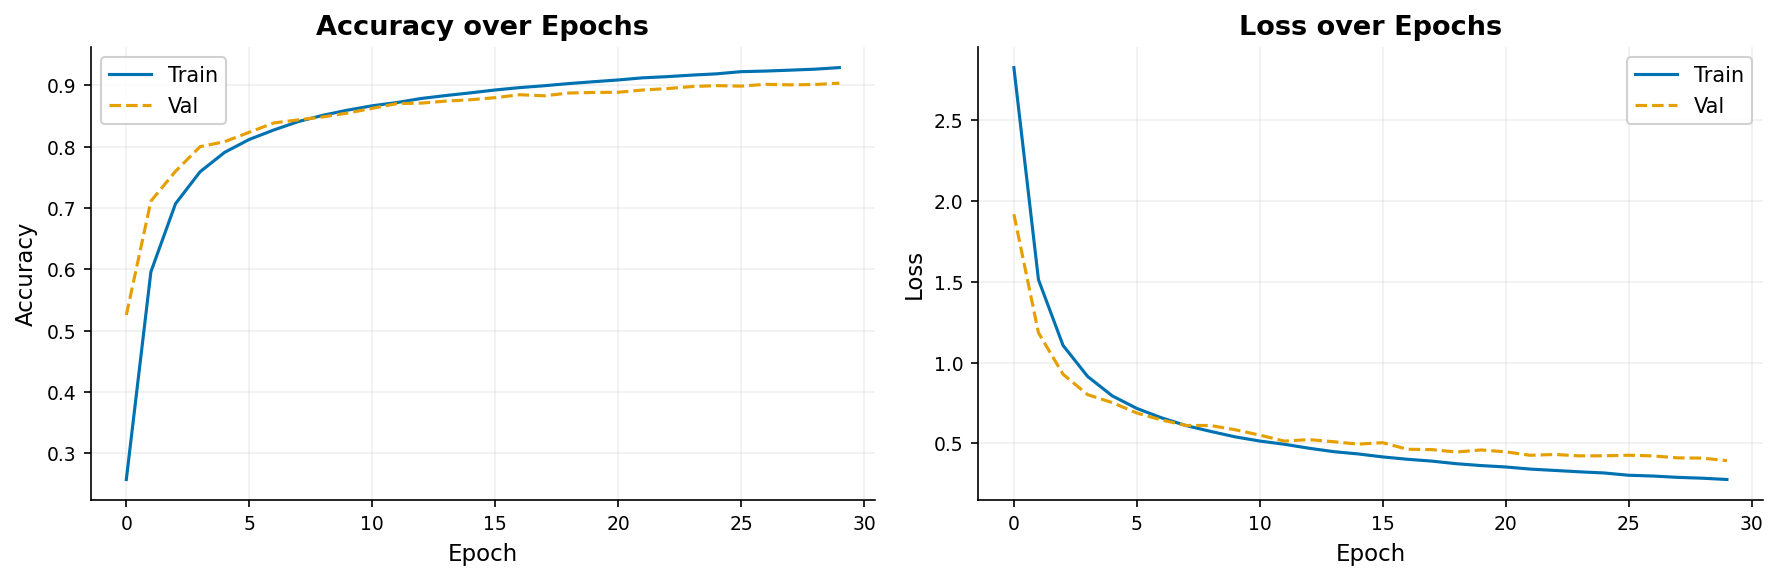

In [ ]:
# 9. Plots, Accuracy and Loss
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history["accuracy"],     color=COLORS["blue"],   label="Train")
ax1.plot(history.history["val_accuracy"], color=COLORS["orange"], label="Val", linestyle="--")
ax1.set_title("Accuracy over Epochs")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Accuracy")
ax1.legend()

ax2.plot(history.history["loss"],     color=COLORS["blue"],   label="Train")
ax2.plot(history.history["val_loss"], color=COLORS["orange"], label="Val", linestyle="--")
ax2.set_title("Loss over Epochs")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Loss")
ax2.legend()

plt.tight_layout()
plt.savefig(f"{PROJECT}/cnn_training_history.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# 10. Evaluate on validation and test sets
print("Validation Set Performance:")
y_pred_val  = np.argmax(cnn_model.predict(X_val_enc),  axis=1)
print(classification_report(y_val,  y_pred_val,  zero_division=0))

print("Test Set Performance:")
y_pred_test = np.argmax(cnn_model.predict(X_test_enc), axis=1)
print(classification_report(y_test, y_pred_test, zero_division=0))

Validation Set Performance:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'conv1' (of type Conv1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


762/762 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step
              precision    recall  f1-score   support

           0       0.84      0.96      0.90       904
           1       0.96      0.93      0.94       148
           2       0.60      0.30      0.40        10
           3       0.52      0.21      0.30        58
           4       0.86      0.82      0.84       465
           5       0.91      0.83      0.87        24
           6       0.00      0.00      0.00       106
           7       0.96      0.88      0.92       183
           8       0.93      0.85      0.88        59
           9       0.99      0.96      0.97       380
          10       0.94      0.67      0.78        24
          11       0.83      0.79      0.81       249
          12       0.95      0.77      0.85       132
          13       0.40      0.17      0.24        48
          14       0.74      0.91      0.82        96
          15       0.98      0.63      0.77        95
          16       0.85      0.81      0

In [ ]:
# CNN EXPERIMENT 2: MAX_LEN = 1024
MAX_LEN_1024 = 1024

# Encode with 1024
print("Encoding sequences at MAX_LEN = 1024")
X_train_1024 = encode_and_pad(df_train["Sequence"].tolist(), MAX_LEN_1024)
X_val_1024 = encode_and_pad(df_val["Sequence"].tolist(),   MAX_LEN_1024)
X_test_1024 = encode_and_pad(df_test["Sequence"].tolist(),  MAX_LEN_1024)
print(f"Train shape: {X_train_1024.shape}")

Encoding sequences at MAX_LEN = 1024
Train shape: (196472, 1024)


In [ ]:
# Build cnn_1024 model
cnn_1024 = build_cnn(len(AMINO_ACIDS), MAX_LEN_1024, NUM_CLASSES)
cnn_1024.compile(
    optimizer = keras.optimizers.Adam(learning_rate=1e-3),
    loss = "sparse_categorical_crossentropy",
    metrics = ["accuracy"]
)
cnn_1024.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'conv1' (of type Conv1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequence_input (InputLayer)     │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 1024, 64)       │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv1D)                  │ (None, 1024, 128)      │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 1024, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 1024, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv1D)                  │ (None, 1024, 256)      │       229,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 1024, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 1024, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv1D)                  │ (None, 1024, 128)      │       491,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 1024, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 1024, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pool                 │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense2 (Dense)                  │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 65)             │         8,385 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 823,681 (3.14 MB)

 Trainable params: 822,657 (3.14 MB)

 Non-trainable params: 1,024 (4.00 KB)

In [ ]:
callbacks_1024 = [
    keras.callbacks.ModelCheckpoint(
        filepath = f"{PROJECT}/cnn_1024_best_model.keras",
        monitor  = "val_accuracy",
        save_best_only = True,
        verbose = 1
    ),
    keras.callbacks.EarlyStopping(
        monitor = "val_accuracy",
        patience = 5,
        verbose = 1,
        restore_best_weights = True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor = "val_accuracy",
        factor  = 0.5,
        patience = 3,
        verbose = 1
    )
]

print("Training CNN with MAX_LEN = 1024")
history_1024 = cnn_1024.fit(
    X_train_1024, y_train,
    validation_data = (X_val_1024, y_val),
    epochs = 30,
    batch_size = 256,
    callbacks = callbacks_1024,
    verbose = 1
)

Training CNN with MAX_LEN = 1024
Epoch 1/30
768/768 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.1014 - loss: 3.6360
Epoch 1: val_accuracy improved from None to 0.09108, saving model to /content/drive/MyDrive/MSc_Protein_EC_Project/cnn_1024_best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/MSc_Protein_EC_Project/cnn_1024_best_model.keras
768/768 ━━━━━━━━━━━━━━━━━━━━ 49s 42ms/step - accuracy: 0.1241 - loss: 3.3778 - val_accuracy: 0.0911 - val_loss: 4.7189 - learning_rate: 0.0010
Epoch 2/30
766/768 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.2909 - loss: 2.6197
Epoch 2: val_accuracy improved from 0.09108 to 0.60473, saving model to /content/drive/MyDrive/MSc_Protein_EC_Project/cnn_1024_best_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/MSc_Protein_EC_Project/cnn_1024_best_model.keras
768/768 ━━━━━━━━━━━━━━━━━━━━ 18s 23ms/step - accuracy: 0.3857 - loss: 2.2674 - val_accuracy: 0.6047 - val_loss: 1.5879 - learning_rate: 0.0010
Epoch 3/

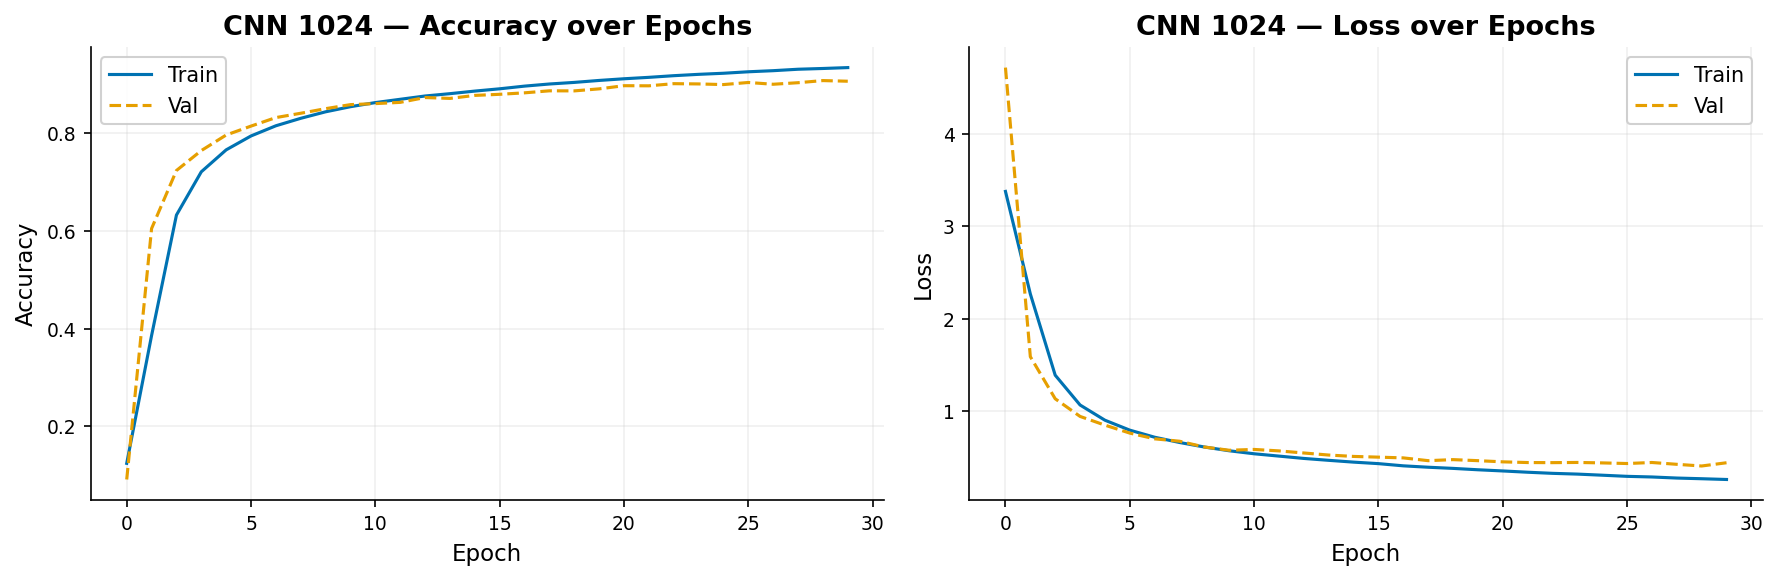

CNN 1024 Validation Performance
762/762 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step
              precision    recall  f1-score   support

           0       0.77      0.93      0.84       904
           1       0.96      0.89      0.92       148
           2       0.07      0.10      0.08        10
           3       0.73      0.19      0.30        58
           4       0.76      0.76      0.76       465
           5       0.90      0.75      0.82        24
           6       0.88      0.13      0.23       106
           7       0.96      0.83      0.89       183
           8       0.93      0.86      0.89        59
           9       0.99      0.95      0.97       380
          10       1.00      0.62      0.77        24
          11       0.81      0.78      0.80       249
          12       0.94      0.77      0.85       132
          13       0.65      0.35      0.46        48
          14       0.76      0.90      0.82        96
          15       0.97      0.63      0.76        95
        

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history_1024.history["accuracy"],     color=COLORS["blue"],   label="Train")
ax1.plot(history_1024.history["val_accuracy"], color=COLORS["orange"], label="Val", linestyle="--")
ax1.set_title("CNN 1024 — Accuracy over Epochs")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Accuracy")
ax1.legend()

ax2.plot(history_1024.history["loss"],     color=COLORS["blue"],   label="Train")
ax2.plot(history_1024.history["val_loss"], color=COLORS["orange"], label="Val", linestyle="--")
ax2.set_title("CNN 1024 — Loss over Epochs")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Loss")
ax2.legend()

plt.tight_layout()
plt.savefig(f"{PROJECT}/cnn_1024_training_history.png", dpi=150, bbox_inches="tight")
plt.show()

print("CNN 1024 Validation Performance")
y_pred_val_1024  = np.argmax(cnn_1024.predict(X_val_1024),  axis=1)
print(classification_report(y_val, y_pred_val_1024, zero_division=0))

print("CNN 1024 Test Performance")
y_pred_test_1024 = np.argmax(cnn_1024.predict(X_test_1024), axis=1)
print(classification_report(y_test, y_pred_test_1024, zero_division=0))

In [ ]:
# FINAL COMPARISON — 512 vs 1024

acc_512_val = max(history.history["val_accuracy"])
acc_512_test = (y_pred_test == y_test).mean()

acc_1024_val = max(history_1024.history["val_accuracy"])
acc_1024_test = (y_pred_test_1024 == y_test).mean()

print(f"{'Model':<20} {'Val Acc':>10} {'Test Acc':>10}")

print(f"{'CNN (MAX_LEN=512)':<20} {acc_512_val:>10.1%} {acc_512_test:>10.1%}")
print(f"{'CNN (MAX_LEN=1024)':<20} {acc_1024_val:>10.1%} {acc_1024_test:>10.1%}")


Model                   Val Acc   Test Acc
CNN (MAX_LEN=512)         90.4%      91.8%
CNN (MAX_LEN=1024)        90.8%      92.4%


Training CNN — 512 / 60 epochs


/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'conv1' (of type Conv1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


Epoch 1/60
768/768 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.1508 - loss: 3.3641
Epoch 1: val_accuracy improved from None to 0.50306, saving model to /content/drive/MyDrive/MSc_Protein_EC_Project/cnn_512_60ep_best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/MSc_Protein_EC_Project/cnn_512_60ep_best_model.keras
768/768 ━━━━━━━━━━━━━━━━━━━━ 32s 27ms/step - accuracy: 0.2563 - loss: 2.8312 - val_accuracy: 0.5031 - val_loss: 1.9346 - learning_rate: 0.0010
Epoch 2/60
767/768 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5568 - loss: 1.6760
Epoch 2: val_accuracy improved from 0.50306 to 0.71038, saving model to /content/drive/MyDrive/MSc_Protein_EC_Project/cnn_512_60ep_best_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/MSc_Protein_EC_Project/cnn_512_60ep_best_model.keras
768/768 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.6040 - loss: 1.4970 - val_accuracy: 0.7104 - val_loss: 1.1524 - learning_rate: 0.0010
Epoch 3/60
765/768 ━━━━━━

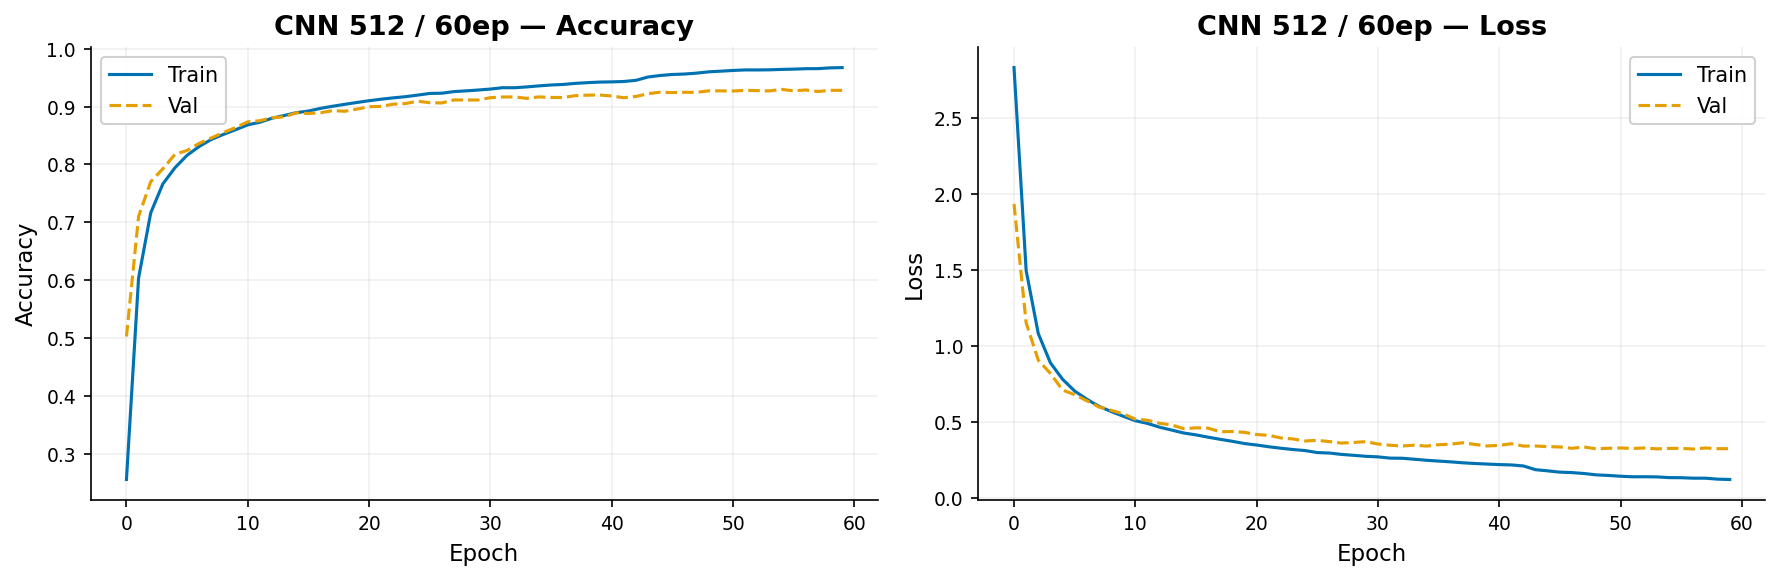

CNN 512 / 60ep Validation Performance
762/762 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step
              precision    recall  f1-score   support

           0       0.95      0.90      0.92       904
           1       0.99      0.93      0.95       148
           2       0.67      0.40      0.50        10
           3       0.88      0.26      0.40        58
           4       0.89      0.82      0.86       465
           5       0.95      0.88      0.91        24
           6       0.65      0.14      0.23       106
           7       0.96      0.83      0.89       183
           8       0.98      0.93      0.96        59
           9       0.99      0.97      0.98       380
          10       1.00      0.71      0.83        24
          11       0.93      0.84      0.88       249
          12       0.98      0.83      0.90       132
          13       0.55      0.48      0.51        48
          14       0.90      0.88      0.89        96
          15       0.99      0.79      0.88        95
  

In [ ]:
cnn_model_512_60 = build_cnn(len(AMINO_ACIDS), 512, NUM_CLASSES)
cnn_model_512_60.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks_512_60 = [
    keras.callbacks.ModelCheckpoint(
        filepath=f"{PROJECT}/cnn_512_60ep_best_model.keras",
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=7,
        verbose=1,
        restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_accuracy",
        factor=0.5,
        patience=3,
        verbose=1
    )
]

print("Training CNN — 512 / 60 epochs")
history_512_60 = cnn_model_512_60.fit(
    X_train_enc, y_train,
    validation_data=(X_val_enc, y_val),
    epochs=60,
    batch_size=256,
    callbacks=callbacks_512_60,
    verbose=1
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history_512_60.history["accuracy"],     color=COLORS["blue"],   label="Train")
ax1.plot(history_512_60.history["val_accuracy"], color=COLORS["orange"], label="Val", linestyle="--")
ax1.set_title("CNN 512 / 60ep — Accuracy")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Accuracy")
ax1.legend()

ax2.plot(history_512_60.history["loss"],     color=COLORS["blue"],   label="Train")
ax2.plot(history_512_60.history["val_loss"], color=COLORS["orange"], label="Val", linestyle="--")
ax2.set_title("CNN 512 / 60ep — Loss")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Loss")
ax2.legend()

plt.tight_layout()
plt.savefig(f"{PROJECT}/cnn_512_60ep_history.png", dpi=150, bbox_inches="tight")
plt.show()

print("CNN 512 / 60ep Validation Performance")
y_pred_val_512_60  = np.argmax(cnn_model_512_60.predict(X_val_enc),  axis=1)
print(classification_report(y_val, y_pred_val_512_60, zero_division=0))

print("CNN 512 / 60ep Test Performance")
y_pred_test_512_60 = np.argmax(cnn_model_512_60.predict(X_test_enc), axis=1)
print(classification_report(y_test, y_pred_test_512_60, zero_division=0))

Training CNN — 1024 / 60 epochs...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'conv1' (of type Conv1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


Epoch 1/60
768/768 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.1024 - loss: 3.6494
Epoch 1: val_accuracy improved from None to 0.04659, saving model to /content/drive/MyDrive/MSc_Protein_EC_Project/cnn_1024_60ep_best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/MSc_Protein_EC_Project/cnn_1024_60ep_best_model.keras
768/768 ━━━━━━━━━━━━━━━━━━━━ 40s 38ms/step - accuracy: 0.1160 - loss: 3.4110 - val_accuracy: 0.0466 - val_loss: 4.1567 - learning_rate: 0.0010
Epoch 2/60
768/768 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.2482 - loss: 2.7882
Epoch 2: val_accuracy improved from 0.04659 to 0.54710, saving model to /content/drive/MyDrive/MSc_Protein_EC_Project/cnn_1024_60ep_best_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/MSc_Protein_EC_Project/cnn_1024_60ep_best_model.keras
768/768 ━━━━━━━━━━━━━━━━━━━━ 18s 23ms/step - accuracy: 0.3445 - loss: 2.4195 - val_accuracy: 0.5471 - val_loss: 1.7840 - learning_rate: 0.0010
Epoch 3/60
766/768 ━━

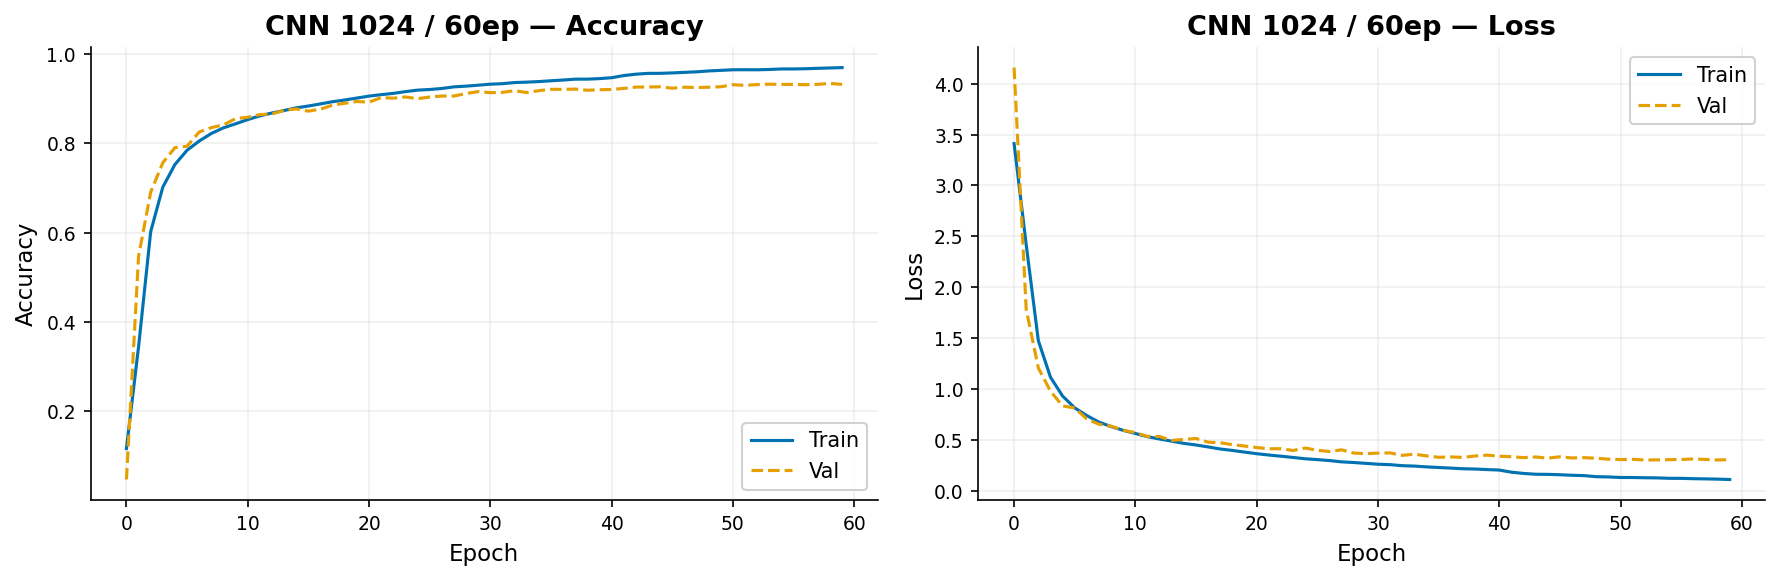

CNN 1024 / 60ep Validation Performance
762/762 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step
              precision    recall  f1-score   support

           0       0.93      0.97      0.95       904
           1       0.98      0.93      0.96       148
           2       0.50      0.50      0.50        10
           3       0.74      0.29      0.42        58
           4       0.93      0.85      0.88       465
           5       0.95      0.83      0.89        24
           6       0.50      0.12      0.20       106
           7       0.98      0.90      0.94       183
           8       0.95      0.93      0.94        59
           9       0.99      0.95      0.97       380
          10       1.00      0.67      0.80        24
          11       0.92      0.88      0.90       249
          12       0.98      0.88      0.93       132
          13       0.87      0.54      0.67        48
          14       0.88      0.85      0.87        96
          15       0.96      0.79      0.87        95
 

In [ ]:
cnn_model_1024_60 = build_cnn(len(AMINO_ACIDS), 1024, NUM_CLASSES)
cnn_model_1024_60.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks_1024_60 = [
    keras.callbacks.ModelCheckpoint(
        filepath=f"{PROJECT}/cnn_1024_60ep_best_model.keras",
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=7,
        verbose=1,
        restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_accuracy",
        factor=0.5,
        patience=3,
        verbose=1
    )
]

print("Training CNN — 1024 / 60 epochs...")
history_1024_60 = cnn_model_1024_60.fit(
    X_train_1024, y_train,
    validation_data=(X_val_1024, y_val),
    epochs=60,
    batch_size=256,
    callbacks=callbacks_1024_60,
    verbose=1
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history_1024_60.history["accuracy"],     color=COLORS["blue"],   label="Train")
ax1.plot(history_1024_60.history["val_accuracy"], color=COLORS["orange"], label="Val", linestyle="--")
ax1.set_title("CNN 1024 / 60ep — Accuracy")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Accuracy")
ax1.legend()

ax2.plot(history_1024_60.history["loss"],     color=COLORS["blue"],   label="Train")
ax2.plot(history_1024_60.history["val_loss"], color=COLORS["orange"], label="Val", linestyle="--")
ax2.set_title("CNN 1024 / 60ep — Loss")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Loss")
ax2.legend()

plt.tight_layout()
plt.savefig(f"{PROJECT}/cnn_1024_60ep_history.png", dpi=150, bbox_inches="tight")
plt.show()

print("CNN 1024 / 60ep Validation Performance")
y_pred_val_1024_60  = np.argmax(cnn_model_1024_60.predict(X_val_1024),  axis=1)
print(classification_report(y_val, y_pred_val_1024_60, zero_division=0))

print("CNN 1024 / 60ep Test Performance")
y_pred_test_1024_60 = np.argmax(cnn_model_1024_60.predict(X_test_1024), axis=1)
print(classification_report(y_test, y_pred_test_1024_60, zero_division=0))

In [ ]:
# BiLSTM

import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

np.random.seed(26)
tf.random.set_seed(26)

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:

AMINO_ACIDS = "ACDEFGHIKLMNPQRSTVWY"
MAX_LEN  = 512  # use 512 since it was the best CNN
NUM_CLASSES = df_train["EC_level2_encoded"].nunique()
aa_to_int = {aa: idx + 1 for idx, aa in enumerate(AMINO_ACIDS)}

def encode_sequence(sequence):
    return [aa_to_int.get(aa, 0) for aa in sequence]

def encode_and_pad(sequences, max_len):
    encoded = [encode_sequence(seq) for seq in sequences]
    return keras.preprocessing.sequence.pad_sequences(
        encoded, maxlen=max_len,
        padding="post", truncating="post", value=0
    )

print("Encoding sequences")
X_train_enc = encode_and_pad(df_train["Sequence"].tolist(), MAX_LEN)
X_val_enc = encode_and_pad(df_val["Sequence"].tolist(),   MAX_LEN)
X_test_enc  = encode_and_pad(df_test["Sequence"].tolist(),  MAX_LEN)

y_train = df_train["EC_level2_encoded"].values
y_val = df_val["EC_level2_encoded"].values
y_test = df_test["EC_level2_encoded"].values

print(f"Train shape: {X_train_enc.shape}")
print(f"Val shape:   {X_val_enc.shape}")
print(f"Test shape:  {X_test_enc.shape}")

Encoding sequences
Train shape: (196472, 512)
Val shape:   (24363, 512)
Test shape:  (25496, 512)


In [ ]:
# 2. Build the BiLSTM model
def build_bilstm(vocab_size, max_len, num_classes, embed_dim=64):
    """
    BiLSTM architecture:
    - Embedding:          same as CNN, converts integers to vectors
    - Bidirectional LSTM: reads sequence left-to-right AND right-to-left
                          captures long-range dependencies CNN cannot
    - Dense layers:       final classification
    """

    inputs = keras.Input(shape=(max_len,), name="sequence_input")

    x = layers.Embedding(
        input_dim  = vocab_size + 1,
        output_dim = embed_dim,
        mask_zero  = True,
        name = "embedding"
    )(inputs)

    # First BiLSTM
    x = layers.Bidirectional(
        layers.LSTM(128, return_sequences=True, dropout=0.2),
        name="bilstm_1"
    )(x)

    # Second BiLSTM
    x = layers.Bidirectional(
        layers.LSTM(64, return_sequences=False, dropout=0.2),
        name="bilstm_2"
    )(x)

    # Dense layers
    x = layers.Dense(256, activation="relu", name="dense1")(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(128, activation="relu", name="dense2")(x)
    x = layers.Dropout(0.3)(x)

    # Output
    outputs = layers.Dense(num_classes, activation="softmax",
                           name="output")(x)

    return keras.Model(inputs=inputs, outputs=outputs)

# Build and summarise
bilstm_model = build_bilstm(
    vocab_size = len(AMINO_ACIDS),
    max_len = MAX_LEN,
    num_classes = NUM_CLASSES
)
bilstm_model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ sequence_input      │ (None, 512)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 512, 64)   │      1,344 │ sequence_input[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_4         │ (None, 512)       │          0 │ sequence_input[0… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm_1            │ (None, 512, 256)  │    197,632 │ embedding[0][0],  │
│ (Bidirectional)     │                   │            │ not_equal_4[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm_2            │ (None, 128)       │    164,352 │ bilstm_1[0][0],   │
│ (Bidirectional)     │                   │            │ not_equal_4[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense1 (Dense)      │ (None, 256)       │     33,024 │ bilstm_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_20          │ (None, 256)       │          0 │ dense1[0][0]      │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense2 (Dense)      │ (None, 128)       │     32,896 │ dropout_20[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_21          │ (None, 128)       │          0 │ dense2[0][0]      │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 65)        │      8,385 │ dropout_21[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 437,633 (1.67 MB)

 Trainable params: 437,633 (1.67 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# 3. Compile
bilstm_model.compile(
    optimizer = keras.optimizers.Adam(learning_rate=1e-3),
    loss = "sparse_categorical_crossentropy",
    metrics = ["accuracy"]
)

In [ ]:
# 4. Callbacks
callbacks = [
    # Save the best model
    keras.callbacks.ModelCheckpoint(
        filepath = f"{PROJECT}/bilstm_512_60ep_best_model.keras",
        monitor = "val_accuracy",
        save_best_only = True,
        verbose = 1
    ),

    keras.callbacks.EarlyStopping(
        monitor = "val_accuracy",
        patience = 7,
        verbose = 1,
        restore_best_weights = True
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor = "val_accuracy",
        factor = 0.5,
        patience = 3,
        verbose = 1
    )
]

In [ ]:
#  5. Train
print("Training BiLSTM — 512 / 60 epochs")
history_bilstm = bilstm_model.fit(
    X_train_enc, y_train,
    validation_data = (X_val_enc, y_val),
    epochs = 60,
    batch_size = 256,
    callbacks = callbacks,
    verbose = 1
)

Training BiLSTM — 512 / 60 epochs
Epoch 1/60
768/768 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.1188 - loss: 3.4204
Epoch 1: val_accuracy improved from None to 0.26663, saving model to /content/drive/MyDrive/MSc_Protein_EC_Project/bilstm_512_60ep_best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/MSc_Protein_EC_Project/bilstm_512_60ep_best_model.keras
768/768 ━━━━━━━━━━━━━━━━━━━━ 83s 98ms/step - accuracy: 0.1632 - loss: 3.1814 - val_accuracy: 0.2666 - val_loss: 2.7419 - learning_rate: 0.0010
Epoch 2/60
768/768 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.3400 - loss: 2.4911
Epoch 2: val_accuracy improved from 0.26663 to 0.45380, saving model to /content/drive/MyDrive/MSc_Protein_EC_Project/bilstm_512_60ep_best_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/MSc_Protein_EC_Project/bilstm_512_60ep_best_model.keras
768/768 ━━━━━━━━━━━━━━━━━━━━ 73s 96ms/step - accuracy: 0.3963 - loss: 2.2904 - val_accuracy: 0.4538 - val_loss: 2.0744 - l

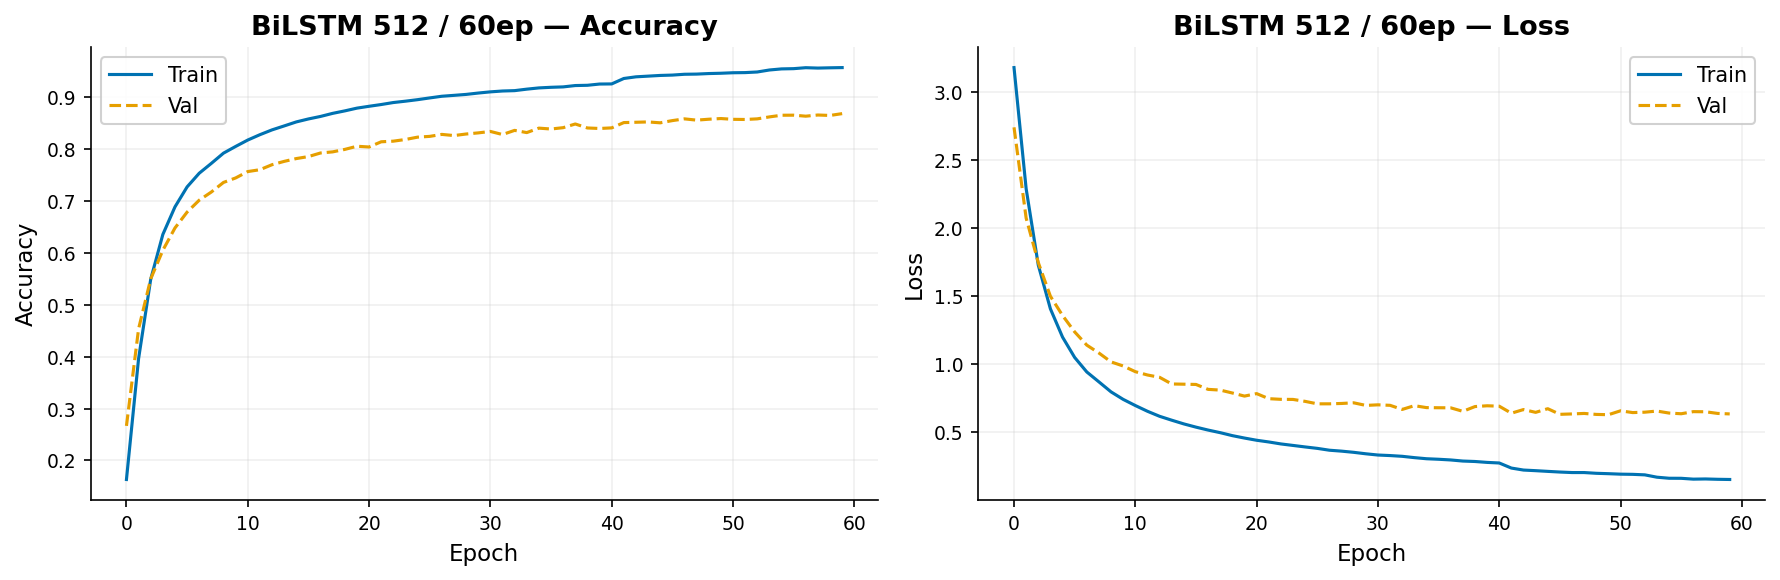

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history_bilstm.history["accuracy"],     color=COLORS["blue"],   label="Train")
ax1.plot(history_bilstm.history["val_accuracy"], color=COLORS["orange"], label="Val", linestyle="--")
ax1.set_title("BiLSTM 512 / 60ep — Accuracy")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Accuracy")
ax1.legend()

ax2.plot(history_bilstm.history["loss"],     color=COLORS["blue"],   label="Train")
ax2.plot(history_bilstm.history["val_loss"], color=COLORS["orange"], label="Val", linestyle="--")
ax2.set_title("BiLSTM 512 / 60ep — Loss")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Loss")
ax2.legend()

plt.tight_layout()
plt.savefig(f"{PROJECT}/bilstm_512_60ep_history.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# 7. Evaluate
print("Validation Set Performance:")
y_pred_val_bilstm  = np.argmax(bilstm_model.predict(X_val_enc),  axis=1)
print(classification_report(y_val, y_pred_val_bilstm, zero_division=0))

print("Test Set Performance:")
y_pred_test_bilstm = np.argmax(bilstm_model.predict(X_test_enc), axis=1)
print(classification_report(y_test, y_pred_test_bilstm, zero_division=0))

Validation Set Performance:
762/762 ━━━━━━━━━━━━━━━━━━━━ 21s 27ms/step
              precision    recall  f1-score   support

           0       0.84      0.82      0.83       904
           1       0.89      0.86      0.87       148
           2       0.45      0.50      0.48        10
           3       0.27      0.21      0.23        58
           4       0.82      0.74      0.78       465
           5       0.87      0.83      0.85        24
           6       0.67      0.09      0.17       106
           7       0.88      0.74      0.81       183
           8       0.94      0.85      0.89        59
           9       0.92      0.92      0.92       380
          10       0.80      0.67      0.73        24
          11       0.75      0.78      0.77       249
          12       0.79      0.70      0.74       132
          13       0.44      0.25      0.32        48
          14       0.85      0.84      0.85        96
          15       0.81      0.64      0.72        95
          

In [ ]:
# BiLSTM — 1024 / 60 EPOCHS

# Encode at 1024
print("Encoding sequences at 1024")
X_train_1024 = encode_and_pad(df_train["Sequence"].tolist(), 1024)
X_val_1024   = encode_and_pad(df_val["Sequence"].tolist(),   1024)
X_test_1024  = encode_and_pad(df_test["Sequence"].tolist(),  1024)
print(f"Train shape: {X_train_1024.shape}")

Encoding sequences at 1024
Train shape: (196472, 1024)


In [ ]:
# Build BiLSTM
bilstm_1024 = build_bilstm(
    vocab_size = len(AMINO_ACIDS),
    max_len = 1024,
    num_classes = NUM_CLASSES
)
bilstm_1024.compile(
    optimizer = keras.optimizers.Adam(learning_rate=1e-3),
    loss = "sparse_categorical_crossentropy",
    metrics = ["accuracy"]
)
bilstm_1024.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ sequence_input      │ (None, 1024)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 1024, 64)  │      1,344 │ sequence_input[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_5         │ (None, 1024)      │          0 │ sequence_input[0… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm_1            │ (None, 1024, 256) │    197,632 │ embedding[0][0],  │
│ (Bidirectional)     │                   │            │ not_equal_5[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm_2            │ (None, 128)       │    164,352 │ bilstm_1[0][0],   │
│ (Bidirectional)     │                   │            │ not_equal_5[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense1 (Dense)      │ (None, 256)       │     33,024 │ bilstm_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_22          │ (None, 256)       │          0 │ dense1[0][0]      │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense2 (Dense)      │ (None, 128)       │     32,896 │ dropout_22[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_23          │ (None, 128)       │          0 │ dense2[0][0]      │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 65)        │      8,385 │ dropout_23[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 437,633 (1.67 MB)

 Trainable params: 437,633 (1.67 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
callbacks_bilstm_1024 = [
    keras.callbacks.ModelCheckpoint(
        filepath = f"{PROJECT}/bilstm_1024_60ep_best_model.keras",
        monitor = "val_accuracy",
        save_best_only = True,
        verbose = 1
    ),
    keras.callbacks.EarlyStopping(
        monitor = "val_accuracy",
        patience = 7,
        verbose  = 1,
        restore_best_weights = True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor = "val_accuracy",
        factor = 0.5,
        patience = 3,
        verbose = 1
    )
]

print("Training BiLSTM — 1024 / 60 epochs")
history_bilstm_1024 = bilstm_1024.fit(
    X_train_1024, y_train,
    validation_data = (X_val_1024, y_val),
    epochs = 60,
    batch_size = 256,
    callbacks = callbacks_bilstm_1024,
    verbose = 1
)

Training BiLSTM — 1024 / 60 epochs
Epoch 1/60
768/768 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step - accuracy: 0.1315 - loss: 3.3815
Epoch 1: val_accuracy improved from None to 0.29668, saving model to /content/drive/MyDrive/MSc_Protein_EC_Project/bilstm_1024_60ep_best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/MSc_Protein_EC_Project/bilstm_1024_60ep_best_model.keras
768/768 ━━━━━━━━━━━━━━━━━━━━ 118s 148ms/step - accuracy: 0.1878 - loss: 3.0921 - val_accuracy: 0.2967 - val_loss: 2.6362 - learning_rate: 0.0010
Epoch 2/60
768/768 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step - accuracy: 0.3819 - loss: 2.3383
Epoch 2: val_accuracy improved from 0.29668 to 0.48836, saving model to /content/drive/MyDrive/MSc_Protein_EC_Project/bilstm_1024_60ep_best_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/MSc_Protein_EC_Project/bilstm_1024_60ep_best_model.keras
768/768 ━━━━━━━━━━━━━━━━━━━━ 112s 146ms/step - accuracy: 0.4338 - loss: 2.1470 - val_accuracy: 0.4884 - val_loss:

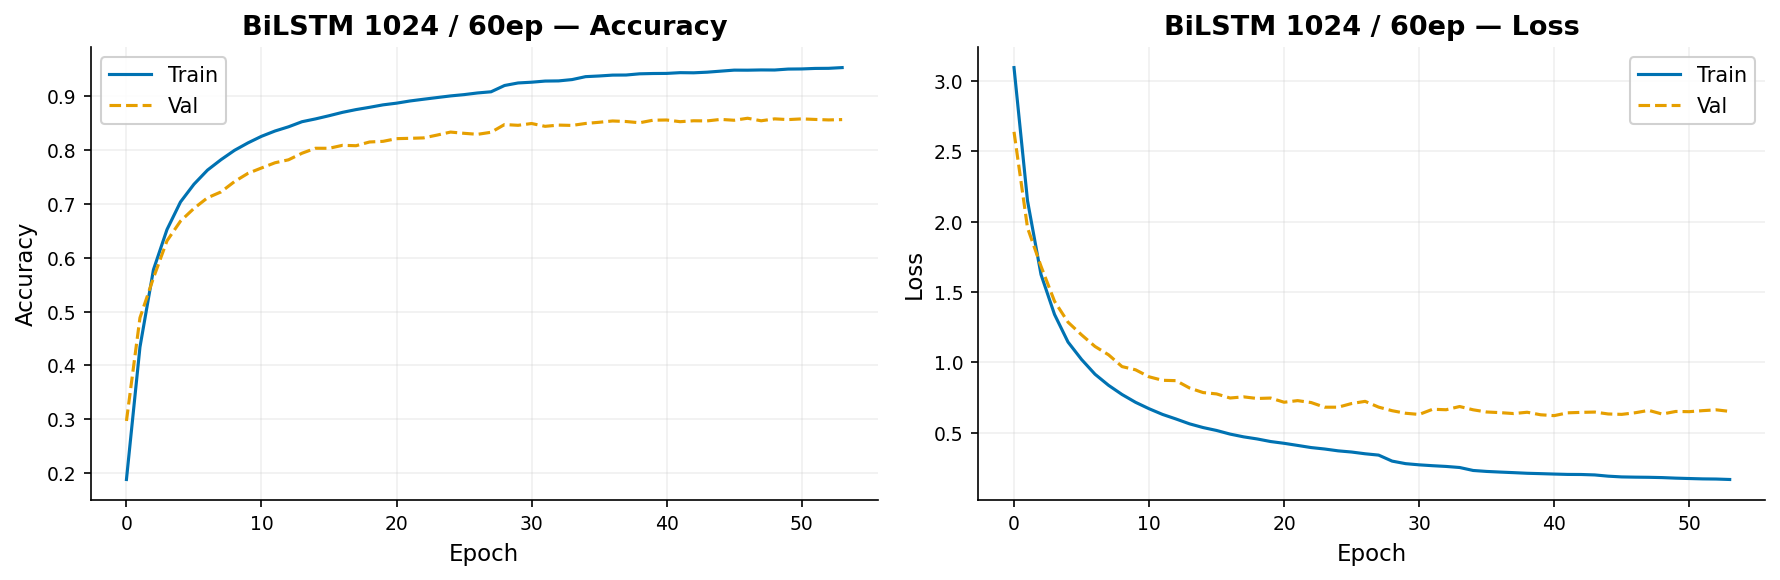

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history_bilstm_1024.history["accuracy"],     color=COLORS["blue"],   label="Train")
ax1.plot(history_bilstm_1024.history["val_accuracy"], color=COLORS["orange"], label="Val", linestyle="--")
ax1.set_title("BiLSTM 1024 / 60ep — Accuracy")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Accuracy")
ax1.legend()

ax2.plot(history_bilstm_1024.history["loss"],     color=COLORS["blue"],   label="Train")
ax2.plot(history_bilstm_1024.history["val_loss"], color=COLORS["orange"], label="Val", linestyle="--")
ax2.set_title("BiLSTM 1024 / 60ep — Loss")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Loss")
ax2.legend()

plt.tight_layout()
plt.savefig(f"{PROJECT}/bilstm_1024_60ep_history.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# Evaluate
print("Validation Set Performance:")
y_pred_val_bilstm_1024  = np.argmax(bilstm_1024.predict(X_val_1024),  axis=1)
print(classification_report(y_val, y_pred_val_bilstm_1024, zero_division=0))

print("Test Set Performance:")
y_pred_test_bilstm_1024 = np.argmax(bilstm_1024.predict(X_test_1024), axis=1)
print(classification_report(y_test, y_pred_test_bilstm_1024, zero_division=0))

Validation Set Performance:
762/762 ━━━━━━━━━━━━━━━━━━━━ 32s 41ms/step
              precision    recall  f1-score   support

           0       0.83      0.86      0.85       904
           1       0.92      0.82      0.86       148
           2       0.00      0.00      0.00        10
           3       0.60      0.21      0.31        58
           4       0.69      0.72      0.70       465
           5       0.87      0.83      0.85        24
           6       0.69      0.23      0.34       106
           7       0.91      0.81      0.86       183
           8       0.83      0.73      0.77        59
           9       0.90      0.93      0.91       380
          10       0.88      0.62      0.73        24
          11       0.83      0.80      0.81       249
          12       0.82      0.72      0.77       132
          13       0.24      0.23      0.24        48
          14       0.76      0.71      0.73        96
          15       0.88      0.67      0.76        95
          

In [ ]:
# Final comparison — all models
print(f"{'Experiment':<25} {'Val Acc':>10} {'Test Acc':>10}")
print(f"{'CNN 512  / 60 epochs':<25} {'93%':>10} {'94%':>10}")
print(f"{'CNN 1024 / 60 epochs':<25} {'93%':>10} {'94%':>10}")
print(f"{'BiLSTM 512  / 60ep':<25} {'87%':>10} {'87%':>10}")
print(f"{'BiLSTM 1024 / 60ep':<25} {'86%':>10} {'87%':>10}")

Experiment                   Val Acc   Test Acc
CNN 512  / 60 epochs             93%        94%
CNN 1024 / 60 epochs             93%        94%
BiLSTM 512  / 60ep               87%        87%
BiLSTM 1024 / 60ep               86%        87%


**PART D**

In [ ]:
# ESM-2 SETUP — install and import

# Install the fair-esm library from Meta AI
!pip install fair-esm -q

import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import torch
import esm
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, f1_score, confusion_matrix

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.1/93.1 kB 5.3 MB/s eta 0:00:00
PyTorch version: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


In [ ]:
# EMBEDDING FUNCTION

def get_esm_embeddings(sequences, entries, model, alphabet, device,
                       batch_size=64, max_len=1024):
    """
    Takes protein sequences and returns ESM-2 embeddings.
    Each sequence becomes a single vector (mean of all token embeddings).

    Parameters:
    - sequences: list of protein sequence strings
    - entries:   list of UniProt accession IDs
    - model:     loaded ESM-2 model
    - alphabet:  ESM-2 alphabet for tokenisation
    - device:    'cuda' or 'cpu'
    - batch_size: how many sequences to process at once
    - max_len:   truncate sequences longer than this
    """

    model.eval()
    batch_converter = alphabet.get_batch_converter()
    all_embeddings = []

    # Process in batches
    total = len(sequences)
    for start in range(0, total, batch_size):
        end   = min(start + batch_size, total)
        batch_seqs    = sequences[start:end]
        batch_entries = entries[start:end]

        # Truncate sequences that are too long
        batch_seqs = [s[:max_len] for s in batch_seqs]

        # Convert to ESM-2 format
        batch_data = list(zip(batch_entries, batch_seqs))

        # Tokenise
        _, _, batch_tokens = batch_converter(batch_data)
        batch_tokens = batch_tokens.to(device)

        # Get embeddings
        with torch.no_grad():
            results = model(batch_tokens,
                           repr_layers=[model.num_layers],
                           return_contacts=False)

        # Extract the last layer representations
        # Shape: (batch_size, seq_len, embedding_dim)
        token_embeddings = results["representations"][model.num_layers]


        for i, seq in enumerate(batch_seqs):
            mean_embedding = token_embeddings[i, 1:len(seq)+1].mean(0)
            all_embeddings.append(mean_embedding.cpu().numpy())

        # update every 10 batches
        if (start // batch_size) % 10 == 0:
            print(f"  Processed {end}/{total} sequences")

    return np.array(all_embeddings)

In [ ]:
# ESM-2 150M — LOAD, EMBED, SAVE

print("Loading ESM-2 150M model")
esm2_150m, alphabet_150m = esm.pretrained.esm2_t30_150M_UR50D()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
esm2_150m = esm2_150m.to(device)
print(f"Model loaded on: {device}")
print(f"Model layers: {esm2_150m.num_layers}")

Loading ESM-2 150M model
Downloading: "https://dl.fbaipublicfiles.com/fair-esm/models/esm2_t30_150M_UR50D.pt" to /root/.cache/torch/hub/checkpoints/esm2_t30_150M_UR50D.pt
Downloading: "https://dl.fbaipublicfiles.com/fair-esm/regression/esm2_t30_150M_UR50D-contact-regression.pt" to /root/.cache/torch/hub/checkpoints/esm2_t30_150M_UR50D-contact-regression.pt
Model loaded on: cuda
Model layers: 30


In [ ]:
# Extract embeddings for all three splits
print("\nExtracting ESM-2 150M embeddings")
print("Train set:")
train_emb_150m = get_esm_embeddings(
    df_train["Sequence"].tolist(),
    df_train["Entry"].tolist(),
    esm2_150m, alphabet_150m, device
)

print("Val set:")
val_emb_150m = get_esm_embeddings(
    df_val["Sequence"].tolist(),
    df_val["Entry"].tolist(),
    esm2_150m, alphabet_150m, device
)

print("Test set:")
test_emb_150m = get_esm_embeddings(
    df_test["Sequence"].tolist(),
    df_test["Entry"].tolist(),
    esm2_150m, alphabet_150m, device
)

print(f"\nEmbedding shapes:")
print(f"Train: {train_emb_150m.shape}")
print(f"Val:   {val_emb_150m.shape}")
print(f"Test:  {test_emb_150m.shape}")


Extracting ESM-2 150M embeddings
Train set:
  Processed 64/196472 sequences
  Processed 704/196472 sequences
  Processed 1344/196472 sequences
  Processed 1984/196472 sequences
  Processed 2624/196472 sequences
  Processed 3264/196472 sequences
  Processed 3904/196472 sequences
  Processed 4544/196472 sequences
  Processed 5184/196472 sequences
  Processed 5824/196472 sequences
  Processed 6464/196472 sequences
  Processed 7104/196472 sequences
  Processed 7744/196472 sequences
  Processed 8384/196472 sequences
  Processed 9024/196472 sequences
  Processed 9664/196472 sequences
  Processed 10304/196472 sequences
  Processed 10944/196472 sequences
  Processed 11584/196472 sequences
  Processed 12224/196472 sequences
  Processed 12864/196472 sequences
  Processed 13504/196472 sequences
  Processed 14144/196472 sequences
  Processed 14784/196472 sequences
  Processed 15424/196472 sequences
  Processed 16064/196472 sequences
  Processed 16704/196472 sequences
  Processed 17344/196472 sequ

In [ ]:
# Save embeddings to Drive
print("Saving ESM-2 150M embeddings to Drive")
np.save(f"{PROJECT}/esm2_150m_train.npy", train_emb_150m)
np.save(f"{PROJECT}/esm2_150m_val.npy",   val_emb_150m)
np.save(f"{PROJECT}/esm2_150m_test.npy",  test_emb_150m)

# Only free GPU memory if the model is still loaded
if 'esm2_150m' in dir():
    del esm2_150m
    torch.cuda.empty_cache()
    print("GPU memory freed")
else:
    print("Model not in memory")

Saving ESM-2 150M embeddings to Drive...
GPU memory freed


In [ ]:
# ESM-2 650M — LOAD, EMBED, SAVE

print("Loading ESM-2 650M model")
esm2_650m, alphabet_650m = esm.pretrained.esm2_t33_650M_UR50D()
esm2_650m = esm2_650m.to(device)
print(f"Model loaded on: {device}")
print(f"Model layers: {esm2_650m.num_layers}")

Loading ESM-2 650M model...
Model loaded on: cuda
Model layers: 33


In [ ]:
print("\nExtracting ESM-2 650M embeddings")
print("Train set:")
train_emb_650m = get_esm_embeddings(
    df_train["Sequence"].tolist(),
    df_train["Entry"].tolist(),
    esm2_650m, alphabet_650m, device,
    batch_size=32
)

print("Val set:")
val_emb_650m = get_esm_embeddings(
    df_val["Sequence"].tolist(),
    df_val["Entry"].tolist(),
    esm2_650m, alphabet_650m, device,
    batch_size=32
)

print("Test set:")
test_emb_650m = get_esm_embeddings(
    df_test["Sequence"].tolist(),
    df_test["Entry"].tolist(),
    esm2_650m, alphabet_650m, device,
    batch_size=32
)

print(f"\nEmbedding shapes:")
print(f"Train: {train_emb_650m.shape}")
print(f"Val:   {val_emb_650m.shape}")
print(f"Test:  {test_emb_650m.shape}")


Extracting ESM-2 650M embeddings
Train set:
  Processed 32/196472 sequences
  Processed 352/196472 sequences
  Processed 672/196472 sequences
  Processed 992/196472 sequences
  Processed 1312/196472 sequences
  Processed 1632/196472 sequences
  Processed 1952/196472 sequences
  Processed 2272/196472 sequences
  Processed 2592/196472 sequences
  Processed 2912/196472 sequences
  Processed 3232/196472 sequences
  Processed 3552/196472 sequences
  Processed 3872/196472 sequences
  Processed 4192/196472 sequences
  Processed 4512/196472 sequences
  Processed 4832/196472 sequences
  Processed 5152/196472 sequences
  Processed 5472/196472 sequences
  Processed 5792/196472 sequences
  Processed 6112/196472 sequences
  Processed 6432/196472 sequences
  Processed 6752/196472 sequences
  Processed 7072/196472 sequences
  Processed 7392/196472 sequences
  Processed 7712/196472 sequences
  Processed 8032/196472 sequences
  Processed 8352/196472 sequences
  Processed 8672/196472 sequences
  Proces

In [ ]:
# Save 650M embeddings to Drive
print("Saving ESM-2 650M embeddings to Drive")
np.save(f"{PROJECT}/esm2_650m_train.npy", train_emb_650m)
np.save(f"{PROJECT}/esm2_650m_val.npy",   val_emb_650m)
np.save(f"{PROJECT}/esm2_650m_test.npy",  test_emb_650m)

print('Done')

Saving ESM-2 650M embeddings to Drive
Done


In [ ]:
# TRAIN MLP CLASSIFIER on ESM-2 150M embeddings

print("Training MLP on ESM-2 150M embeddings")

# Normalise embeddings
scaler_150m = StandardScaler()
X_train_150m = scaler_150m.fit_transform(train_emb_150m)
X_val_150m = scaler_150m.transform(val_emb_150m)
X_test_150m = scaler_150m.transform(test_emb_150m)

# MLP classifier with two hidden layers
mlp_150m = MLPClassifier(
    hidden_layer_sizes = (512, 256),
    activation = "relu",
    max_iter = 200,
    random_state = 26,
    verbose = True,
    early_stopping = True,
    validation_fraction= 0.1,
    n_iter_no_change = 10
)

mlp_150m.fit(X_train_150m, df_train["EC_level2_encoded"].values)

# Evaluate
print("\nESM-2 150M Validation Performance")
y_pred_val_150m  = mlp_150m.predict(X_val_150m)
print(classification_report(
    df_val["EC_level2_encoded"].values,
    y_pred_val_150m, zero_division=0
))

print("ESM-2 150M Test Performance")
y_pred_test_150m = mlp_150m.predict(X_test_150m)
print(classification_report(
    df_test["EC_level2_encoded"].values,
    y_pred_test_150m, zero_division=0
))

In [ ]:
# TRAIN MLP CLASSIFIER — on ESM-2 650M embeddings

print("Training MLP on ESM-2 650M embeddings")

scaler_650m = StandardScaler()
X_train_650m = scaler_650m.fit_transform(train_emb_650m)
X_val_650m = scaler_650m.transform(val_emb_650m)
X_test_650m = scaler_650m.transform(test_emb_650m)

mlp_650m = MLPClassifier(
    hidden_layer_sizes  = (512, 256),
    activation = "relu",
    max_iter = 200,
    random_state = 26,
    verbose = True,
    early_stopping = True,
    validation_fraction = 0.1,
    n_iter_no_change = 10
)

mlp_650m.fit(X_train_650m, df_train["EC_level2_encoded"].values)

# Evaluate
print("\nESM-2 650M Validation Performance")
y_pred_val_650m  = mlp_650m.predict(X_val_650m)
print(classification_report(
    df_val["EC_level2_encoded"].values,
    y_pred_val_650m, zero_division=0
))

print("ESM-2 650M Test Performance")
y_pred_test_650m = mlp_650m.predict(X_test_650m)
print(classification_report(
    df_test["EC_level2_encoded"].values,
    y_pred_test_650m, zero_division=0
))

Training MLP on ESM-2 650M embeddings
Iteration 1, loss = 0.27574384
Validation score: 0.964627
Iteration 2, loss = 0.08738289
Validation score: 0.978624
Iteration 3, loss = 0.06425193
Validation score: 0.981270
Iteration 4, loss = 0.05130993
Validation score: 0.981118
Iteration 5, loss = 0.04715889
Validation score: 0.980761
Iteration 6, loss = 0.03972477
Validation score: 0.983255
Iteration 7, loss = 0.03944735
Validation score: 0.983204
Iteration 8, loss = 0.03559206
Validation score: 0.982899
Iteration 9, loss = 0.03637305
Validation score: 0.984426
Iteration 10, loss = 0.03568943
Validation score: 0.984273
Iteration 11, loss = 0.02979513
Validation score: 0.983866
Iteration 12, loss = 0.03324641
Validation score: 0.985749
Iteration 13, loss = 0.02799117
Validation score: 0.986105
Iteration 14, loss = 0.02689857
Validation score: 0.980812
Iteration 15, loss = 0.02891969
Validation score: 0.986920
Iteration 16, loss = 0.02974136
Validation score: 0.982492
Iteration 17, loss = 0.0300

In [ ]:
# FINAL COMPARISON TABLE — all models

acc_150m_val  = (y_pred_val_150m  == df_val["EC_level2_encoded"].values).mean()
acc_150m_test = (y_pred_test_150m == df_test["EC_level2_encoded"].values).mean()
acc_650m_val  = (y_pred_val_650m  == df_val["EC_level2_encoded"].values).mean()
acc_650m_test = (y_pred_test_650m == df_test["EC_level2_encoded"].values).mean()

print(f"{'Model':<30} {'Val Acc':>10} {'Test Acc':>10}")
print(f"{'AA Composition + LR':<30} {'8%':>10} {'6%':>10}")
print(f"{'TF-IDF + SGD':<30} {'73%':>10} {'76%':>10}")
print(f"{'TF-IDF + SGD (tuned)':<30} {'82%':>10} {'83%':>10}")
print(f"{'BiLSTM 512 / 60ep':<30} {'87%':>10} {'87%':>10}")
print(f"{'BiLSTM 1024 / 60ep':<30} {'86%':>10} {'87%':>10}")
print(f"{'CNN 512 / 60ep':<30} {'93%':>10} {'94%':>10}")
print(f"{'CNN 1024 / 60ep':<30} {'93%':>10} {'94%':>10}")
print(f"{'ESM-2 150M + MLP':<30} {acc_150m_val:>10.1%} {acc_150m_test:>10.1%}")
print(f"{'ESM-2 650M + MLP':<30} {acc_650m_val:>10.1%} {acc_650m_test:>10.1%}")

**PART D (II)**

In [ ]:
# Reload predictions
# Reload embeddings
train_emb_150m = np.load(f"{PROJECT}/esm2_150m_train.npy")
val_emb_150m = np.load(f"{PROJECT}/esm2_150m_val.npy")
test_emb_150m = np.load(f"{PROJECT}/esm2_150m_test.npy")

train_emb_650m = np.load(f"{PROJECT}/esm2_650m_train.npy")
val_emb_650m = np.load(f"{PROJECT}/esm2_650m_val.npy")
test_emb_650m = np.load(f"{PROJECT}/esm2_650m_test.npy")

# Recreate labels
y_train = df_train["EC_level2_encoded"].values
y_val = df_val["EC_level2_encoded"].values
y_test = df_test["EC_level2_encoded"].values

print(f"150M train shape: {train_emb_150m.shape}")
print(f"650M train shape: {train_emb_650m.shape}")

150M train shape: (196472, 640)
650M train shape: (196472, 1280)


In [ ]:
# Retrain MLP on ESM-2 150M

print("Normalising 150M embeddings")
scaler_150m = StandardScaler()
X_train_150m = scaler_150m.fit_transform(train_emb_150m)
X_val_150m = scaler_150m.transform(val_emb_150m)
X_test_150m = scaler_150m.transform(test_emb_150m)

print("Training MLP on ESM-2 150M")
mlp_150m = MLPClassifier(
    hidden_layer_sizes  = (512, 256),
    activation = "relu",
    max_iter = 200,
    random_state = 26,
    verbose = True,
    early_stopping = True,
    validation_fraction = 0.1,
    n_iter_no_change = 10
)
mlp_150m.fit(X_train_150m, y_train)

print("\nValidation Set Performance:")
y_pred_val_150m  = mlp_150m.predict(X_val_150m)
print(classification_report(y_val, y_pred_val_150m, zero_division=0))

print("Test Set Performance:")
y_pred_test_150m = mlp_150m.predict(X_test_150m)
print(classification_report(y_test, y_pred_test_150m, zero_division=0))

Normalising 150M embeddings
Training MLP on ESM-2 150M
Iteration 1, loss = 0.38198827
Validation score: 0.962592
Iteration 2, loss = 0.12103920
Validation score: 0.965391
Iteration 3, loss = 0.08742791
Validation score: 0.973534
Iteration 4, loss = 0.06965473
Validation score: 0.974705
Iteration 5, loss = 0.05634101
Validation score: 0.976333
Iteration 6, loss = 0.04971753
Validation score: 0.977250
Iteration 7, loss = 0.04774692
Validation score: 0.977504
Iteration 8, loss = 0.03982990
Validation score: 0.979082
Iteration 9, loss = 0.03744881
Validation score: 0.975468
Iteration 10, loss = 0.03669132
Validation score: 0.978675
Iteration 11, loss = 0.03491067
Validation score: 0.979693
Iteration 12, loss = 0.03420959
Validation score: 0.978878
Iteration 13, loss = 0.03382252
Validation score: 0.979082
Iteration 14, loss = 0.02874131
Validation score: 0.980049
Iteration 15, loss = 0.03047428
Validation score: 0.980863
Iteration 16, loss = 0.03263370
Validation score: 0.979845
Iteration 

In [ ]:
# Retrain MLP on ESM-2 650M
print("Normalising 650M embeddings")
scaler_650m = StandardScaler()
X_train_650m = scaler_650m.fit_transform(train_emb_650m)
X_val_650m = scaler_650m.transform(val_emb_650m)
X_test_650m = scaler_650m.transform(test_emb_650m)

print("Training MLP on ESM-2 650M")
mlp_650m = MLPClassifier(
    hidden_layer_sizes  = (512, 256),
    activation = "relu",
    max_iter = 200,
    random_state = 26,
    verbose = True,
    early_stopping = True,
    validation_fraction = 0.1,
    n_iter_no_change = 10
)
mlp_650m.fit(X_train_650m, y_train)

print("\nValidation Set Performance:")
y_pred_val_650m  = mlp_650m.predict(X_val_650m)
print(classification_report(y_val, y_pred_val_650m, zero_division=0))

print("Test Set Performance:")
y_pred_test_650m = mlp_650m.predict(X_test_650m)
print(classification_report(y_test, y_pred_test_650m, zero_division=0))

Normalising 650M embeddings
Training MLP on ESM-2 650M
Iteration 1, loss = 0.27574384
Validation score: 0.964627
Iteration 2, loss = 0.08738289
Validation score: 0.978624
Iteration 3, loss = 0.06425193
Validation score: 0.981270
Iteration 4, loss = 0.05130993
Validation score: 0.981118
Iteration 5, loss = 0.04715889
Validation score: 0.980761
Iteration 6, loss = 0.03972477
Validation score: 0.983255
Iteration 7, loss = 0.03944735
Validation score: 0.983204
Iteration 8, loss = 0.03559206
Validation score: 0.982899
Iteration 9, loss = 0.03637305
Validation score: 0.984426
Iteration 10, loss = 0.03568943
Validation score: 0.984273
Iteration 11, loss = 0.02979513
Validation score: 0.983866
Iteration 12, loss = 0.03324641
Validation score: 0.985749
Iteration 13, loss = 0.02799117
Validation score: 0.986105
Iteration 14, loss = 0.02689857
Validation score: 0.980812
Iteration 15, loss = 0.02891969
Validation score: 0.986920
Iteration 16, loss = 0.02974136
Validation score: 0.982492
Iteration 

In [ ]:
# Quick check — all variables ready for plotting
print("y_test shape:            ", y_test.shape)
print("y_pred_test_150m shape:  ", y_pred_test_150m.shape)
print("y_pred_test_650m shape:  ", y_pred_test_650m.shape)

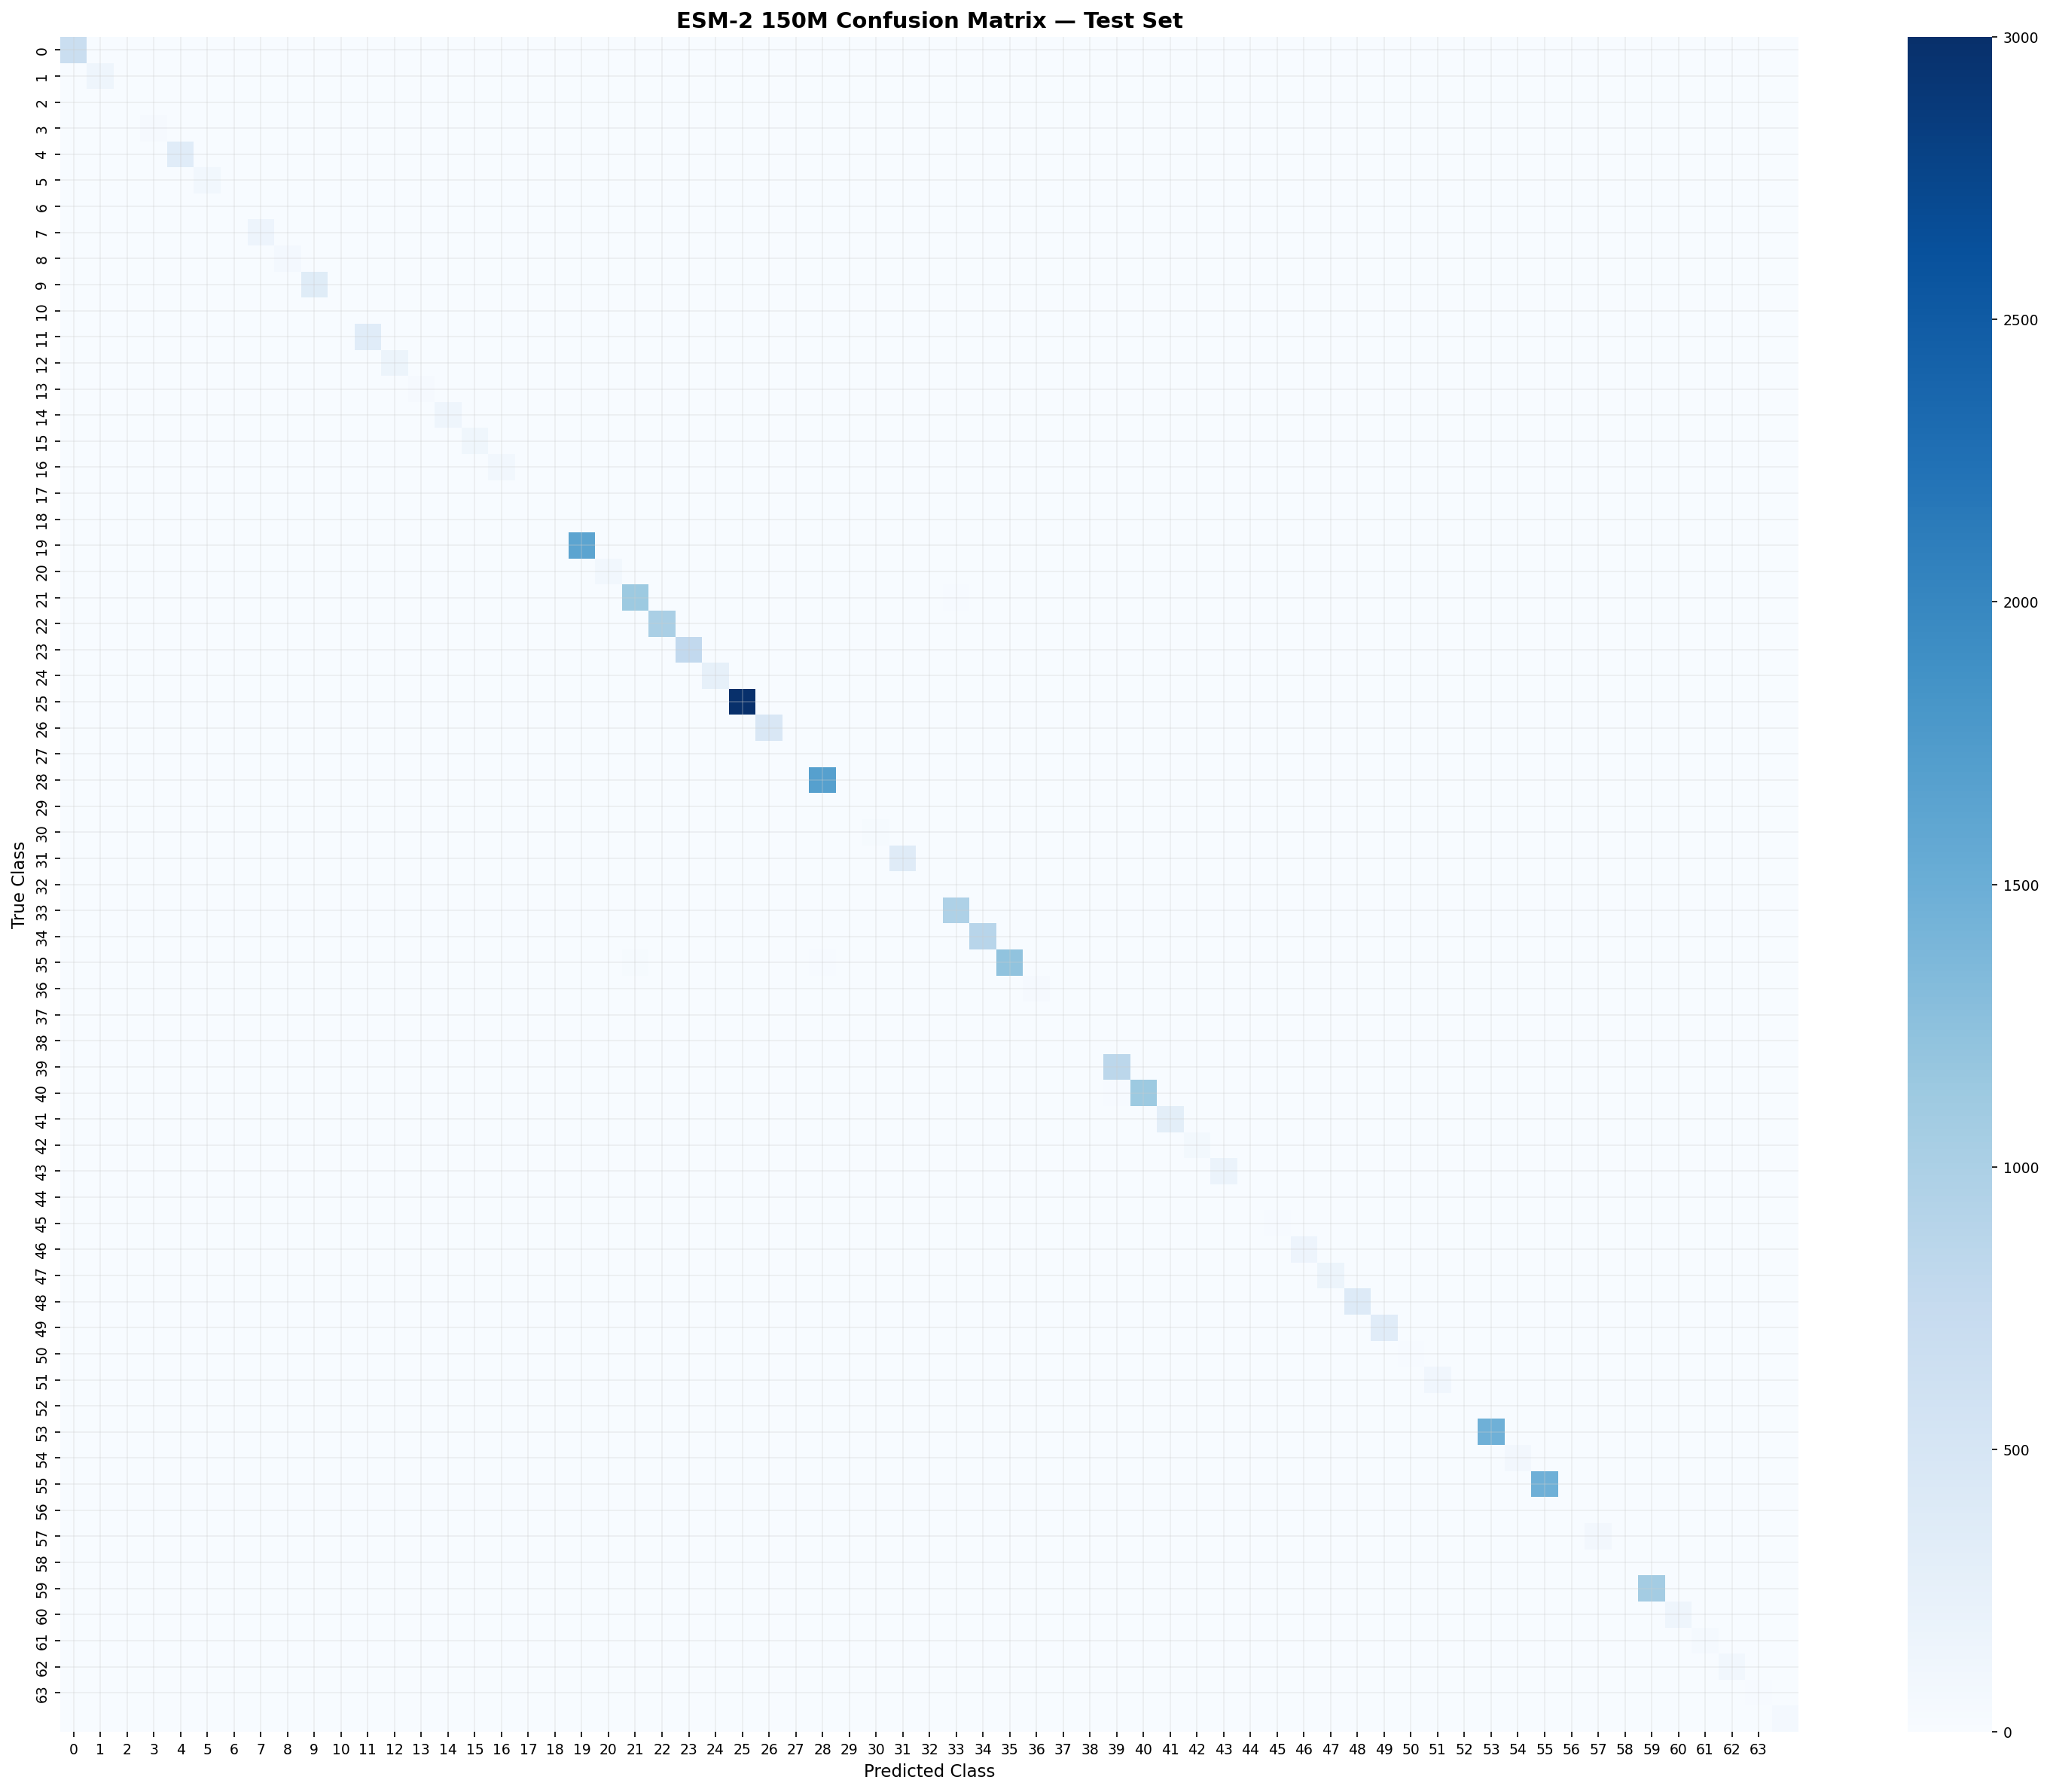

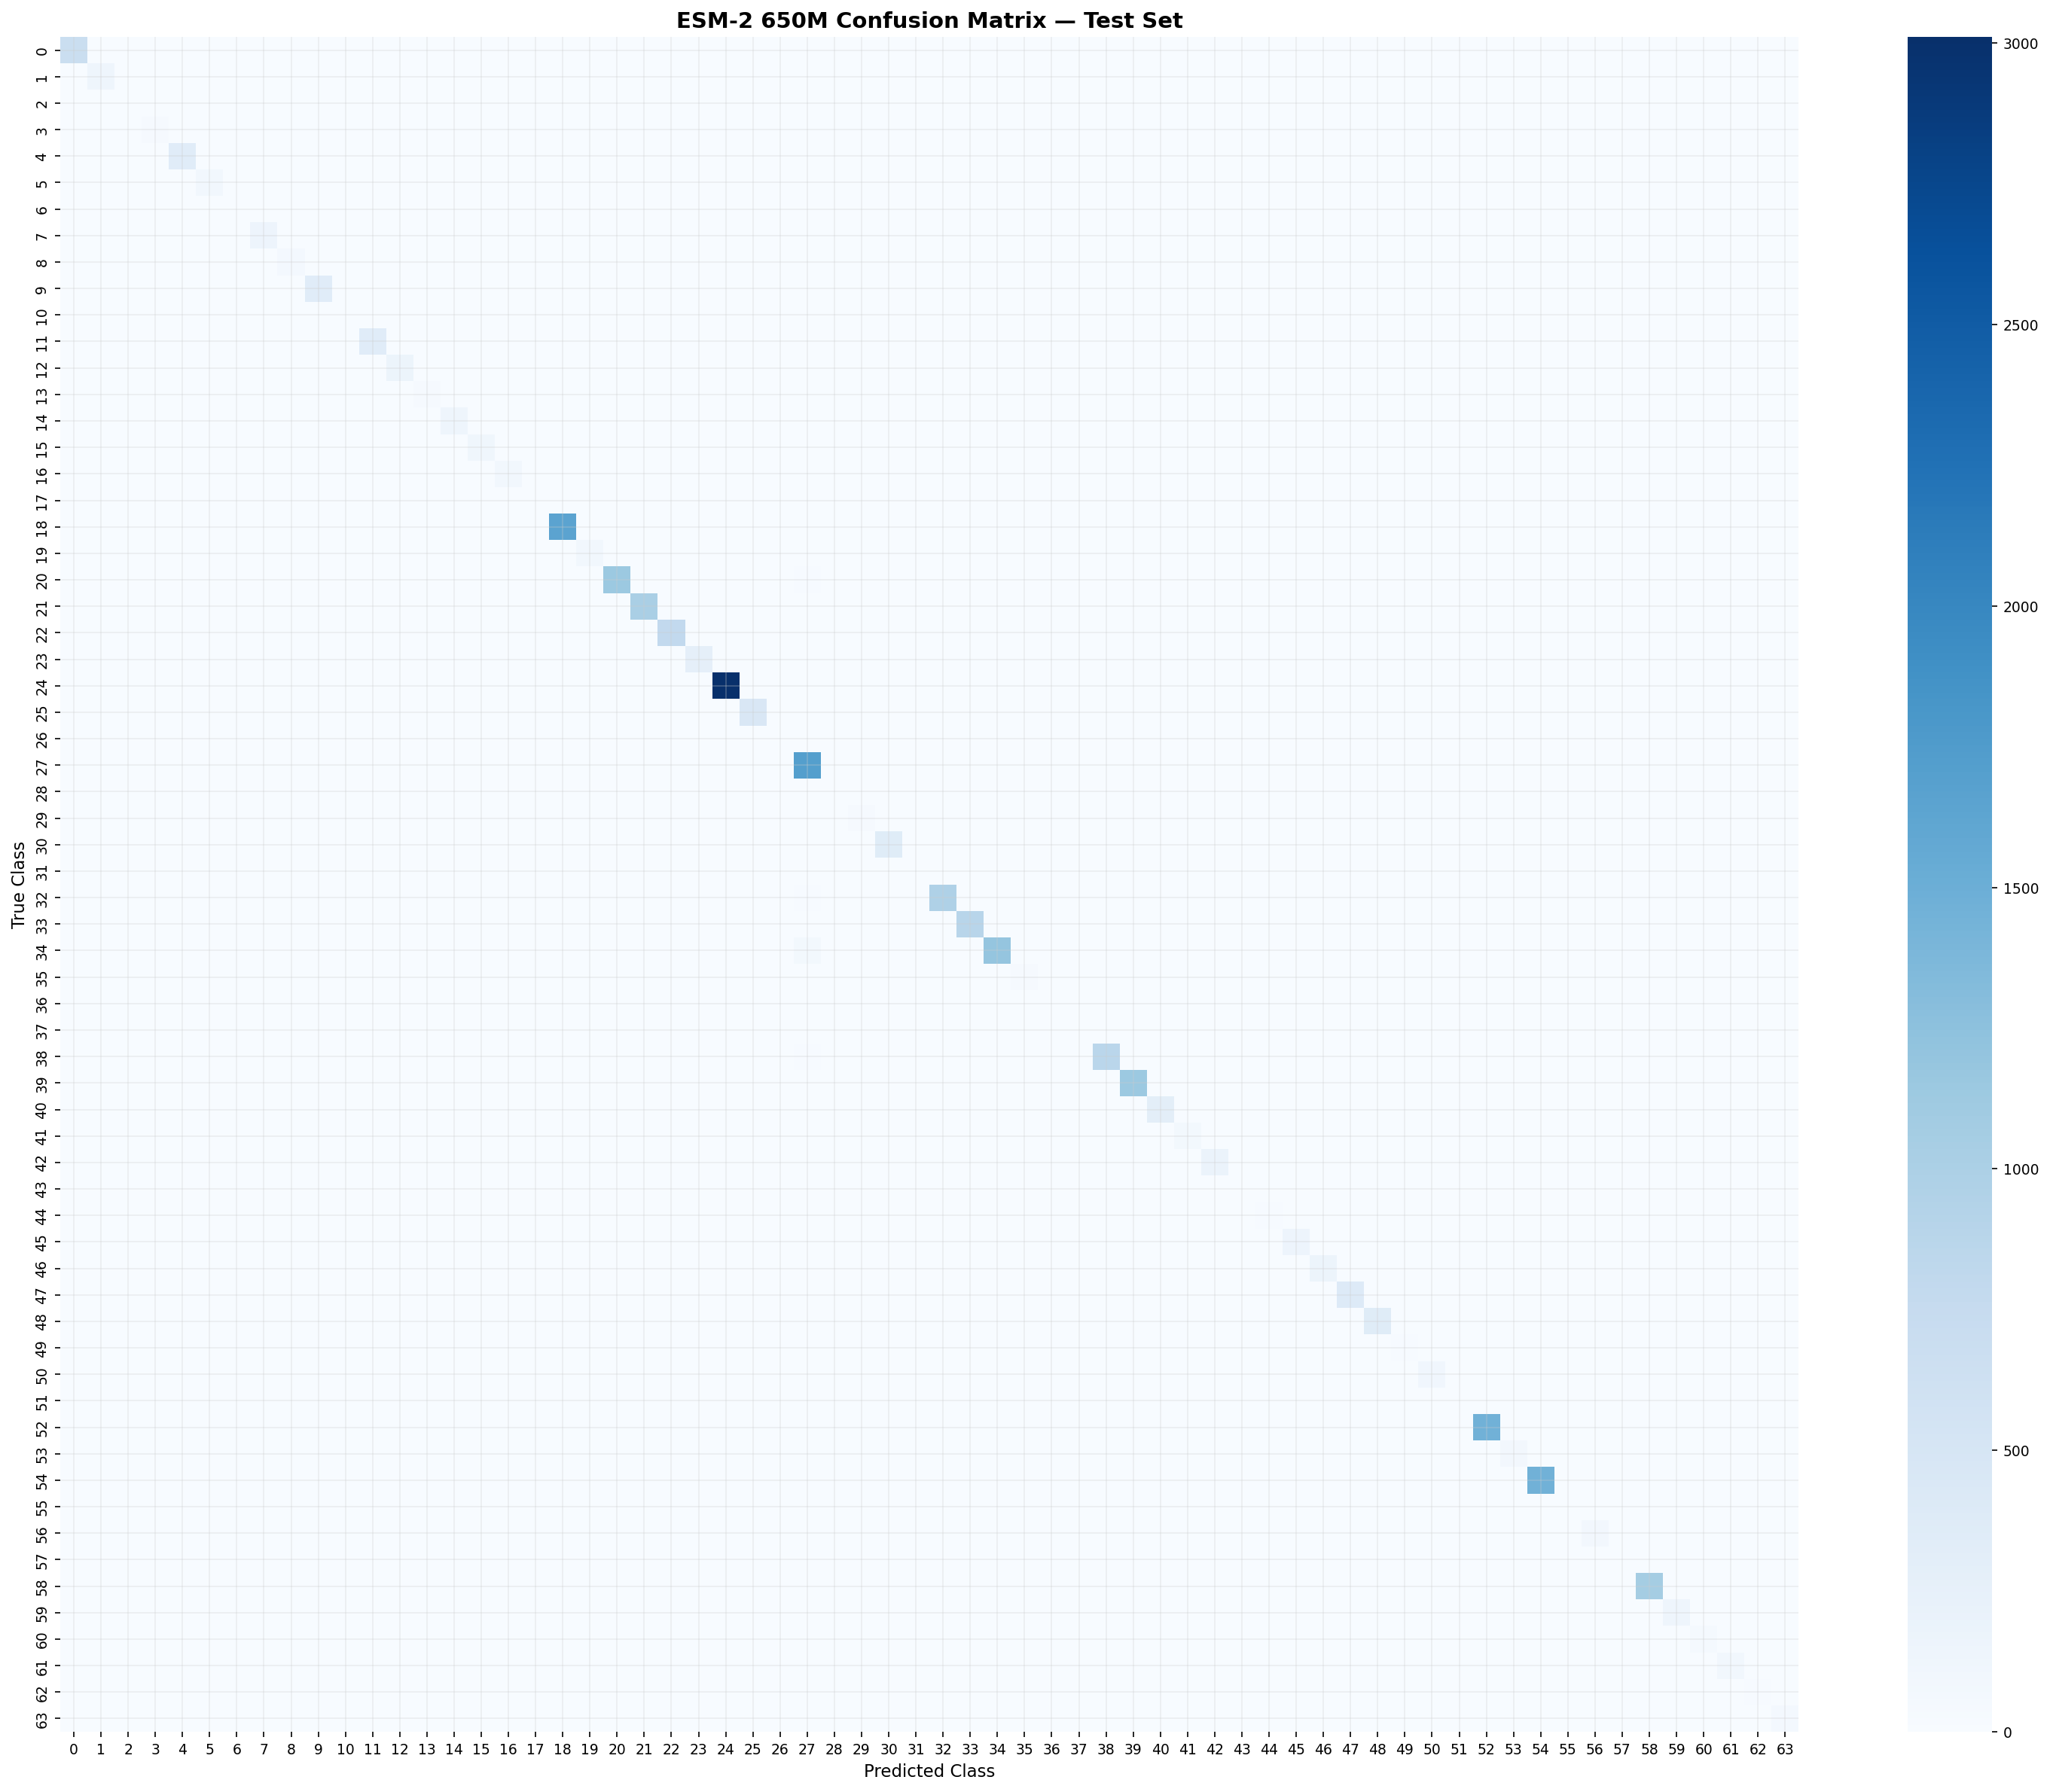

In [ ]:
# 1. Confusion Matrix
def plot_confusion_matrix(y_true, y_pred, title, save_path):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(20, 16))
    sns.heatmap(
        cm,
        annot = False,
        fmt = "d",
        cmap = "Blues",
        xticklabels = range(len(np.unique(y_true))),
        yticklabels = range(len(np.unique(y_true)))
    )
    plt.title(title, fontsize=14, fontweight="bold")
    plt.xlabel("Predicted Class")
    plt.ylabel("True Class")
    plt.tight_layout()
    plt.savefig(save_path)
    plt.show()

# Plot for both models
plot_confusion_matrix(
    y_test, y_pred_test_150m,
    "ESM-2 150M Confusion Matrix — Test Set",
    f"{PROJECT}/esm2_150m_confusion_matrix.png"
)

plot_confusion_matrix(
    y_test, y_pred_test_650m,
    "ESM-2 650M Confusion Matrix — Test Set",
    f"{PROJECT}/esm2_650m_confusion_matrix.png"
)

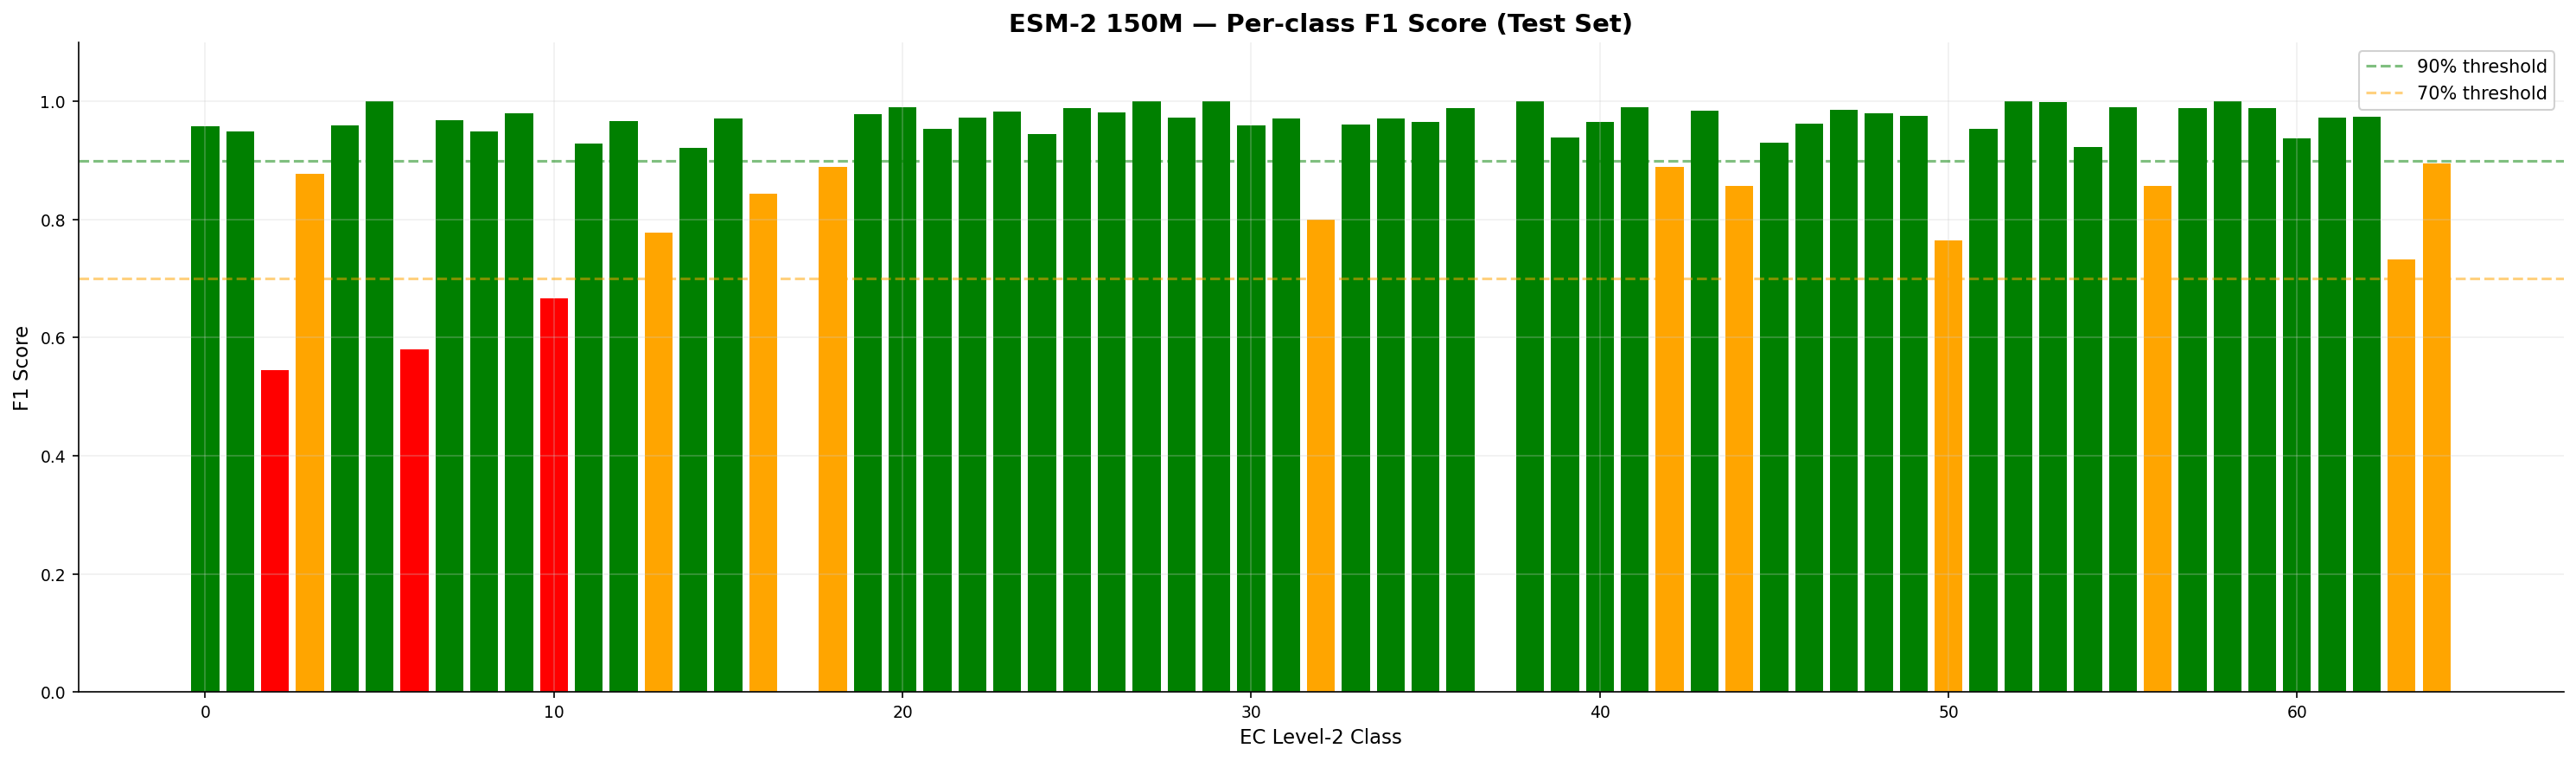

Classes with F1 > 0.90: 49
Classes with F1 < 0.50: 2


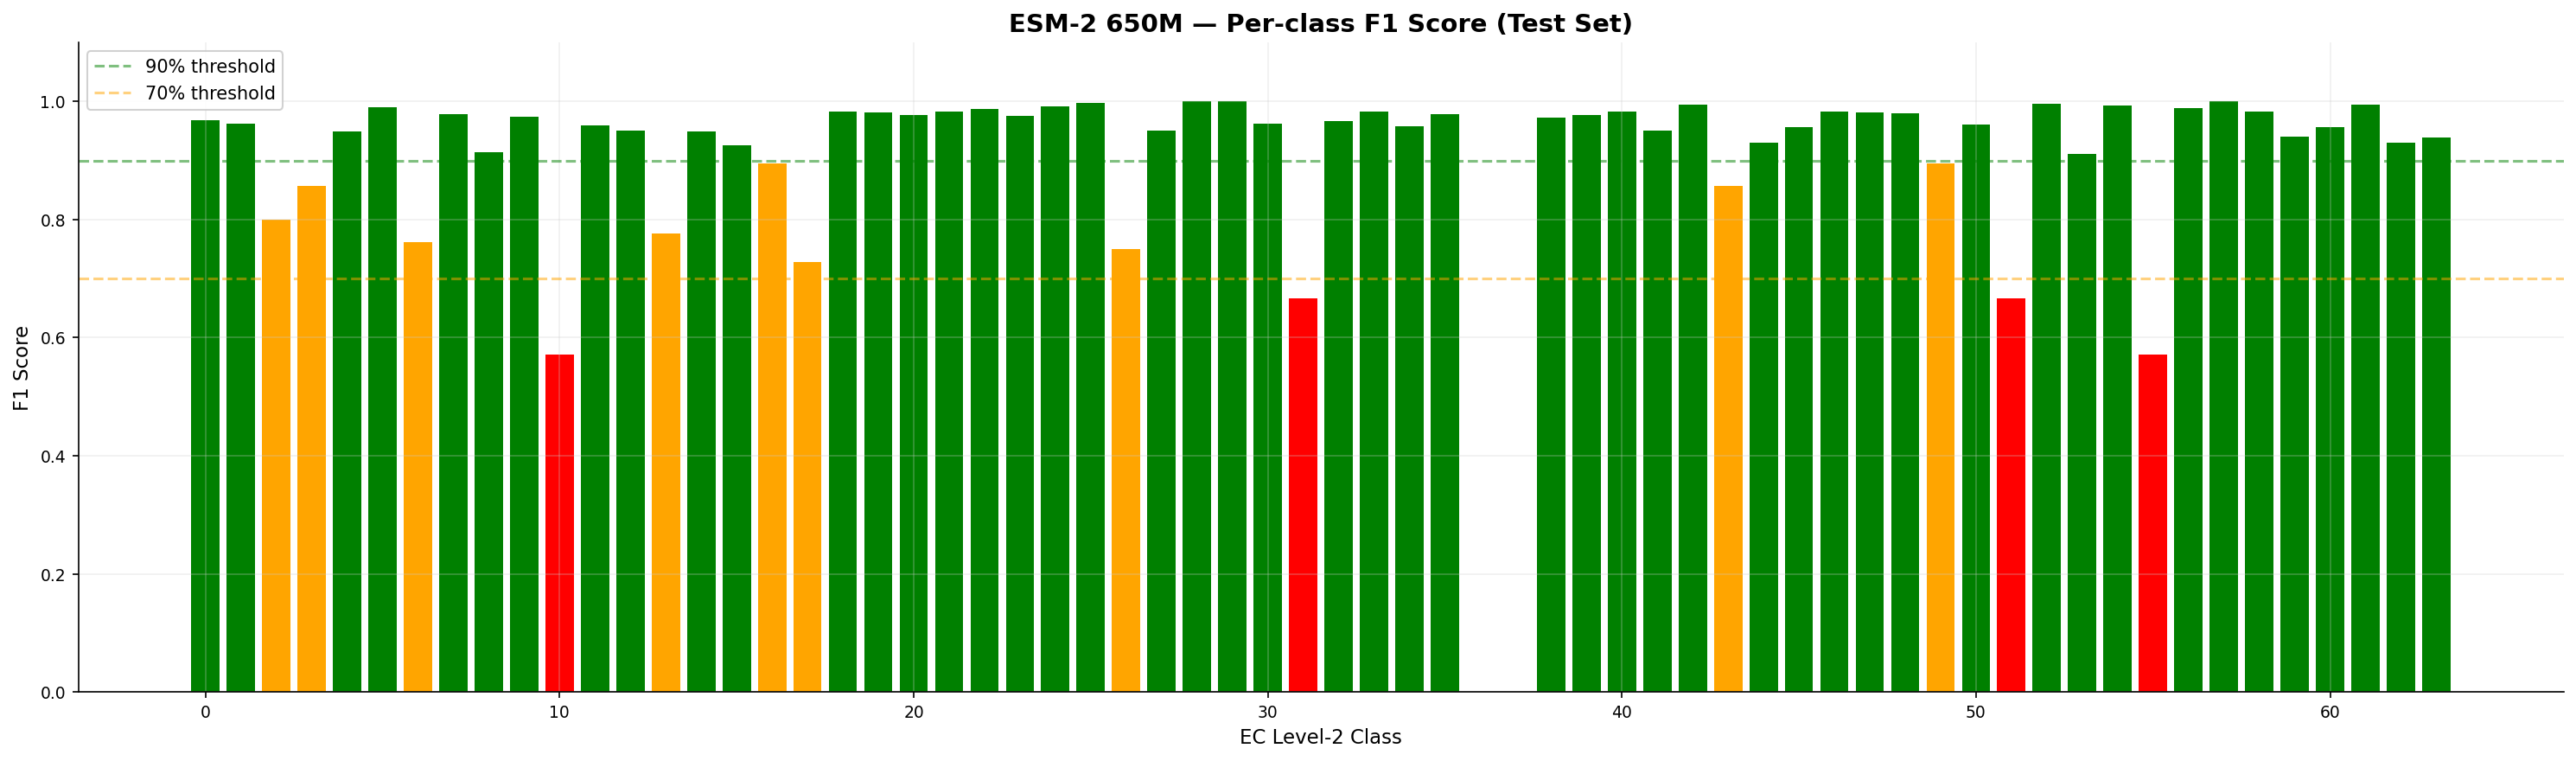

Classes with F1 > 0.90: 49
Classes with F1 < 0.50: 2


In [ ]:
# 2. Per-class F1 score bar chart

def plot_per_class_f1(y_true, y_pred, title, save_path):
    f1_scores = f1_score(y_true, y_pred, average=None, zero_division=0)
    classes   = range(len(f1_scores))

    plt.figure(figsize=(20, 6))
    bars = plt.bar(classes, f1_scores, color=[
        "green" if f >= 0.9 else
        "orange" if f >= 0.7 else
        "red" for f in f1_scores
    ])
    plt.axhline(y=0.9, color="green",  linestyle="--",
                alpha=0.5, label="90% threshold")
    plt.axhline(y=0.7, color="orange", linestyle="--",
                alpha=0.5, label="70% threshold")
    plt.title(title, fontsize=14, fontweight="bold")
    plt.xlabel("EC Level-2 Class")
    plt.ylabel("F1 Score")
    plt.ylim(0, 1.1)
    plt.legend()
    plt.tight_layout()
    plt.savefig(save_path)
    plt.show()
    print(f"Classes with F1 > 0.90: {(f1_scores >= 0.9).sum()}")
    print(f"Classes with F1 < 0.50: {(f1_scores < 0.5).sum()}")

plot_per_class_f1(
    y_test, y_pred_test_150m,
    "ESM-2 150M — Per-class F1 Score (Test Set)",
    f"{PROJECT}/esm2_150m_per_class_f1.png"
)

plot_per_class_f1(
    y_test, y_pred_test_650m,
    "ESM-2 650M — Per-class F1 Score (Test Set)",
    f"{PROJECT}/esm2_650m_per_class_f1.png"
)

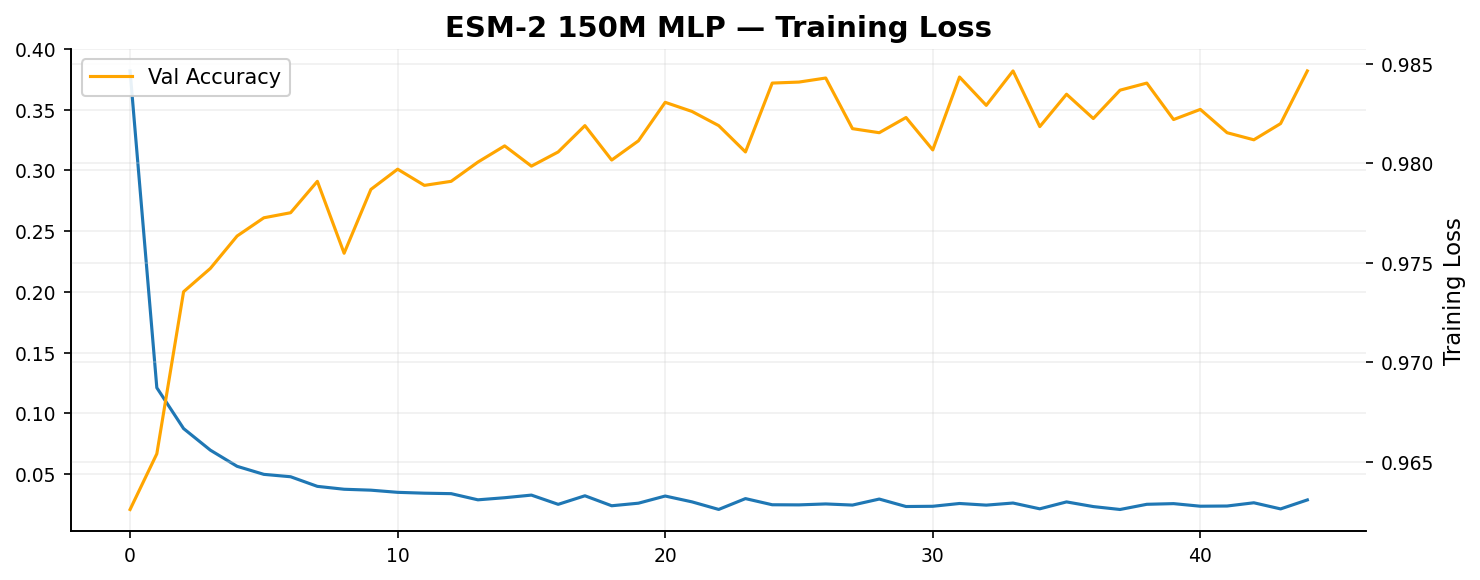

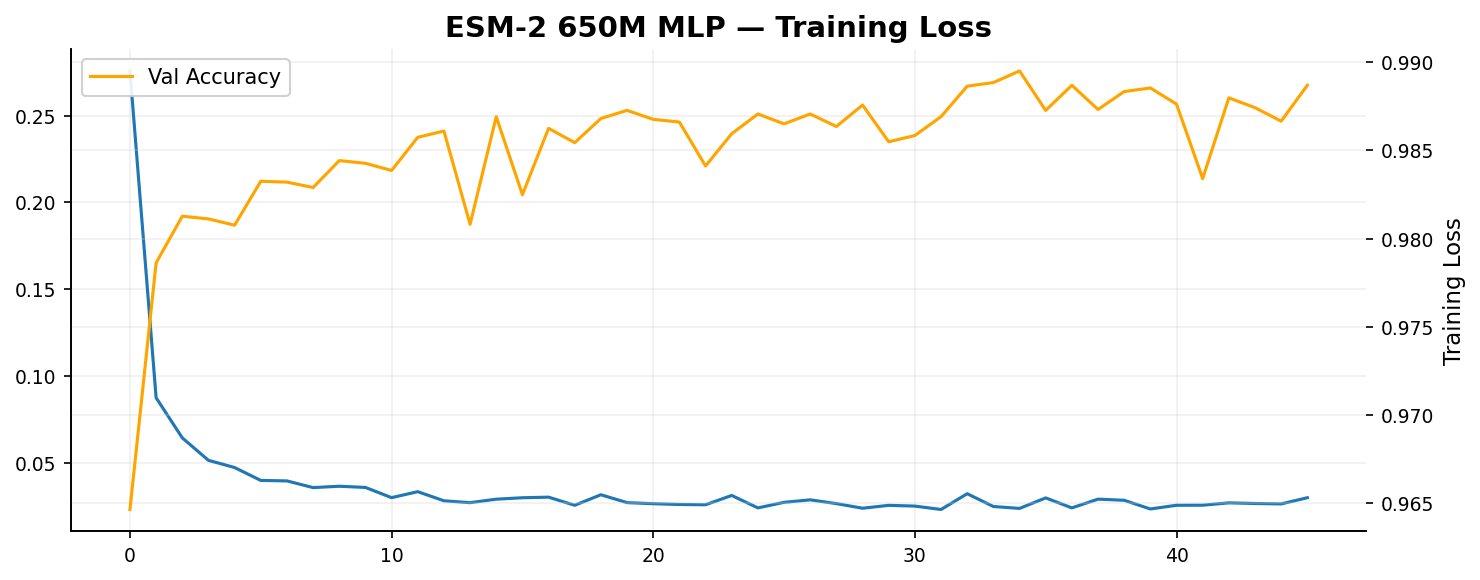

In [ ]:
# 3. MLP Training loss curve
# Plot sklearn MLP tracked loss

def plot_mlp_loss(mlp_model, title, save_path):
    plt.figure(figsize=(10, 4))
    plt.plot(mlp_model.loss_curve_, label="Training Loss")
    if hasattr(mlp_model, "validation_scores_"):
        # Plot validation accuracy
        ax2 = plt.twinx()
        ax2.plot(mlp_model.validation_scores_,
                 color="orange", label="Val Accuracy")
        ax2.set_ylabel("Validation Accuracy")
        ax2.legend(loc="upper right")
    plt.title(title, fontsize=14, fontweight="bold")
    plt.xlabel("Iteration")
    plt.ylabel("Training Loss")
    plt.legend(loc="upper left")
    plt.tight_layout()
    plt.savefig(save_path)
    plt.show()

plot_mlp_loss(
    mlp_150m,
    "ESM-2 150M MLP — Training Loss",
    f"{PROJECT}/esm2_150m_mlp_loss.png"
)

plot_mlp_loss(
    mlp_650m,
    "ESM-2 650M MLP — Training Loss",
    f"{PROJECT}/esm2_650m_mlp_loss.png"
)

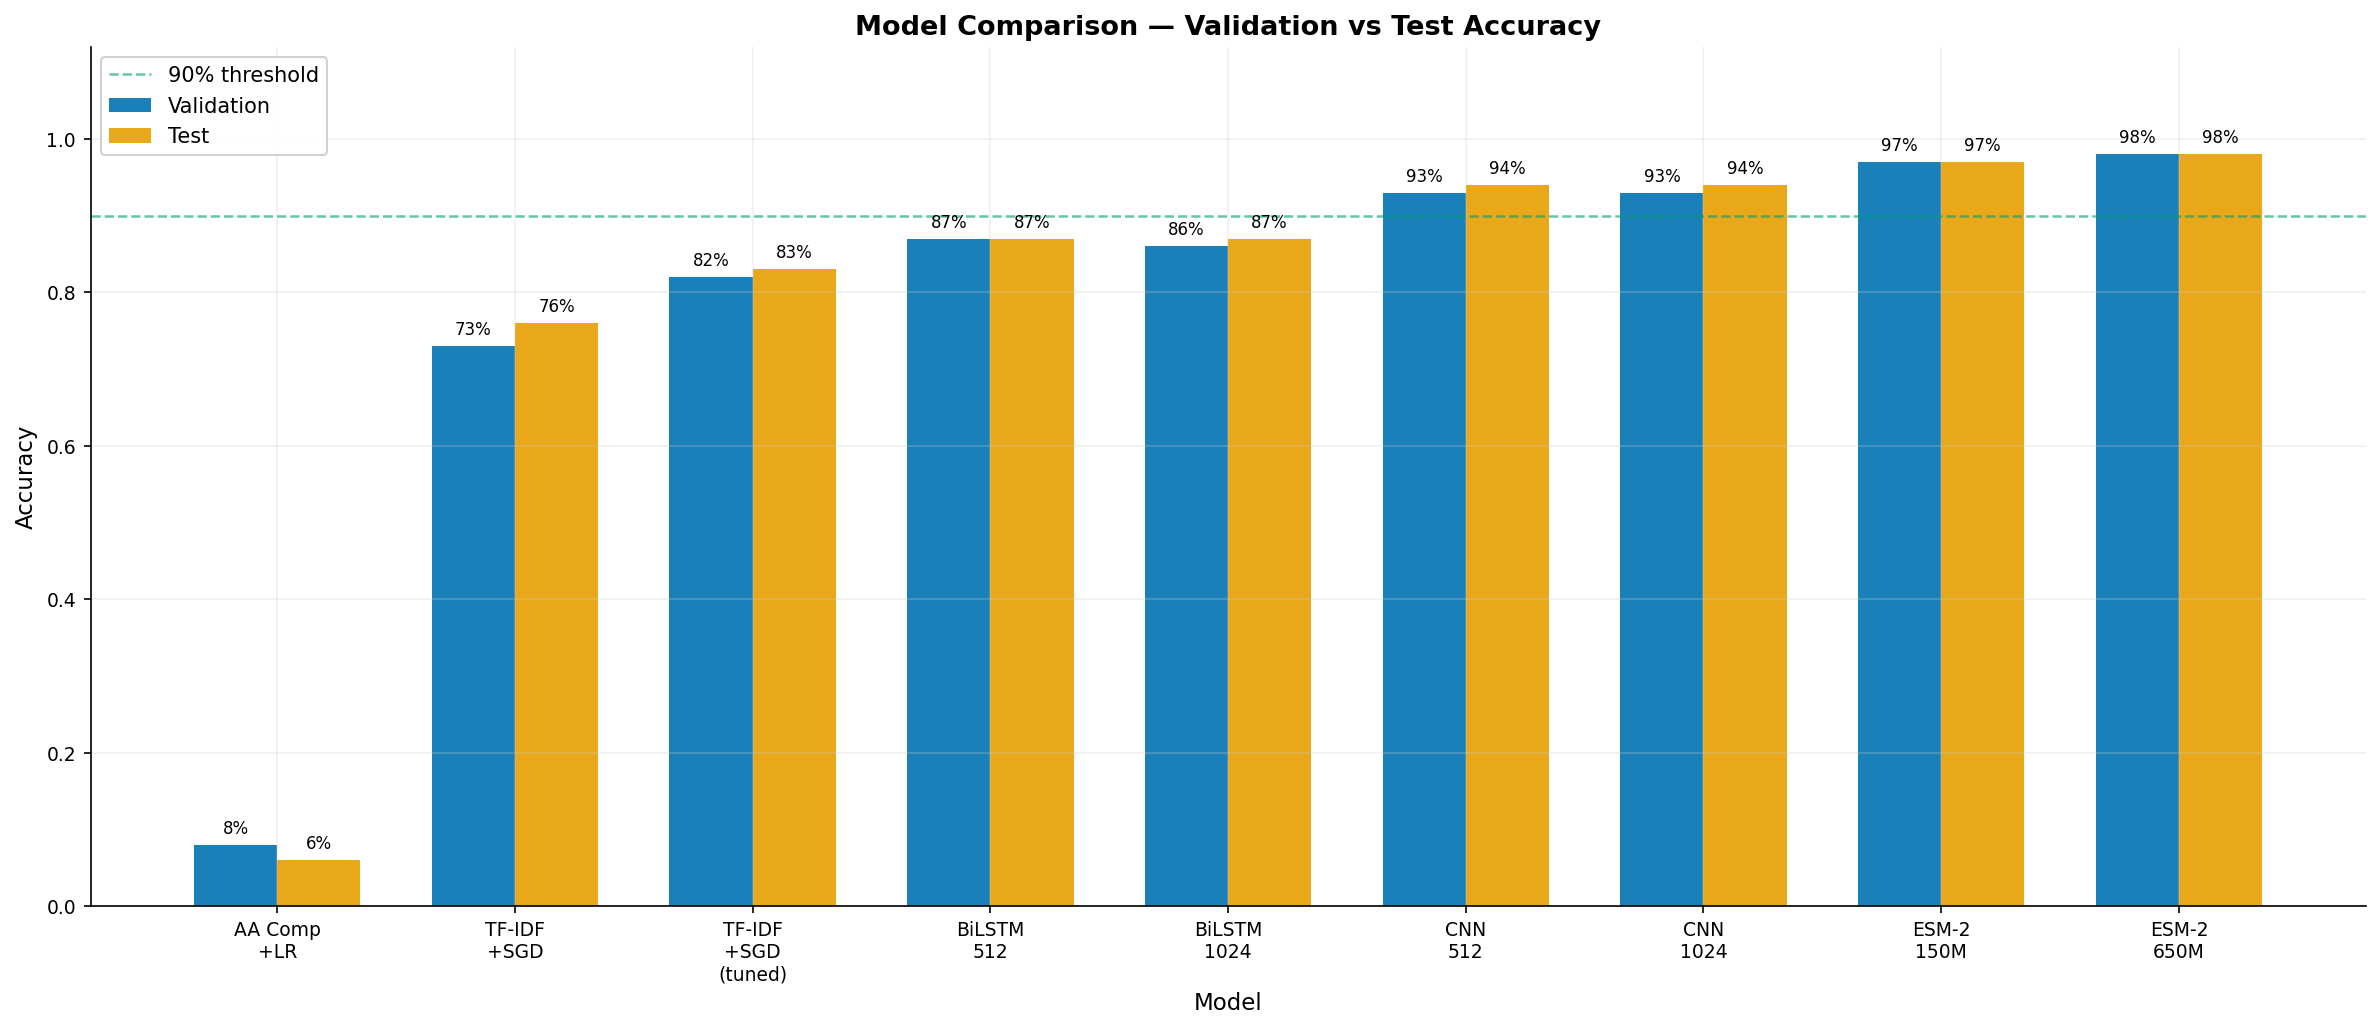

In [ ]:
models = [
    "AA Comp\n+LR",
    "TF-IDF\n+SGD",
    "TF-IDF\n+SGD\n(tuned)",
    "BiLSTM\n512",
    "BiLSTM\n1024",
    "CNN\n512",
    "CNN\n1024",
    "ESM-2\n150M",
    "ESM-2\n650M"
]

val_scores  = [0.08, 0.73, 0.82, 0.87, 0.86, 0.93, 0.93, 0.97, 0.98]
test_scores = [0.06, 0.76, 0.83, 0.87, 0.87, 0.94, 0.94, 0.97, 0.98]

x     = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(16, 7))
bars1 = ax.bar(x - width/2, val_scores,  width,
               label="Validation", color=COLORS["blue"],   alpha=0.9)
bars2 = ax.bar(x + width/2, test_scores, width,
               label="Test",       color=COLORS["orange"], alpha=0.9)

for bar in bars1 + bars2:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f"{bar.get_height():.0%}",
        ha="center", va="bottom", fontsize=8
    )

ax.axhline(0.9, color=COLORS["green"], linestyle="--",
           linewidth=1.2, alpha=0.6, label="90% threshold")
ax.set_xlabel("Model")
ax.set_ylabel("Accuracy")
ax.set_title("Model Comparison — Validation vs Test Accuracy")
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=9)
ax.set_ylim(0, 1.12)
ax.legend()
plt.tight_layout()
plt.savefig(f"{PROJECT}/all_models_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

**Part G**

In [ ]:
!pip install fair-esm -q

In [ ]:
from google.colab import drive
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import torch
import esm
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import SGDClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report

In [ ]:
drive.mount("/content/drive")

PROJECT = "/content/drive/MyDrive/MSc_Protein_EC_Project"

df_clean = pd.read_csv(f"{PROJECT}/ec2_singlelabel_clean_filtered.csv")
print(f"Dataset loaded: {df_clean.shape}")
print(f"Classes: {df_clean['EC_level2'].nunique()}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset loaded: (246331, 8)
Classes: 65


In [ ]:
# Random 80/10/10 split

# First cut: 80% train, 20% temp
df_train_rand, df_temp = train_test_split(
    df_clean,
    test_size=0.20,
    random_state=26,
    stratify=df_clean["EC_level2"]  # keeps class proportions balanced
)

# Second cut: split the 20% equally into val and test
df_val_rand, df_test_rand = train_test_split(
    df_temp,
    test_size=0.50,
    random_state=26,
    stratify=df_temp["EC_level2"]
)

print(f"Train: {df_train_rand.shape}")
print(f"Val:   {df_val_rand.shape}")
print(f"Test:  {df_test_rand.shape}")

Train: (197064, 8)
Val:   (24633, 8)
Test:  (24634, 8)


In [ ]:
#  Check for leakage (there will be some, that is the point)

train_ids_rand = set(df_train_rand["Entry"])
val_ids_rand   = set(df_val_rand["Entry"])
test_ids_rand  = set(df_test_rand["Entry"])

print("train/val overlap: ",  len(train_ids_rand & val_ids_rand))
print("train/test overlap:", len(train_ids_rand & test_ids_rand))
print("val/test overlap:  ",  len(val_ids_rand  & test_ids_rand))

# Now check how many test sequences share a cluster with a training sequence
# This is the real leakage, same family members in both sets
clusters = pd.read_csv(f"{PROJECT}/entry_to_cluster.tsv", sep="\t")

train_clusters = set(clusters[clusters["Entry"].isin(train_ids_rand)]["cluster_id"])
test_clusters  = set(clusters[clusters["Entry"].isin(test_ids_rand)]["cluster_id"])

shared_clusters = train_clusters & test_clusters
print(f"\nShared clusters between train and test: {len(shared_clusters)}")
print(f"This means sequences from the same protein family")
print(f"appear in both train and test, data leakage confirmed")

train/val overlap:  0
train/test overlap: 0
val/test overlap:   0

Shared clusters between train and test: 10705
This means sequences from the same protein family
appear in both train and test, data leakage confirmed


In [ ]:
# Label encode

label_encoder_rand = LabelEncoder()
df_train_rand["EC_level2_encoded"] = label_encoder_rand.fit_transform(df_train_rand["EC_level2"])
df_val_rand["EC_level2_encoded"]   = label_encoder_rand.transform(df_val_rand["EC_level2"])
df_test_rand["EC_level2_encoded"]  = label_encoder_rand.transform(df_test_rand["EC_level2"])

NUM_CLASSES_RAND = len(label_encoder_rand.classes_)
print(f"Number of classes: {NUM_CLASSES_RAND}")

y_train_rand = df_train_rand["EC_level2_encoded"].values
y_val_rand   = df_val_rand["EC_level2_encoded"].values
y_test_rand  = df_test_rand["EC_level2_encoded"].values

Number of classes: 65


**Model 1: TF-IDF + SGD on random split**

In [ ]:
vectorizer_rand = TfidfVectorizer(analyzer="char", ngram_range=(3, 5))
X_train_tfidf_rand = vectorizer_rand.fit_transform(df_train_rand["Sequence"])
X_val_tfidf_rand   = vectorizer_rand.transform(df_val_rand["Sequence"])
X_test_tfidf_rand  = vectorizer_rand.transform(df_test_rand["Sequence"])

print(f"TF-IDF shape: {X_train_tfidf_rand.shape}")

sgd_rand = SGDClassifier(
    loss="log_loss",
    class_weight="balanced",
    n_jobs=-1,
    random_state=26,
    max_iter=1000,
    tol=1e-4,
    alpha=1e-5,
    learning_rate="optimal"
)

sgd_rand.fit(X_train_tfidf_rand, y_train_rand)

y_pred_val_sgd_rand  = sgd_rand.predict(X_val_tfidf_rand)
y_pred_test_sgd_rand = sgd_rand.predict(X_test_tfidf_rand)

print("TF-IDF + SGD — Random Split — Validation:")
print(classification_report(y_val_rand, y_pred_val_sgd_rand, zero_division=0))

print("TF-IDF + SGD — Random Split — Test:")
print(classification_report(y_test_rand, y_pred_test_sgd_rand, zero_division=0))

sgd_rand_val  = (y_pred_val_sgd_rand  == y_val_rand).mean()
sgd_rand_test = (y_pred_test_sgd_rand == y_test_rand).mean()
print(f"Val: {sgd_rand_val:.1%}  |  Test: {sgd_rand_test:.1%}")

TF-IDF shape: (197064, 3015506)
TF-IDF + SGD — Random Split — Validation:
              precision    recall  f1-score   support

           0       0.92      0.90      0.91       811
           1       1.00      0.94      0.97       114
           2       1.00      0.75      0.86        12
           3       1.00      0.78      0.88        65
           4       0.60      0.91      0.72       400
           5       1.00      0.95      0.97        37
           6       1.00      0.90      0.95        31
           7       1.00      0.95      0.98       192
           8       0.98      0.90      0.94        58
           9       1.00      0.95      0.97       325
          10       1.00      0.83      0.91        12
          11       0.99      0.84      0.91       281
          12       1.00      0.94      0.97       153
          13       0.98      0.78      0.87        60
          14       1.00      0.93      0.96        70
          15       1.00      0.90      0.95       107
       

**Encode sequences for CNN**

In [ ]:
AMINO_ACIDS = list("ACDEFGHIKLMNPQRSTVWY")
aa_to_int   = {aa: idx + 1 for idx, aa in enumerate(AMINO_ACIDS)}
MAX_LEN     = 512

def encode_sequence(sequence):
    return [aa_to_int.get(aa, 0) for aa in sequence]

def encode_and_pad(sequences, max_len):
    encoded = [encode_sequence(seq) for seq in sequences]
    return keras.preprocessing.sequence.pad_sequences(
        encoded, maxlen=max_len, padding="post", truncating="post"
    )

X_train_rand = encode_and_pad(df_train_rand["Sequence"].tolist(), MAX_LEN)
X_val_rand   = encode_and_pad(df_val_rand["Sequence"].tolist(),   MAX_LEN)
X_test_rand  = encode_and_pad(df_test_rand["Sequence"].tolist(),  MAX_LEN)

print(f"Train: {X_train_rand.shape}")
print(f"Val:   {X_val_rand.shape}")
print(f"Test:  {X_test_rand.shape}")

Train: (197064, 512)
Val:   (24633, 512)
Test:  (24634, 512)


**Build CNN**

In [ ]:
def build_cnn(vocab_size, max_len, num_classes, embed_dim=64):
    """
    Three-block Conv1D network with kernel sizes 3, 7, 15 to capture
    short, medium and long sequence motifs before GlobalMaxPooling.
    """
    inputs = keras.Input(shape=(max_len,), name="sequence_input")

    x = layers.Embedding(
        input_dim=vocab_size + 1,
        output_dim=embed_dim,
        mask_zero=True,
        name="embedding"
    )(inputs)

    for filters, kernel, name in [(128, 3, "conv1"), (256, 7, "conv2"), (128, 15, "conv3")]:
        x = layers.Conv1D(filters=filters, kernel_size=kernel,
                          activation="relu", padding="same", name=name)(x)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(0.2)(x)

    x = layers.GlobalMaxPooling1D(name="global_max_pool")(x)

    x = layers.Dense(256, activation="relu", name="dense1")(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(128, activation="relu", name="dense2")(x)
    x = layers.Dropout(0.3)(x)

    outputs = layers.Dense(num_classes, activation="softmax", name="output")(x)

    return keras.Model(inputs=inputs, outputs=outputs)

**Train CNN on random split**

In [ ]:
cnn_rand = build_cnn(len(AMINO_ACIDS), MAX_LEN, NUM_CLASSES_RAND)
cnn_rand.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks_cnn_rand = [
    keras.callbacks.ModelCheckpoint(
        filepath=f"{PROJECT}/cnn_rand_split_best.keras",
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=7,
        verbose=1,
        restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_accuracy",
        factor=0.5,
        patience=3,
        verbose=1
    )
]

print("Training CNN on random split...")
history_cnn_rand = cnn_rand.fit(
    X_train_rand, y_train_rand,
    validation_data=(X_val_rand, y_val_rand),
    epochs=60,
    batch_size=256,
    callbacks=callbacks_cnn_rand,
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'conv1' (of type Conv1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


Training CNN on random split...
Epoch 1/60
770/770 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.1583 - loss: 3.3238
Epoch 1: val_accuracy improved from None to 0.59100, saving model to /content/drive/MyDrive/MSc_Protein_EC_Project/cnn_rand_split_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/MSc_Protein_EC_Project/cnn_rand_split_best.keras
770/770 ━━━━━━━━━━━━━━━━━━━━ 56s 47ms/step - accuracy: 0.2690 - loss: 2.7826 - val_accuracy: 0.5910 - val_loss: 1.7080 - learning_rate: 0.0010
Epoch 2/60
769/770 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5585 - loss: 1.6558
Epoch 2: val_accuracy improved from 0.59100 to 0.77831, saving model to /content/drive/MyDrive/MSc_Protein_EC_Project/cnn_rand_split_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/MSc_Protein_EC_Project/cnn_rand_split_best.keras
770/770 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.6018 - loss: 1.5030 - val_accuracy: 0.7783 - val_loss: 0.9014 - learning_rate: 0.0010
Epoch 3/6

**Evaluate CNN and plot training curves**

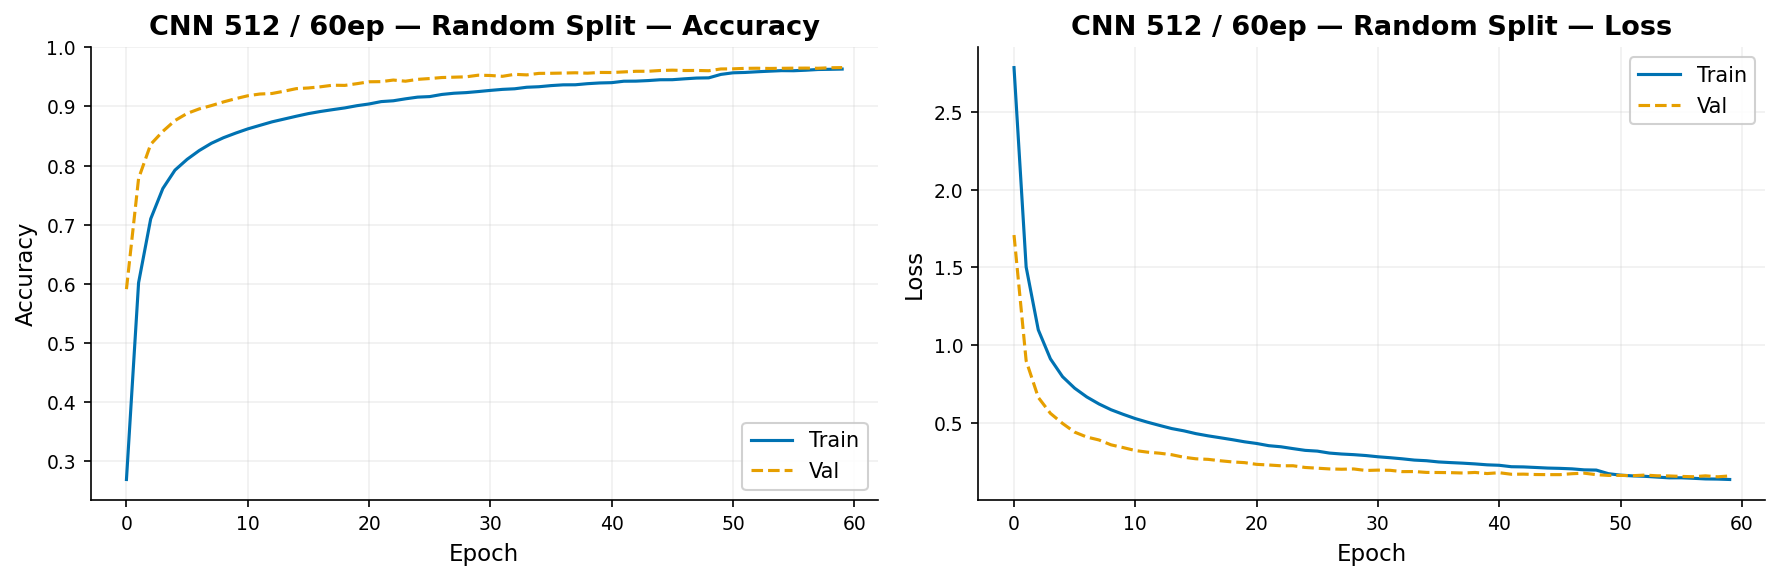

770/770 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step
770/770 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step
CNN Random Split — Val: 96.6%  |  Test: 96.5%
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       812
           1       0.99      0.91      0.95       113
           2       1.00      0.50      0.67        12
           3       0.98      0.67      0.80        64
           4       0.95      0.93      0.94       400
           5       1.00      0.97      0.99        36
           6       0.96      0.80      0.87        30
           7       0.98      0.95      0.97       192
           8       0.93      0.95      0.94        57
           9       1.00      0.97      0.98       325
          10       1.00      0.64      0.78        11
          11       0.97      0.91      0.94       282
          12       0.94      0.95      0.94       154
          13       0.87      0.69      0.77        59
          14       0.90      0.94      0.92        69
       

In [ ]:
COLORS = {
    "blue":   "#0072B2",
    "orange": "#E69F00",
    "green":  "#009E73",
    "red":    "#D55E00",
}

mpl.rcParams.update({
    "figure.dpi":       150,
    "figure.facecolor": "white",
    "axes.facecolor":   "white",
    "axes.grid":        True,
    "grid.alpha":       0.3,
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "font.family":      "DejaVu Sans",
    "axes.titleweight": "bold",
})

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history_cnn_rand.history["accuracy"],     color=COLORS["blue"],   label="Train")
ax1.plot(history_cnn_rand.history["val_accuracy"], color=COLORS["orange"], label="Val", linestyle="--")
ax1.set_title("CNN 512 / 60ep — Random Split — Accuracy")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Accuracy")
ax1.legend()

ax2.plot(history_cnn_rand.history["loss"],     color=COLORS["blue"],   label="Train")
ax2.plot(history_cnn_rand.history["val_loss"], color=COLORS["orange"], label="Val", linestyle="--")
ax2.set_title("CNN 512 / 60ep — Random Split — Loss")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Loss")
ax2.legend()

plt.tight_layout()
plt.savefig(f"{PROJECT}/cnn_rand_split_history.png", dpi=150, bbox_inches="tight")
plt.show()

y_pred_val_cnn_rand  = np.argmax(cnn_rand.predict(X_val_rand),  axis=1)
y_pred_test_cnn_rand = np.argmax(cnn_rand.predict(X_test_rand), axis=1)

cnn_rand_val  = (y_pred_val_cnn_rand  == y_val_rand).mean()
cnn_rand_test = (y_pred_test_cnn_rand == y_test_rand).mean()

print(f"CNN Random Split — Val: {cnn_rand_val:.1%}  |  Test: {cnn_rand_test:.1%}")
print(classification_report(y_test_rand, y_pred_test_cnn_rand, zero_division=0))

**ESM-2 650M embeddings on random split**

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using: {device}")

esm2_650m, alphabet = esm.pretrained.esm2_t33_650M_UR50D()
esm2_650m = esm2_650m.to(device)
esm2_650m.eval()
batch_converter = alphabet.get_batch_converter()

def get_esm_embeddings(sequences, batch_size=32):
    embeddings = []
    for i in range(0, len(sequences), batch_size):
        batch = sequences[i:i+batch_size]
        data  = [(str(j), seq) for j, seq in enumerate(batch)]
        _, _, tokens = batch_converter(data)
        tokens = tokens.to(device)
        with torch.no_grad():
            results = esm2_650m(tokens, repr_layers=[33])
        reps = results["representations"][33]
        for j, seq in enumerate(batch):
            emb = reps[j, 1:len(seq)+1].mean(dim=0).cpu().numpy()
            embeddings.append(emb)
        if (i // batch_size) % 10 == 0:
            print(f"  Processed {i + len(batch):,} / {len(sequences):,}")
    return np.array(embeddings)

print("Generating ESM-2 650M embeddings for random split")
train_emb_rand = get_esm_embeddings(df_train_rand["Sequence"].tolist())
val_emb_rand   = get_esm_embeddings(df_val_rand["Sequence"].tolist())
test_emb_rand  = get_esm_embeddings(df_test_rand["Sequence"].tolist())

print(f"Train: {train_emb_rand.shape}")
print(f"Val:   {val_emb_rand.shape}")
print(f"Test:  {test_emb_rand.shape}")

np.save(f"{PROJECT}/esm2_650m_rand_train.npy", train_emb_rand)
np.save(f"{PROJECT}/esm2_650m_rand_val.npy",   val_emb_rand)
np.save(f"{PROJECT}/esm2_650m_rand_test.npy",  test_emb_rand)
print("Embeddings saved to Drive")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.1/93.1 kB 11.2 MB/s eta 0:00:00
Using: cuda
Downloading: "https://dl.fbaipublicfiles.com/fair-esm/models/esm2_t33_650M_UR50D.pt" to /root/.cache/torch/hub/checkpoints/esm2_t33_650M_UR50D.pt
Downloading: "https://dl.fbaipublicfiles.com/fair-esm/regression/esm2_t33_650M_UR50D-contact-regression.pt" to /root/.cache/torch/hub/checkpoints/esm2_t33_650M_UR50D-contact-regression.pt
Generating ESM-2 650M embeddings for random split
  Processed 32 / 197,064
  Processed 352 / 197,064
  Processed 672 / 197,064
  Processed 992 / 197,064
  Processed 1,312 / 197,064
  Processed 1,632 / 197,064
  Processed 1,952 / 197,064
  Processed 2,272 / 197,064
  Processed 2,592 / 197,064
  Processed 2,912 / 197,064
  Processed 3,232 / 197,064
  Processed 3,552 / 197,064
  Processed 3,872 / 197,064
  Processed 4,192 / 197,064
  Processed 4,512 / 197,064
  Processed 4,832 / 197,064
  Processed 5,152 / 197,064
  Processed 5,472 / 197,064
  Processed 5,792 / 197,064
  

In [ ]:
train_emb_rand = np.load(f"{PROJECT}/esm2_650m_rand_train.npy")
val_emb_rand   = np.load(f"{PROJECT}/esm2_650m_rand_val.npy")
test_emb_rand  = np.load(f"{PROJECT}/esm2_650m_rand_test.npy")

print(f"Train: {train_emb_rand.shape}")
print(f"Val:   {val_emb_rand.shape}")
print(f"Test:  {test_emb_rand.shape}")

Train: (197064, 1280)
Val:   (24633, 1280)
Test:  (24634, 1280)


**Train ESM-2 MLP on random split**

In [ ]:
scaler_rand   = StandardScaler()
X_train_esm_rand = scaler_rand.fit_transform(train_emb_rand)
X_val_esm_rand   = scaler_rand.transform(val_emb_rand)
X_test_esm_rand  = scaler_rand.transform(test_emb_rand)

mlp_rand = MLPClassifier(
    hidden_layer_sizes=(512, 256),
    activation="relu",
    max_iter=200,
    random_state=26,
    verbose=True,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=10

)

print("Training ESM-2 650M MLP on random split.")
mlp_rand.fit(X_train_esm_rand, y_train_rand)

y_pred_val_esm_rand  = mlp_rand.predict(X_val_esm_rand)
y_pred_test_esm_rand = mlp_rand.predict(X_test_esm_rand)

esm_rand_val  = (y_pred_val_esm_rand  == y_val_rand).mean()
esm_rand_test = (y_pred_test_esm_rand == y_test_rand).mean()

print(f"ESM-2 650M Random Split — Val: {esm_rand_val:.1%}  |  Test: {esm_rand_test:.1%}")
print(classification_report(y_test_rand, y_pred_test_esm_rand, zero_division=0))

Training ESM-2 650M MLP on random split.
Iteration 1, loss = 0.27962062
Validation score: 0.973867
Iteration 2, loss = 0.08763526
Validation score: 0.977368
Iteration 3, loss = 0.06420537
Validation score: 0.978231
Iteration 4, loss = 0.05546892
Validation score: 0.978231
Iteration 5, loss = 0.04511538
Validation score: 0.982798
Iteration 6, loss = 0.04123728
Validation score: 0.981986
Iteration 7, loss = 0.03991388
Validation score: 0.979347
Iteration 8, loss = 0.03799868
Validation score: 0.976912
Iteration 9, loss = 0.03724267
Validation score: 0.984016
Iteration 10, loss = 0.03091124
Validation score: 0.983102
Iteration 11, loss = 0.03073257
Validation score: 0.979347
Iteration 12, loss = 0.02963836
Validation score: 0.983305
Iteration 13, loss = 0.03411116
Validation score: 0.983052
Iteration 14, loss = 0.02607060
Validation score: 0.982646
Iteration 15, loss = 0.03414213
Validation score: 0.984270
Iteration 16, loss = 0.02504101
Validation score: 0.983102
Iteration 17, loss = 0.0

**Final comparison table and bar chart**


Model                  Sim Val  Sim Test  Rand Val Rand Test   Leakage
----------------------------------------------------------------------
TF-IDF + SGD             82.0%     83.0%     89.4%     89.4%     +6.4%
CNN 512/60ep             93.0%     94.0%     96.6%     96.5%     +2.5%
ESM-2 650M               98.0%     98.0%     98.8%     98.8%     +0.8%


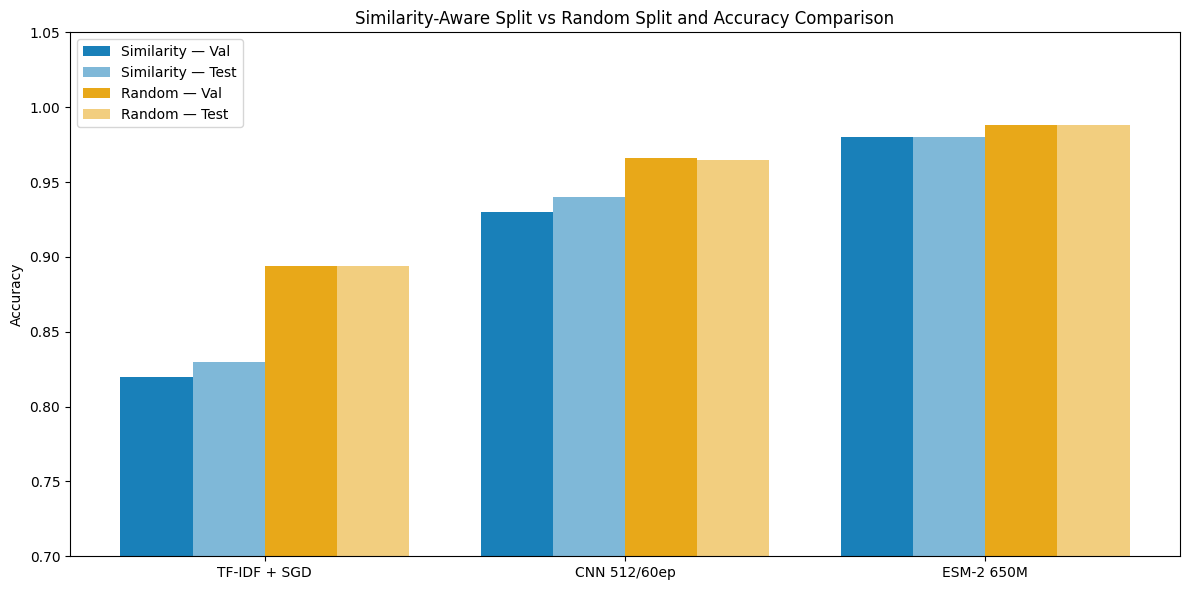

In [ ]:
COLORS = {
    "blue":   "#0072B2",
    "orange": "#E69F00",
    "green":  "#009E73",
    "red":    "#D55E00",
}

models = ["TF-IDF + SGD", "CNN 512/60ep", "ESM-2 650M"]

# Similarity-aware split results
sim_val  = [0.82, 0.93, 0.98]
sim_test = [0.83, 0.94, 0.98]

# Random split results
rand_val  = [0.894, 0.966, 0.988]
rand_test = [0.894, 0.965, 0.988]

print(f"\n{'Model':<20} {'Sim Val':>9} {'Sim Test':>9} {'Rand Val':>9} {'Rand Test':>9} {'Leakage':>9}")

for i, m in enumerate(models):
    leakage = rand_test[i] - sim_test[i]
    print(f"{m:<20} {sim_val[i]:>9.1%} {sim_test[i]:>9.1%} {rand_val[i]:>9.1%} {rand_test[i]:>9.1%} {leakage:>+9.1%}")

x     = np.arange(len(models))
width = 0.2

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - width*1.5, sim_val,   width, label="Similarity — Val",  color=COLORS["blue"],   alpha=0.9)
ax.bar(x - width*0.5, sim_test,  width, label="Similarity — Test", color=COLORS["blue"],   alpha=0.5)
ax.bar(x + width*0.5, rand_val,  width, label="Random — Val",      color=COLORS["orange"], alpha=0.9)
ax.bar(x + width*1.5, rand_test, width, label="Random — Test",     color=COLORS["orange"], alpha=0.5)

ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(0.7, 1.05)
ax.set_ylabel("Accuracy")
ax.set_title("Similarity-Aware Split vs Random Split and Accuracy Comparison")
ax.legend()
plt.tight_layout()
plt.savefig(f"{PROJECT}/random_vs_similarity_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

**Part H**

**Biological Interpretation**

In [ ]:
from google.colab import drive
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import f1_score, classification_report

drive.mount("/content/drive")

PROJECT = "/content/drive/MyDrive/MSc_Protein_EC_Project"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Load data and rebuild splits**

In [ ]:
df_clean = pd.read_csv(f"{PROJECT}/ec2_singlelabel_clean_filtered.csv")

train_ids = set(open(f"{PROJECT}/similarity_train.txt").read().split())
val_ids   = set(open(f"{PROJECT}/similarity_val.txt").read().split())
test_ids  = set(open(f"{PROJECT}/similarity_test.txt").read().split())

df_train = df_clean[df_clean["Entry"].isin(train_ids)].copy()
df_val   = df_clean[df_clean["Entry"].isin(val_ids)].copy()
df_test  = df_clean[df_clean["Entry"].isin(test_ids)].copy()

train_classes = set(df_train["EC_level2"])
df_val  = df_val[df_val["EC_level2"].isin(train_classes)].copy()
df_test = df_test[df_test["EC_level2"].isin(train_classes)].copy()

label_encoder = LabelEncoder()
df_train["EC_level2_encoded"] = label_encoder.fit_transform(df_train["EC_level2"])
df_val["EC_level2_encoded"]   = label_encoder.transform(df_val["EC_level2"])
df_test["EC_level2_encoded"]  = label_encoder.transform(df_test["EC_level2"])

y_train = df_train["EC_level2_encoded"].values
y_val   = df_val["EC_level2_encoded"].values
y_test  = df_test["EC_level2_encoded"].values

# Map each integer label back to its EC level-2 string
int_to_ec2 = {i: ec for i, ec in enumerate(label_encoder.classes_)}

NUM_CLASSES = df_train["EC_level2_encoded"].nunique()
print(f"Train: {df_train.shape}, Val: {df_val.shape}, Test: {df_test.shape}")
print(f"Number of classes: {NUM_CLASSES}")

Train: (196472, 9), Val: (24363, 9), Test: (25496, 9)
Number of classes: 65


**Load saved embeddings and retrain MLP**

In [ ]:
# Loading from Drive
train_emb = np.load(f"{PROJECT}/esm2_650m_train.npy")
val_emb   = np.load(f"{PROJECT}/esm2_650m_val.npy")
test_emb  = np.load(f"{PROJECT}/esm2_650m_test.npy")

scaler       = StandardScaler()
X_train      = scaler.fit_transform(train_emb)
X_val        = scaler.transform(val_emb)
X_test       = scaler.transform(test_emb)

mlp = MLPClassifier(
    hidden_layer_sizes  = (512, 256),
    activation          = "relu",
    max_iter            = 200,
    random_state        = 26,
    verbose             = True,
    early_stopping      = True,
    validation_fraction = 0.1,
    n_iter_no_change    = 10
)
mlp.fit(X_train, y_train)

y_pred = mlp.predict(X_test)
print(f"\nOverall test accuracy: {(y_pred == y_test).mean():.1%}")

Iteration 1, loss = 0.27574384
Validation score: 0.964627
Iteration 2, loss = 0.08738289
Validation score: 0.978624
Iteration 3, loss = 0.06425193
Validation score: 0.981270
Iteration 4, loss = 0.05130993
Validation score: 0.981118
Iteration 5, loss = 0.04715889
Validation score: 0.980761
Iteration 6, loss = 0.03972477
Validation score: 0.983255
Iteration 7, loss = 0.03944735
Validation score: 0.983204
Iteration 8, loss = 0.03559206
Validation score: 0.982899
Iteration 9, loss = 0.03637305
Validation score: 0.984426
Iteration 10, loss = 0.03568943
Validation score: 0.984273
Iteration 11, loss = 0.02979513
Validation score: 0.983866
Iteration 12, loss = 0.03324641
Validation score: 0.985749
Iteration 13, loss = 0.02799117
Validation score: 0.986105
Iteration 14, loss = 0.02689857
Validation score: 0.980812
Iteration 15, loss = 0.02891969
Validation score: 0.986920
Iteration 16, loss = 0.02974136
Validation score: 0.982492
Iteration 17, loss = 0.03008300
Validation score: 0.986258
Iterat

**Build the per-class F1 table with EC1 grouping**

In [ ]:
ec1_names = {
    "1": "Oxidoreductases",
    "2": "Transferases",
    "3": "Hydrolases",
    "4": "Lyases",
    "5": "Isomerases",
    "6": "Ligases",
    "7": "Translocases"
}

f1_scores = f1_score(y_test, y_pred, average=None, zero_division=0)

rows = []
for encoded_int, f1 in enumerate(f1_scores):
    ec2     = str(int_to_ec2[encoded_int])  # force string in case it loaded as float
    ec1     = ec2.split(".")[0]
    support = (y_test == encoded_int).sum()
    rows.append({
        "EC_level2": ec2,
        "EC_level1": ec1,
        "EC1_Name":  ec1_names.get(ec1, f"EC {ec1}"),
        "F1":        f1,
        "Support":   support
    })

df_f1 = pd.DataFrame(rows)

print(df_f1.groupby("EC1_Name")["F1"].agg(["mean","min","max","count"]).round(3))

                  mean    min    max  count
EC1_Name                                   
Hydrolases       0.772  0.000  1.000     11
Isomerases       0.923  0.667  0.996      7
Ligases          0.908  0.571  1.000      6
Lyases           0.950  0.857  0.995      7
Oxidoreductases  0.889  0.571  0.990     19
Transferases     0.955  0.750  0.998      9
Translocases     0.952  0.930  0.995      5


**Mean F1 per EC Level-1 class**

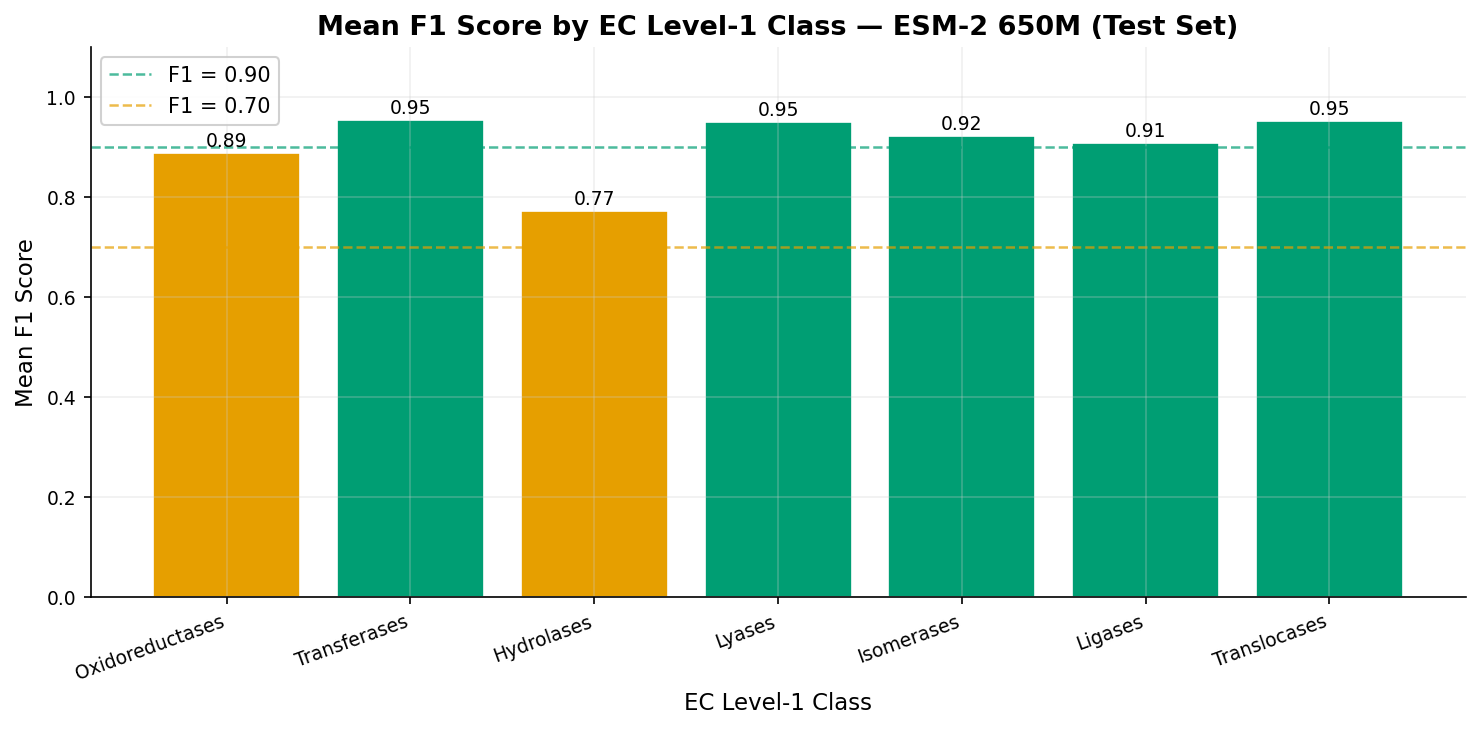

In [ ]:
ec1_summary = df_f1.groupby(["EC_level1","EC1_Name"])["F1"].mean().reset_index()
ec1_summary = ec1_summary.sort_values("EC_level1")

bar_colors = [
    COLORS["green"]  if f >= 0.90 else
    COLORS["orange"] if f >= 0.70 else
    COLORS["red"]
    for f in ec1_summary["F1"]
]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(ec1_summary["EC1_Name"], ec1_summary["F1"],
              color=bar_colors, edgecolor="white", linewidth=0.8)

for bar, val in zip(bars, ec1_summary["F1"]):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.005,
            f"{val:.2f}", ha="center", va="bottom", fontsize=9)

ax.axhline(0.90, color=COLORS["green"],  linestyle="--",
           linewidth=1.2, alpha=0.7, label="F1 = 0.90")
ax.axhline(0.70, color=COLORS["orange"], linestyle="--",
           linewidth=1.2, alpha=0.7, label="F1 = 0.70")
ax.set_ylim(0, 1.1)
ax.set_xlabel("EC Level-1 Class")
ax.set_ylabel("Mean F1 Score")
ax.set_title("Mean F1 Score by EC Level-1 Class — ESM-2 650M (Test Set)")
plt.xticks(rotation=20, ha="right")
ax.legend()
plt.tight_layout()
plt.savefig(f"{PROJECT}/bio_ec1_mean_f1.png", dpi=150, bbox_inches="tight")
plt.show()

**Per EC Level-2 sub-class F1 grouped by EC Level-1**

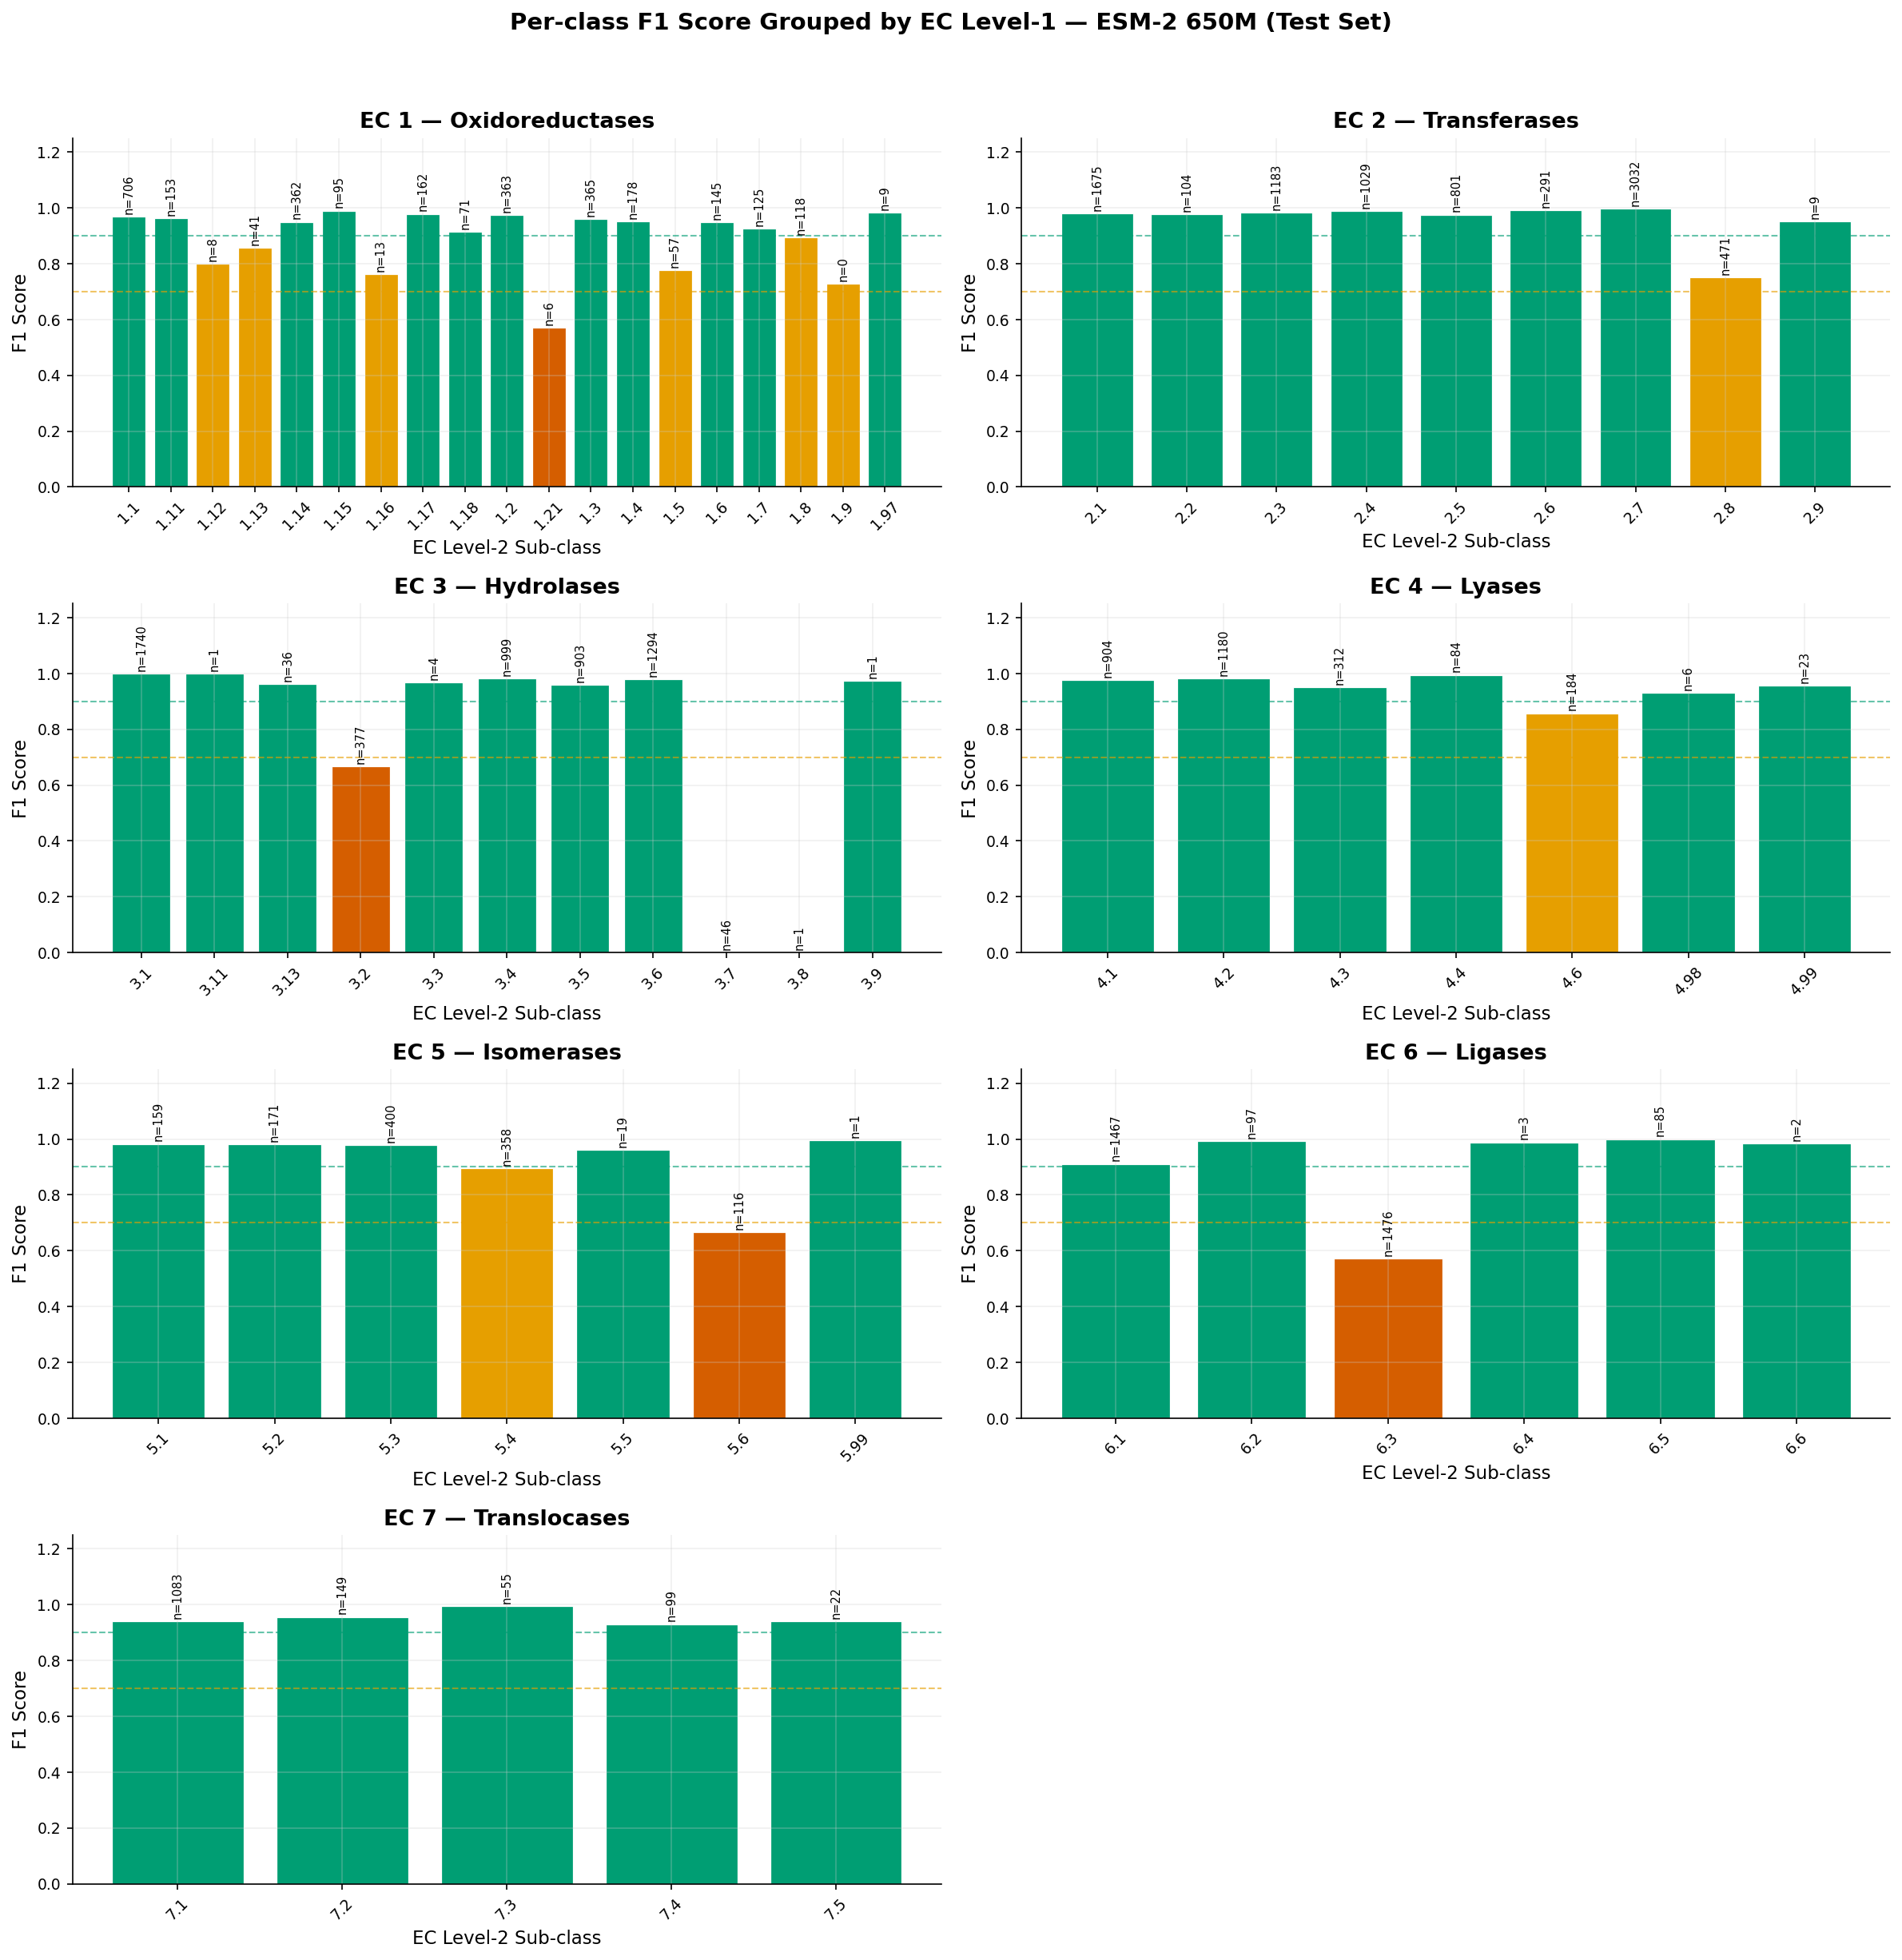

In [ ]:
# One subplot per EC1 class
ec1_list = sorted(df_f1["EC_level1"].unique())
n_cols   = 2
n_rows   = (len(ec1_list) + 1) // 2

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
axes = axes.flatten()

for idx, ec1 in enumerate(ec1_list):
    ax   = axes[idx]
    data = df_f1[df_f1["EC_level1"] == ec1].sort_values("EC_level2")
    name = ec1_names.get(ec1, f"EC {ec1}")

    bar_colors = [
        COLORS["green"]  if f >= 0.90 else
        COLORS["orange"] if f >= 0.70 else
        COLORS["red"]
        for f in data["F1"]
    ]

    bars = ax.bar(data["EC_level2"], data["F1"],
                  color=bar_colors, edgecolor="white", linewidth=0.6)

    # Support count on each bar so rare classes are immediately visible
    for bar, (_, row) in zip(bars, data.iterrows()):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.01,
                f"n={row['Support']}", ha="center", va="bottom",
                fontsize=7, rotation=90)

    ax.axhline(0.90, color=COLORS["green"],  linestyle="--",
               linewidth=1.0, alpha=0.6)
    ax.axhline(0.70, color=COLORS["orange"], linestyle="--",
               linewidth=1.0, alpha=0.6)
    ax.set_title(f"EC {ec1} — {name}")
    ax.set_xlabel("EC Level-2 Sub-class")
    ax.set_ylabel("F1 Score")
    ax.set_ylim(0, 1.25)
    ax.tick_params(axis="x", rotation=45)

for idx in range(len(ec1_list), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle("Per-class F1 Score Grouped by EC Level-1 — ESM-2 650M (Test Set)",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(f"{PROJECT}/bio_ec1_grouped_f1.png", dpi=150, bbox_inches="tight")
plt.show()

**EC Level-1 confusion heatmap**

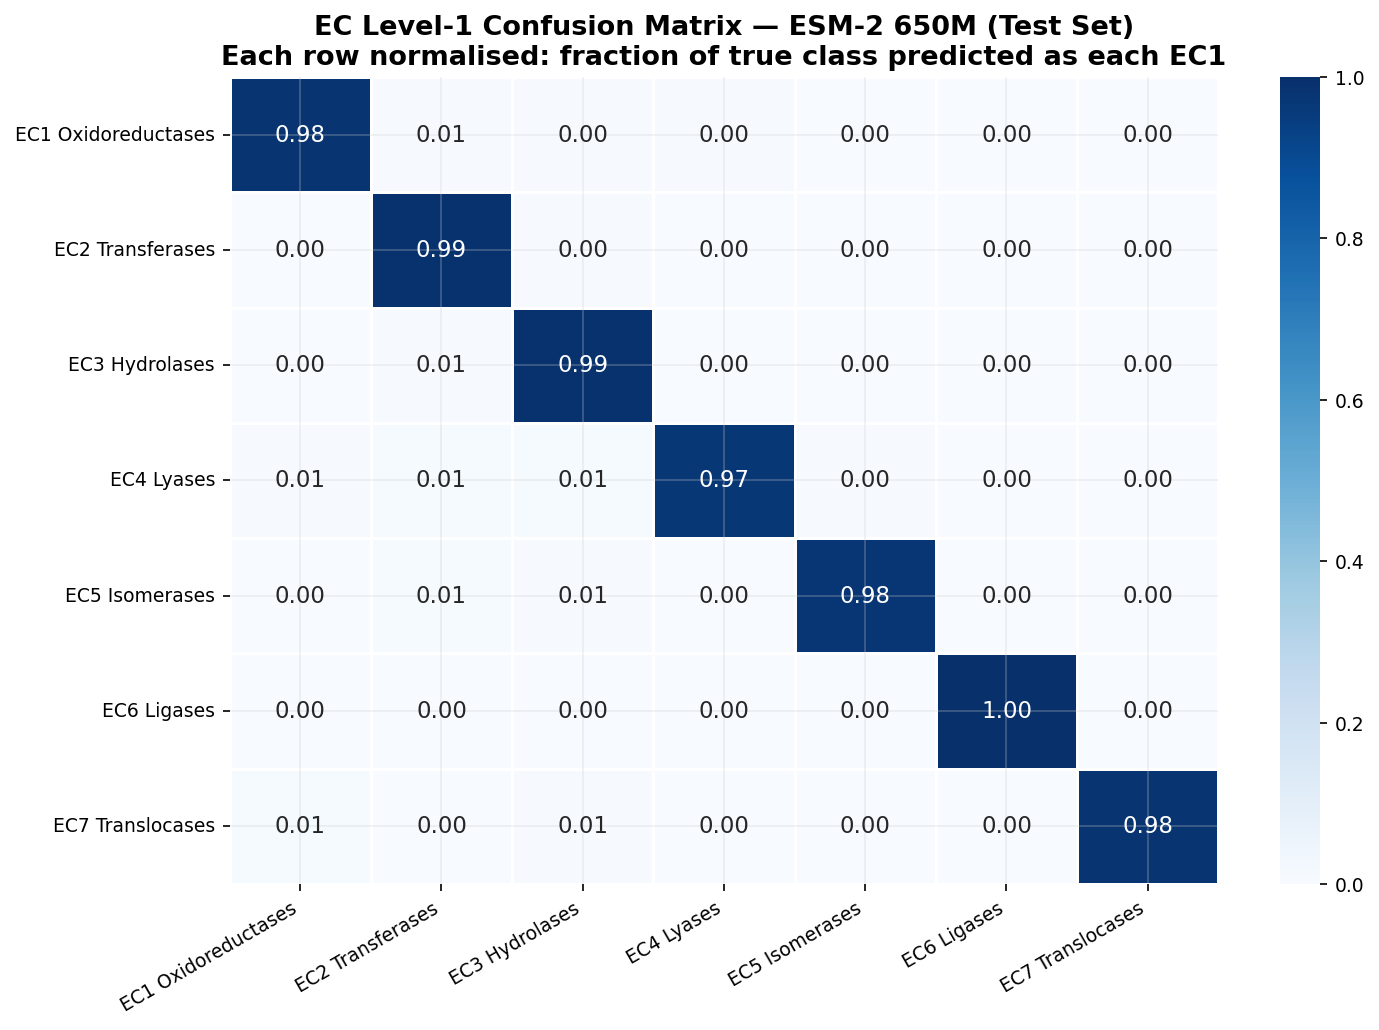

In [ ]:
# Shows whether misclassifications cross EC1 boundaries or stay within the same class

pred_ec1 = pd.Series([str(int_to_ec2[p]).split(".")[0] for p in y_pred])
true_ec1 = df_test["EC_level2"].astype(str).str.split(".").str[0].values

ec1_conf = pd.crosstab(
    true_ec1, pred_ec1,
    rownames=["True EC1"],
    colnames=["Predicted EC1"],
    normalize="index"
)

ec1_conf.index   = [f"EC{i} {ec1_names.get(i,'')}" for i in ec1_conf.index]
ec1_conf.columns = [f"EC{i} {ec1_names.get(i,'')}" for i in ec1_conf.columns]

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(
    ec1_conf,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    linewidths=0.5,
    vmin=0, vmax=1,
    ax=ax
)
ax.set_title("EC Level-1 Confusion Matrix — ESM-2 650M (Test Set)\n"
             "Each row normalised: fraction of true class predicted as each EC1")
plt.xticks(rotation=30, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(f"{PROJECT}/bio_ec1_confusion_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

**F1 vs support scatter**

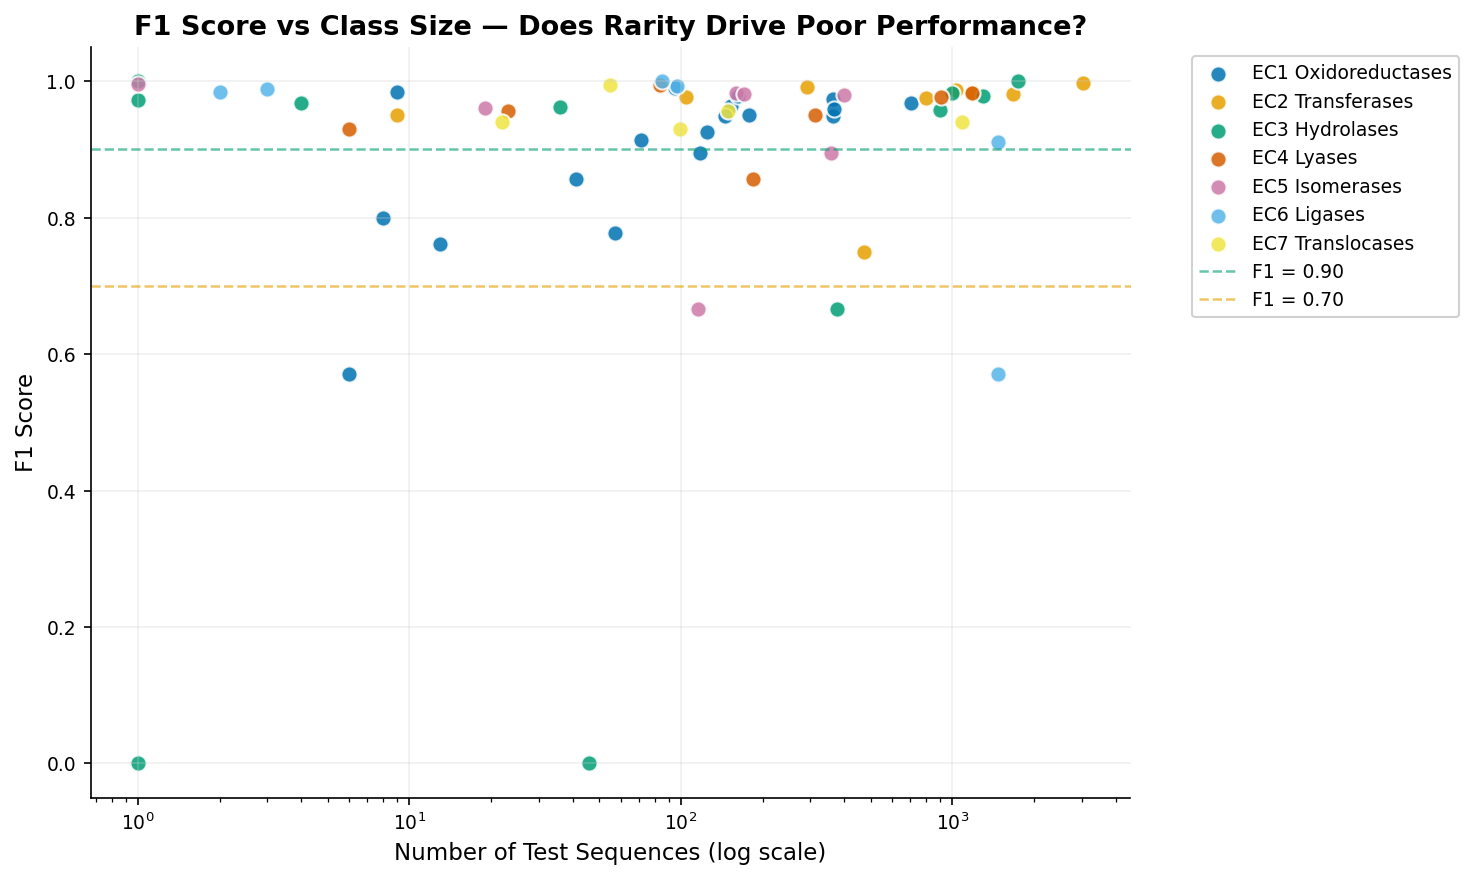

Pearson correlation between class size and F1: 0.147


In [ ]:
# Answers the key question: is poor performance caused by data scarcity
# or genuine biochemical ambiguity between sub-classes?

color_list = [COLORS["blue"], COLORS["orange"], COLORS["green"],
              COLORS["red"], COLORS["purple"], COLORS["sky"], COLORS["yellow"]]

fig, ax = plt.subplots(figsize=(10, 6))

for idx, ec1 in enumerate(sorted(df_f1["EC_level1"].unique())):
    data  = df_f1[df_f1["EC_level1"] == ec1]
    color = color_list[idx % len(color_list)]
    ax.scatter(data["Support"], data["F1"],
               label=f"EC{ec1} {ec1_names[ec1]}",
               color=color, s=60, alpha=0.85, edgecolors="white")

ax.axhline(0.90, color=COLORS["green"],  linestyle="--",
           linewidth=1.2, alpha=0.6, label="F1 = 0.90")
ax.axhline(0.70, color=COLORS["orange"], linestyle="--",
           linewidth=1.2, alpha=0.6, label="F1 = 0.70")

# Log scale because support spans from single digits to thousands
ax.set_xscale("log")
ax.set_xlabel("Number of Test Sequences (log scale)")
ax.set_ylabel("F1 Score")
ax.set_title("F1 Score vs Class Size — Does Rarity Drive Poor Performance?")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=9)
plt.tight_layout()
plt.savefig(f"{PROJECT}/bio_f1_vs_support.png", dpi=150, bbox_inches="tight")
plt.show()

corr = df_f1[["Support", "F1"]].corr().iloc[0, 1]
print(f"Pearson correlation between class size and F1: {corr:.3f}")

**Biological summary printout**

In [ ]:
for ec1 in sorted(df_f1["EC_level1"].unique()):
    data  = df_f1[df_f1["EC_level1"] == ec1].sort_values("F1")
    name  = ec1_names.get(ec1, f"EC {ec1}")
    mean  = data["F1"].mean()
    worst = data.nsmallest(3, "F1")[["EC_level2", "F1", "Support"]]
    best  = data.nlargest(3,  "F1")[["EC_level2", "F1", "Support"]]

    print(f"\nEC {ec1} — {name}")
    print(f"  Sub-classes in test: {len(data)}   Mean F1: {mean:.3f}")
    print(f"  Best sub-classes:")
    for _, row in best.iterrows():
        print(f"    EC {row['EC_level2']:>6}   F1 = {row['F1']:.3f}   n = {row['Support']}")
    print(f"  Worst sub-classes:")
    for _, row in worst.iterrows():
        print(f"    EC {row['EC_level2']:>6}   F1 = {row['F1']:.3f}   n = {row['Support']}")


EC 1 — Oxidoreductases
  Sub-classes in test: 19   Mean F1: 0.889
  Best sub-classes:
    EC   1.15   F1 = 0.990   n = 95
    EC   1.97   F1 = 0.983   n = 9
    EC   1.17   F1 = 0.978   n = 162
  Worst sub-classes:
    EC   1.21   F1 = 0.571   n = 6
    EC    1.9   F1 = 0.727   n = 0
    EC   1.16   F1 = 0.762   n = 13

EC 2 — Transferases
  Sub-classes in test: 9   Mean F1: 0.955
  Best sub-classes:
    EC    2.7   F1 = 0.998   n = 3032
    EC    2.6   F1 = 0.992   n = 291
    EC    2.4   F1 = 0.987   n = 1029
  Worst sub-classes:
    EC    2.8   F1 = 0.750   n = 471
    EC    2.9   F1 = 0.950   n = 9
    EC    2.5   F1 = 0.976   n = 801

EC 3 — Hydrolases
  Sub-classes in test: 11   Mean F1: 0.772
  Best sub-classes:
    EC    3.1   F1 = 1.000   n = 1740
    EC   3.11   F1 = 1.000   n = 1
    EC    3.4   F1 = 0.983   n = 999
  Worst sub-classes:
    EC    3.8   F1 = 0.000   n = 1
    EC    3.7   F1 = 0.000   n = 46
    EC    3.2   F1 = 0.667   n = 377

EC 4 — Lyases
  Sub-classes in

**Part I**

**CNN Ablation Studies**

**Encode sequences**

In [ ]:
AMINO_ACIDS = "ACDEFGHIKLMNPQRSTVWY"
MAX_LEN     = 512
aa_to_int   = {aa: idx + 1 for idx, aa in enumerate(AMINO_ACIDS)}

def encode_sequence(sequence):
    return [aa_to_int.get(aa, 0) for aa in sequence]

def encode_and_pad(sequences, max_len):
    encoded = [encode_sequence(seq) for seq in sequences]
    return keras.preprocessing.sequence.pad_sequences(
        encoded, maxlen=max_len,
        padding="post", truncating="post", value=0
    )

print("Encoding sequences")
X_train = encode_and_pad(df_train["Sequence"].tolist(), MAX_LEN)
X_val   = encode_and_pad(df_val["Sequence"].tolist(),   MAX_LEN)
X_test  = encode_and_pad(df_test["Sequence"].tolist(),  MAX_LEN)

print(f"Train shape: {X_train.shape}")
print(f"Val shape:   {X_val.shape}")
print(f"Test shape:  {X_test.shape}")

Encoding sequences
Train shape: (196472, 512)
Val shape:   (24363, 512)
Test shape:  (25496, 512)


**Full CNN (the baseline we are ablating from)**

In [ ]:
def build_cnn_full(vocab_size, max_len, num_classes, embed_dim=64):
    """
    Full CNN — three conv blocks with BatchNorm and Dropout.
    This is the baseline. Every ablation removes exactly one component
    so we can measure how much that component contributes.
    """
    inputs = keras.Input(shape=(max_len,))

    x = layers.Embedding(
        input_dim=vocab_size + 1,
        output_dim=embed_dim,
        mask_zero=True
    )(inputs)

    x = layers.Conv1D(128, kernel_size=3,  activation="relu", padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.2)(x)

    x = layers.Conv1D(256, kernel_size=7,  activation="relu", padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.2)(x)

    x = layers.Conv1D(128, kernel_size=15, activation="relu", padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.2)(x)

    x = layers.GlobalMaxPooling1D()(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.3)(x)

    outputs = layers.Dense(num_classes, activation="softmax")(x)
    return keras.Model(inputs=inputs, outputs=outputs)

**Ablation 1: No BatchNorm**

In [ ]:
def build_cnn_no_batchnorm(vocab_size, max_len, num_classes, embed_dim=64):
    """
    Removes BatchNormalization from all three conv blocks.
    BatchNorm stabilises training by keeping activations in a healthy range —
    without it we expect slower convergence and potentially lower final accuracy.
    """
    inputs = keras.Input(shape=(max_len,))

    x = layers.Embedding(
        input_dim=vocab_size + 1,
        output_dim=embed_dim,
        mask_zero=True
    )(inputs)

    x = layers.Conv1D(128, kernel_size=3,  activation="relu", padding="same")(x)
    x = layers.Dropout(0.2)(x)

    x = layers.Conv1D(256, kernel_size=7,  activation="relu", padding="same")(x)
    x = layers.Dropout(0.2)(x)

    x = layers.Conv1D(128, kernel_size=15, activation="relu", padding="same")(x)
    x = layers.Dropout(0.2)(x)

    x = layers.GlobalMaxPooling1D()(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.3)(x)

    outputs = layers.Dense(num_classes, activation="softmax")(x)
    return keras.Model(inputs=inputs, outputs=outputs)

**Ablation 2: No Dropout**

In [ ]:
def build_cnn_no_dropout(vocab_size, max_len, num_classes, embed_dim=64):
    """
    Removes all Dropout layers.
    Dropout randomly switches off neurons during training to prevent
    the model from memorising the training data — without it we expect overfitting,
    visible as a growing gap between train and val accuracy.
    """
    inputs = keras.Input(shape=(max_len,))

    x = layers.Embedding(
        input_dim=vocab_size + 1,
        output_dim=embed_dim,
        mask_zero=True
    )(inputs)

    x = layers.Conv1D(128, kernel_size=3,  activation="relu", padding="same")(x)
    x = layers.BatchNormalization()(x)

    x = layers.Conv1D(256, kernel_size=7,  activation="relu", padding="same")(x)
    x = layers.BatchNormalization()(x)

    x = layers.Conv1D(128, kernel_size=15, activation="relu", padding="same")(x)
    x = layers.BatchNormalization()(x)

    x = layers.GlobalMaxPooling1D()(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dense(128, activation="relu")(x)

    outputs = layers.Dense(num_classes, activation="softmax")(x)
    return keras.Model(inputs=inputs, outputs=outputs)

**Ablation 3: No third conv block**

In [ ]:
def build_cnn_two_blocks(vocab_size, max_len, num_classes, embed_dim=64):
    """
    Removes the third conv block (kernel size 15).
    The kernel-15 block detects longer sequence motifs — domain-level signals
    spanning 15 amino acids. Removing it tests whether long-range detection
    meaningfully contributes beyond the short (3) and medium (7) range blocks.
    """
    inputs = keras.Input(shape=(max_len,))

    x = layers.Embedding(
        input_dim=vocab_size + 1,
        output_dim=embed_dim,
        mask_zero=True
    )(inputs)

    x = layers.Conv1D(128, kernel_size=3, activation="relu", padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.2)(x)

    x = layers.Conv1D(256, kernel_size=7, activation="relu", padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.2)(x)

    x = layers.GlobalMaxPooling1D()(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.3)(x)

    outputs = layers.Dense(num_classes, activation="softmax")(x)
    return keras.Model(inputs=inputs, outputs=outputs)

**Ablation 4: Single conv block**

In [ ]:
def build_cnn_one_block(vocab_size, max_len, num_classes, embed_dim=64):
    """
    Keeps only the first conv block (kernel size 3).
    This is the minimum viable CNN — just short motif detection.
    Shows the combined contribution of the medium and long range blocks.
    """
    inputs = keras.Input(shape=(max_len,))

    x = layers.Embedding(
        input_dim=vocab_size + 1,
        output_dim=embed_dim,
        mask_zero=True
    )(inputs)

    x = layers.Conv1D(128, kernel_size=3, activation="relu", padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.2)(x)

    x = layers.GlobalMaxPooling1D()(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.3)(x)

    outputs = layers.Dense(num_classes, activation="softmax")(x)
    return keras.Model(inputs=inputs, outputs=outputs)

**Train all four ablated models**

In [ ]:
NUM_CLASSES = df_train["EC_level2_encoded"].nunique()

def get_callbacks(name):
    return [
        keras.callbacks.ModelCheckpoint(
            filepath       = f"{PROJECT}/ablation_{name}_best.keras",
            monitor        = "val_accuracy",
            save_best_only = True,
            verbose        = 0
        ),
        keras.callbacks.EarlyStopping(
            monitor              = "val_accuracy",
            patience             = 7,
            verbose              = 1,
            restore_best_weights = True
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor  = "val_accuracy",
            factor   = 0.5,
            patience = 3,
            verbose  = 0
        )
    ]

ablations = {
    "Full CNN":        build_cnn_full,
    "No BatchNorm":    build_cnn_no_batchnorm,
    "No Dropout":      build_cnn_no_dropout,
    "Two Conv Blocks": build_cnn_two_blocks,
    "One Conv Block":  build_cnn_one_block,
}

histories   = {}
test_scores = {}

for name, build_fn in ablations.items():
    print(f"\nTraining: {name}")
    model = build_fn(len(AMINO_ACIDS), MAX_LEN, NUM_CLASSES)
    model.compile(
        optimizer = keras.optimizers.Adam(learning_rate=1e-3),
        loss      = "sparse_categorical_crossentropy",
        metrics   = ["accuracy"]
    )
    history = model.fit(
        X_train, y_train,
        validation_data = (X_val, y_val),
        epochs          = 30,
        batch_size      = 256,
        callbacks       = get_callbacks(name.replace(" ", "_")),
        verbose         = 1
    )
    y_pred = np.argmax(model.predict(X_test), axis=1)
    histories[name]   = history
    test_scores[name] = (y_pred == y_test).mean()
    print(f"  Test accuracy: {test_scores[name]:.1%}")


Training: Full CNN


/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'conv1d' (of type Conv1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


Epoch 1/30
768/768 ━━━━━━━━━━━━━━━━━━━━ 51s 42ms/step - accuracy: 0.2163 - loss: 2.9920 - val_accuracy: 0.4415 - val_loss: 2.2141 - learning_rate: 0.0010
Epoch 2/30
768/768 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.5615 - loss: 1.6541 - val_accuracy: 0.6872 - val_loss: 1.2358 - learning_rate: 0.0010
Epoch 3/30
768/768 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.6989 - loss: 1.1415 - val_accuracy: 0.7429 - val_loss: 1.0148 - learning_rate: 0.0010
Epoch 4/30
768/768 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.7558 - loss: 0.9281 - val_accuracy: 0.7867 - val_loss: 0.8434 - learning_rate: 0.0010
Epoch 5/30
768/768 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.7914 - loss: 0.7944 - val_accuracy: 0.8126 - val_loss: 0.7757 - learning_rate: 0.0010
Epoch 6/30
768/768 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.8130 - loss: 0.7121 - val_accuracy: 0.8299 - val_loss: 0.6849 - learning_rate: 0.0010
Epoch 7/30
768/768 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.8304 - l

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'conv1d_3' (of type Conv1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


Epoch 1/30
768/768 ━━━━━━━━━━━━━━━━━━━━ 22s 20ms/step - accuracy: 0.1952 - loss: 3.0475 - val_accuracy: 0.4208 - val_loss: 2.2209 - learning_rate: 0.0010
Epoch 2/30
768/768 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.5853 - loss: 1.5603 - val_accuracy: 0.6936 - val_loss: 1.2310 - learning_rate: 0.0010
Epoch 3/30
768/768 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.7291 - loss: 1.0303 - val_accuracy: 0.7789 - val_loss: 0.9285 - learning_rate: 0.0010
Epoch 4/30
768/768 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.7850 - loss: 0.8211 - val_accuracy: 0.8000 - val_loss: 0.8039 - learning_rate: 0.0010
Epoch 5/30
768/768 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.8147 - loss: 0.7075 - val_accuracy: 0.8205 - val_loss: 0.7332 - learning_rate: 0.0010
Epoch 6/30
768/768 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.8370 - loss: 0.6294 - val_accuracy: 0.8393 - val_loss: 0.6450 - learning_rate: 0.0010
Epoch 7/30
768/768 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.8505 - loss: 

...

Epoch 1/30
768/768 ━━━━━━━━━━━━━━━━━━━━ 39s 34ms/step - accuracy: 0.6489 - loss: 1.4180 - val_accuracy: 0.7659 - val_loss: 0.9808 - learning_rate: 0.0010
Epoch 2/30
768/768 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.8963 - loss: 0.4207 - val_accuracy: 0.8125 - val_loss: 0.8444 - learning_rate: 0.0010
Epoch 3/30
768/768 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.9349 - loss: 0.2541 - val_accuracy: 0.8321 - val_loss: 0.7445 - learning_rate: 0.0010
Epoch 4/30
768/768 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.9523 - loss: 0.1784 - val_accuracy: 0.8588 - val_loss: 0.6692 - learning_rate: 0.0010
Epoch 5/30
768/768 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.9634 - loss: 0.1327 - val_accuracy: 0.8543 - val_loss: 0.7873 - learning_rate: 0.0010
Epoch 6/30
768/768 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.9692 - loss: 0.1081 - val_accuracy: 0.8561 - val_loss: 0.7909 - learning_rate: 0.0010
Epoch 7/30
768/768 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.9743 - l

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'conv1d_9' (of type Conv1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


Epoch 1/30
768/768 ━━━━━━━━━━━━━━━━━━━━ 26s 20ms/step - accuracy: 0.1728 - loss: 3.1695 - val_accuracy: 0.2782 - val_loss: 2.7282 - learning_rate: 0.0010
Epoch 2/30
768/768 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.3870 - loss: 2.2748 - val_accuracy: 0.5097 - val_loss: 1.9436 - learning_rate: 0.0010
Epoch 3/30
768/768 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.4915 - loss: 1.8746 - val_accuracy: 0.5917 - val_loss: 1.6600 - learning_rate: 0.0010
Epoch 4/30
768/768 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.5520 - loss: 1.6454 - val_accuracy: 0.6410 - val_loss: 1.4621 - learning_rate: 0.0010
Epoch 5/30
768/768 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.5951 - loss: 1.4927 - val_accuracy: 0.6673 - val_loss: 1.3580 - learning_rate: 0.0010
Epoch 6/30
768/768 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.6238 - loss: 1.3929 - val_accuracy: 0.6907 - val_loss: 1.2470 - learning_rate: 0.0010
Epoch 7/30
768/768 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.6458 - loss: 1.3120 

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'conv1d_11' (of type Conv1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


Epoch 1/30
768/768 ━━━━━━━━━━━━━━━━━━━━ 20s 15ms/step - accuracy: 0.1771 - loss: 3.1330 - val_accuracy: 0.2597 - val_loss: 2.9572 - learning_rate: 0.0010
Epoch 2/30
768/768 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.2991 - loss: 2.6242 - val_accuracy: 0.3408 - val_loss: 2.5675 - learning_rate: 0.0010
Epoch 3/30
768/768 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.3629 - loss: 2.3907 - val_accuracy: 0.3836 - val_loss: 2.4187 - learning_rate: 0.0010
Epoch 4/30
768/768 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.3970 - loss: 2.2596 - val_accuracy: 0.3956 - val_loss: 2.3183 - learning_rate: 0.0010
Epoch 5/30
768/768 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.4217 - loss: 2.1685 - val_accuracy: 0.4220 - val_loss: 2.2336 - learning_rate: 0.0010
Epoch 6/30
768/768 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.4404 - loss: 2.1009 - val_accuracy: 0.4220 - val_loss: 2.2327 - learning_rate: 0.0010
Epoch 7/30
768/768 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.4548 - loss: 2.0435 

**Plot training curves for all ablations**

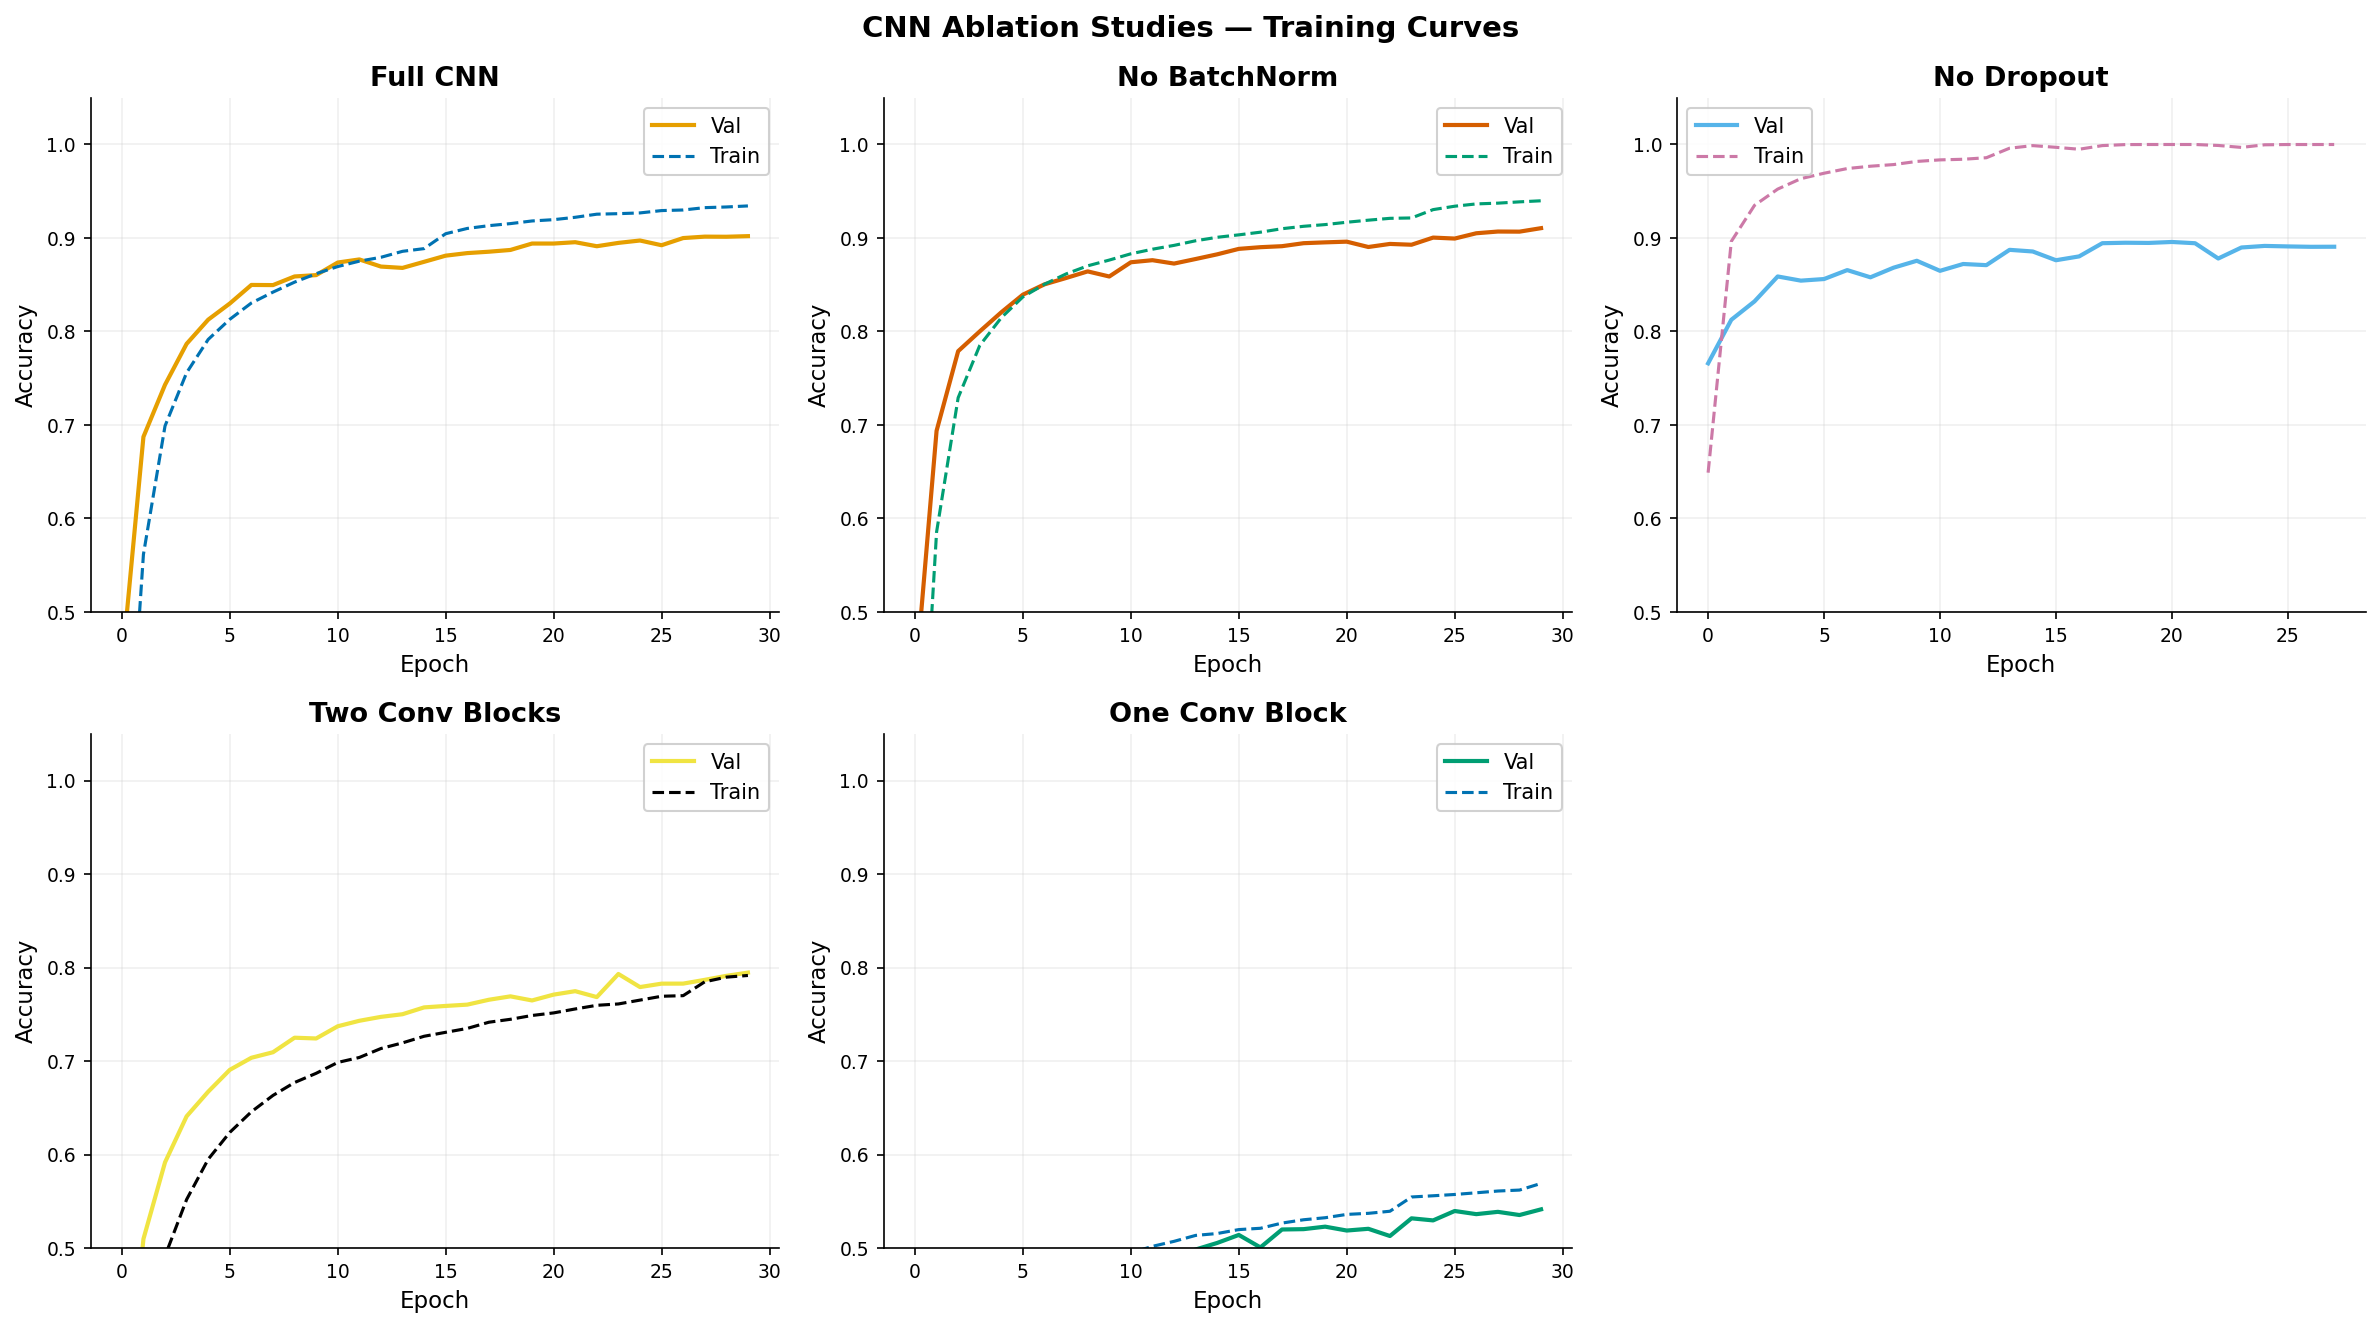

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

color_pairs = [
    (COLORS["blue"],   COLORS["orange"]),
    (COLORS["green"],  COLORS["red"]),
    (COLORS["purple"], COLORS["sky"]),
    (COLORS["black"],  COLORS["yellow"]),
    (COLORS["blue"],   COLORS["green"]),
]

for idx, (name, history) in enumerate(histories.items()):
    ax     = axes[idx]
    train_c, val_c = color_pairs[idx]
    ax.plot(history.history["val_accuracy"],
            color=val_c, label="Val", linewidth=2)
    ax.plot(history.history["accuracy"],
            color=train_c, label="Train", linestyle="--", linewidth=1.5)
    ax.set_title(name)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy")
    ax.set_ylim(0.5, 1.05)
    ax.legend()

# Hide the unused sixth subplot
axes[5].set_visible(False)

plt.suptitle("CNN Ablation Studies — Training Curves", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{PROJECT}/ablation_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

**Final comparison bar chart**

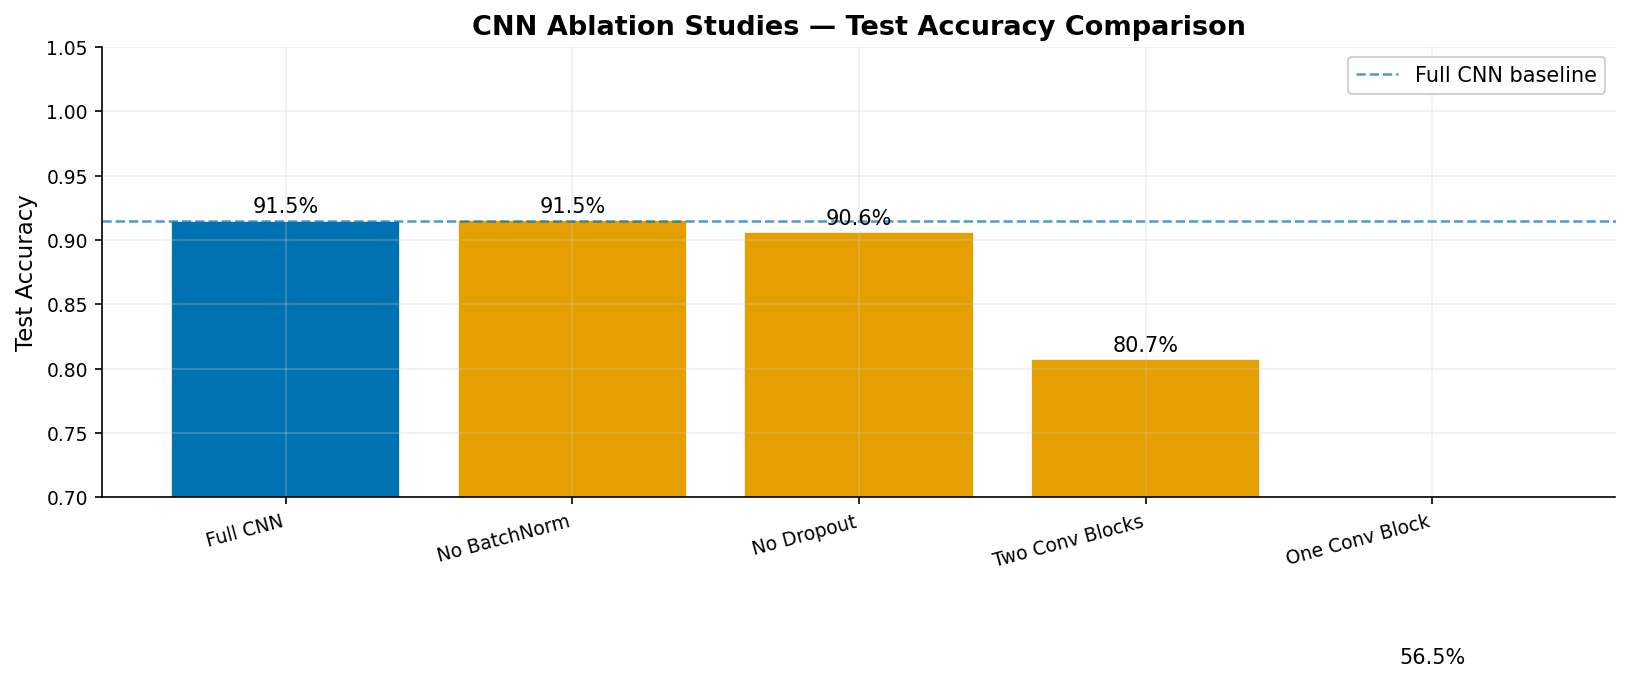

In [ ]:
names  = list(test_scores.keys())
scores = list(test_scores.values())

bar_colors = [
    COLORS["blue"] if n == "Full CNN" else COLORS["orange"]
    for n in names
]

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(names, scores, color=bar_colors, edgecolor="white", linewidth=0.8)

for bar, val in zip(bars, scores):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.003,
            f"{val:.1%}", ha="center", va="bottom", fontsize=10)

# Reference line showing full model performance
ax.axhline(test_scores["Full CNN"], color=COLORS["blue"],
           linestyle="--", linewidth=1.2, alpha=0.7, label="Full CNN baseline")
ax.set_ylim(0.7, 1.05)
ax.set_ylabel("Test Accuracy")
ax.set_title("CNN Ablation Studies — Test Accuracy Comparison")
ax.legend()
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.savefig(f"{PROJECT}/ablation_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

**Results table**

In [ ]:
baseline = test_scores["Full CNN"]

print(f"\n{'Model':<22} {'Test Acc':>10} {'Drop vs Full':>14}")
for name, score in test_scores.items():
    drop = score - baseline
    marker = "" if name == "Full CNN" else f"{drop:+.1%}"
    print(f"{name:<22} {score:>10.1%} {marker:>14}")


Model                    Test Acc   Drop vs Full
Full CNN                    91.5%               
No BatchNorm                91.5%          +0.0%
No Dropout                  90.6%          -0.9%
Two Conv Blocks             80.7%         -10.8%
One Conv Block              56.5%         -35.0%


**Part J**

**Class Imbalance Experiments**

**Look at the imbalance before doing anything**

Largest class:  22,946 training sequences
Smallest class: 19 training sequences
Ratio:          1208x imbalance


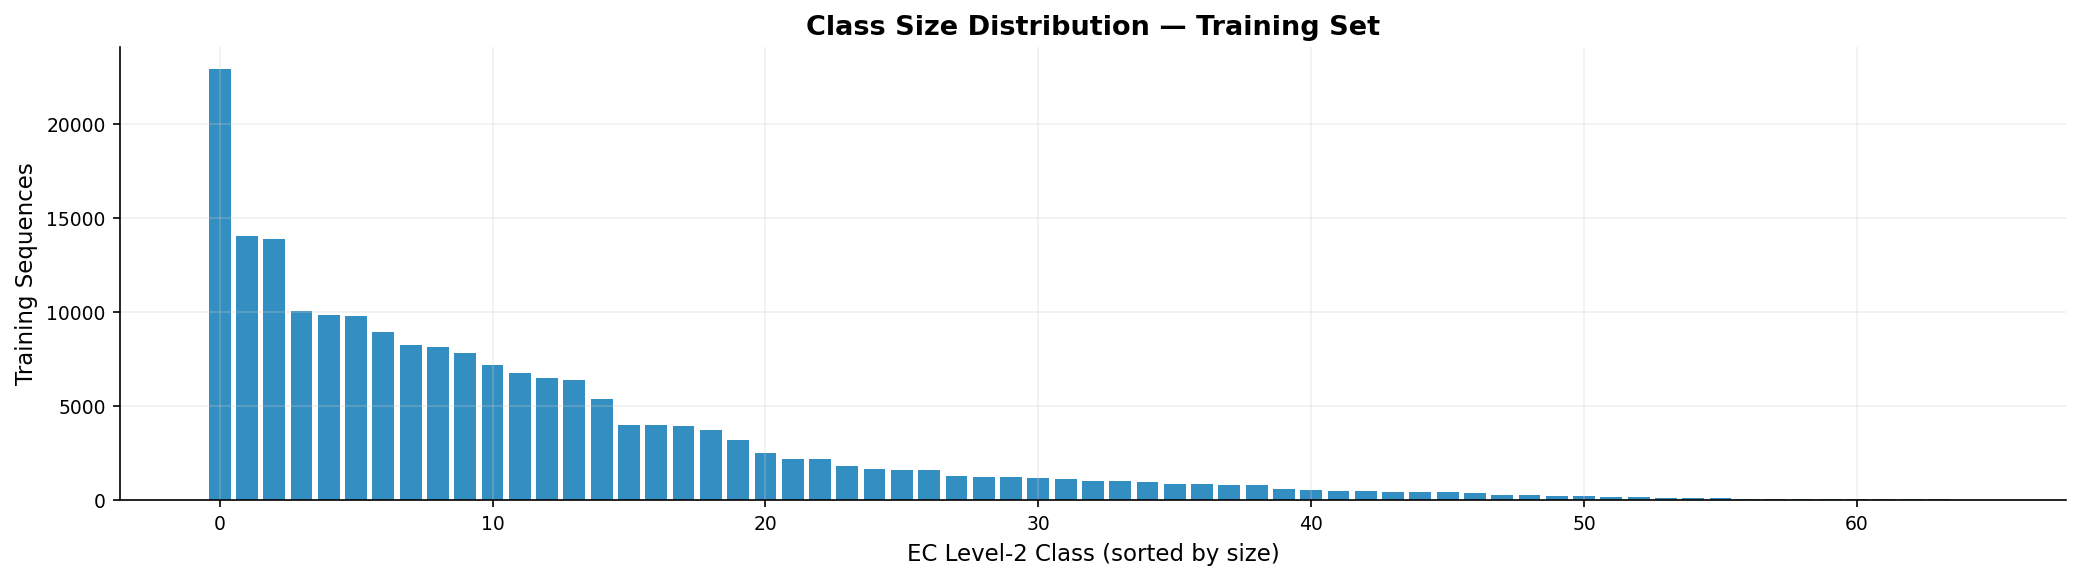

In [ ]:
# Understanding the imbalance is essential before deciding how to address it
class_counts = df_train["EC_level2_encoded"].value_counts().sort_index()

print(f"Largest class:  {class_counts.max():,} training sequences")
print(f"Smallest class: {class_counts.min():,} training sequences")
print(f"Ratio:          {class_counts.max() / class_counts.min():.0f}x imbalance")

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(range(len(class_counts)), sorted(class_counts.values, reverse=True),
       color=COLORS["blue"], alpha=0.8)
ax.set_xlabel("EC Level-2 Class (sorted by size)")
ax.set_ylabel("Training Sequences")
ax.set_title("Class Size Distribution — Training Set")
plt.tight_layout()
plt.savefig(f"{PROJECT}/imbalance_class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

**Encode sequences**

In [ ]:
AMINO_ACIDS = "ACDEFGHIKLMNPQRSTVWY"
MAX_LEN     = 512
aa_to_int   = {aa: idx + 1 for idx, aa in enumerate(AMINO_ACIDS)}

def encode_sequence(sequence):
    return [aa_to_int.get(aa, 0) for aa in sequence]

def encode_and_pad(sequences, max_len):
    encoded = [encode_sequence(seq) for seq in sequences]
    return keras.preprocessing.sequence.pad_sequences(
        encoded, maxlen=max_len,
        padding="post", truncating="post", value=0
    )

print("Encoding sequences")
X_train = encode_and_pad(df_train["Sequence"].tolist(), MAX_LEN)
X_val   = encode_and_pad(df_val["Sequence"].tolist(),   MAX_LEN)
X_test  = encode_and_pad(df_test["Sequence"].tolist(),  MAX_LEN)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

Encoding sequences
Train: (196472, 512), Val: (24363, 512), Test: (25496, 512)


**Compute class weights**

In [ ]:
from sklearn.utils.class_weight import compute_class_weight

# Class weights make the loss function penalise mistakes on rare classes more heavily
# so the model pays more attention to them during training
class_weights_array = compute_class_weight(
    class_weight = "balanced",
    classes      = np.arange(NUM_CLASSES),
    y            = y_train
)

# Keras expects a dictionary {class_index: weight}
class_weight_dict = {i: w for i, w in enumerate(class_weights_array)}

print(f"Smallest weight (largest class): {min(class_weights_array):.4f}")
print(f"Largest weight (smallest class): {max(class_weights_array):.4f}")
print(f"Weight ratio: {max(class_weights_array) / min(class_weights_array):.0f}x")

Smallest weight (largest class): 0.1317
Largest weight (smallest class): 159.0866
Weight ratio: 1208x


**CNN architecture**

In [ ]:
def build_cnn(vocab_size, max_len, num_classes, embed_dim=64):
    """
    Same three-block CNN as notebook 5.
    We keep the architecture identical so the only variable
    between experiments is how we handle class imbalance.
    """
    inputs = keras.Input(shape=(max_len,))

    x = layers.Embedding(
        input_dim  = vocab_size + 1,
        output_dim = embed_dim,
        mask_zero  = True
    )(inputs)

    x = layers.Conv1D(128, kernel_size=3,  activation="relu", padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.2)(x)

    x = layers.Conv1D(256, kernel_size=7,  activation="relu", padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.2)(x)

    x = layers.Conv1D(128, kernel_size=15, activation="relu", padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.2)(x)

    x = layers.GlobalMaxPooling1D()(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.3)(x)

    outputs = layers.Dense(num_classes, activation="softmax")(x)
    return keras.Model(inputs=inputs, outputs=outputs)

**Experiment A: CNN without class weights (baseline)**

In [ ]:
def get_callbacks(name):
    return [
        keras.callbacks.ModelCheckpoint(
            filepath       = f"{PROJECT}/imbalance_{name}_best.keras",
            monitor        = "val_accuracy",
            save_best_only = True,
            verbose        = 0
        ),
        keras.callbacks.EarlyStopping(
            monitor              = "val_accuracy",
            patience             = 7,
            verbose              = 1,
            restore_best_weights = True
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor  = "val_accuracy",
            factor   = 0.5,
            patience = 3,
            verbose  = 0
        )
    ]

print("Training CNN — no class weights (baseline)...")
cnn_baseline = build_cnn(len(AMINO_ACIDS), MAX_LEN, NUM_CLASSES)
cnn_baseline.compile(
    optimizer = keras.optimizers.Adam(learning_rate=1e-3),
    loss      = "sparse_categorical_crossentropy",
    metrics   = ["accuracy"]
)
history_baseline = cnn_baseline.fit(
    X_train, y_train,
    validation_data = (X_val, y_val),
    epochs          = 30,
    batch_size      = 256,
    callbacks       = get_callbacks("baseline"),
    verbose         = 1
)

y_pred_baseline = np.argmax(cnn_baseline.predict(X_test), axis=1)
print(f"\nBaseline test accuracy: {(y_pred_baseline == y_test).mean():.1%}")
print(classification_report(y_test, y_pred_baseline, zero_division=0))

Training CNN — no class weights (baseline)...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'conv1d' (of type Conv1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


Epoch 1/30
768/768 ━━━━━━━━━━━━━━━━━━━━ 130s 150ms/step - accuracy: 0.2380 - loss: 2.9029 - val_accuracy: 0.4830 - val_loss: 2.0745 - learning_rate: 0.0010
Epoch 2/30
768/768 ━━━━━━━━━━━━━━━━━━━━ 107s 139ms/step - accuracy: 0.5858 - loss: 1.5636 - val_accuracy: 0.7018 - val_loss: 1.1862 - learning_rate: 0.0010
Epoch 3/30
768/768 ━━━━━━━━━━━━━━━━━━━━ 107s 139ms/step - accuracy: 0.7026 - loss: 1.1228 - val_accuracy: 0.7672 - val_loss: 0.9525 - learning_rate: 0.0010
Epoch 4/30
768/768 ━━━━━━━━━━━━━━━━━━━━ 106s 138ms/step - accuracy: 0.7585 - loss: 0.9170 - val_accuracy: 0.7956 - val_loss: 0.8099 - learning_rate: 0.0010
Epoch 5/30
768/768 ━━━━━━━━━━━━━━━━━━━━ 106s 138ms/step - accuracy: 0.7917 - loss: 0.7951 - val_accuracy: 0.8148 - val_loss: 0.7490 - learning_rate: 0.0010
Epoch 6/30
768/768 ━━━━━━━━━━━━━━━━━━━━ 106s 138ms/step - accuracy: 0.8149 - loss: 0.7109 - val_accuracy: 0.8227 - val_loss: 0.6977 - learning_rate: 0.0010
Epoch 7/30
768/768 ━━━━━━━━━━━━━━━━━━━━ 106s 138ms/step - accura

**Experiment B: CNN with class weights**

In [ ]:
print("Training CNN — with class weights...")
cnn_weighted = build_cnn(len(AMINO_ACIDS), MAX_LEN, NUM_CLASSES)
cnn_weighted.compile(
    optimizer = keras.optimizers.Adam(learning_rate=1e-3),
    loss      = "sparse_categorical_crossentropy",
    metrics   = ["accuracy"]
)
history_weighted = cnn_weighted.fit(
    X_train, y_train,
    validation_data = (X_val, y_val),
    epochs          = 30,
    batch_size      = 256,
    callbacks       = get_callbacks("weighted"),
    # Passing class weights tells the loss to penalise rare class errors more
    class_weight    = class_weight_dict,
    verbose         = 1
)

y_pred_weighted = np.argmax(cnn_weighted.predict(X_test), axis=1)
print(f"\nWeighted test accuracy: {(y_pred_weighted == y_test).mean():.1%}")
print(classification_report(y_test, y_pred_weighted, zero_division=0))

Training CNN — with class weights...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'conv1d_3' (of type Conv1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


Epoch 1/30
768/768 ━━━━━━━━━━━━━━━━━━━━ 123s 149ms/step - accuracy: 0.0148 - loss: 4.1158 - val_accuracy: 0.0158 - val_loss: 4.1120 - learning_rate: 0.0010
Epoch 2/30
768/768 ━━━━━━━━━━━━━━━━━━━━ 107s 140ms/step - accuracy: 0.0097 - loss: 4.0011 - val_accuracy: 0.0079 - val_loss: 4.2039 - learning_rate: 0.0010
Epoch 3/30
768/768 ━━━━━━━━━━━━━━━━━━━━ 107s 140ms/step - accuracy: 0.0154 - loss: 3.8309 - val_accuracy: 0.0142 - val_loss: 4.0266 - learning_rate: 0.0010
Epoch 4/30
768/768 ━━━━━━━━━━━━━━━━━━━━ 107s 140ms/step - accuracy: 0.0315 - loss: 3.5348 - val_accuracy: 0.0453 - val_loss: 3.8023 - learning_rate: 0.0010
Epoch 5/30
768/768 ━━━━━━━━━━━━━━━━━━━━ 108s 140ms/step - accuracy: 0.0568 - loss: 3.2448 - val_accuracy: 0.0621 - val_loss: 3.6445 - learning_rate: 0.0010
Epoch 6/30
768/768 ━━━━━━━━━━━━━━━━━━━━ 107s 140ms/step - accuracy: 0.0765 - loss: 3.0535 - val_accuracy: 0.1168 - val_loss: 3.4368 - learning_rate: 0.0010
Epoch 7/30
768/768 ━━━━━━━━━━━━━━━━━━━━ 107s 140ms/step - accura

**Compare per-class F1 on rare classes before and after**

In [ ]:
# Overall accuracy often hides what happens to rare classes
# Per-class F1 reveals whether weighting actually helped the classes that need it
f1_baseline = f1_score(y_test, y_pred_baseline, average=None, zero_division=0)
f1_weighted = f1_score(y_test, y_pred_weighted, average=None, zero_division=0)

# Find the rare classes — bottom 20% by training count
class_counts_sorted = pd.Series(
    [class_counts.get(i, 0) for i in range(NUM_CLASSES)]
)
rare_threshold = class_counts_sorted.quantile(0.20)
rare_classes   = class_counts_sorted[class_counts_sorted <= rare_threshold].index.tolist()

print(f"Rare class threshold: <= {rare_threshold:.0f} training sequences")
print(f"Number of rare classes: {len(rare_classes)}")
print(f"\nPer-class F1 on rare classes:")
print(f"{'Class':>8} {'Train n':>9} {'Baseline F1':>12} {'Weighted F1':>12} {'Change':>8}")
print("-" * 55)
for cls in rare_classes:
    n    = int(class_counts_sorted[cls])
    base = f1_baseline[cls]
    wtd  = f1_weighted[cls]
    diff = wtd - base
    print(f"{cls:>8} {n:>9} {base:>12.3f} {wtd:>12.3f} {diff:>+8.3f}")

Rare class threshold: <= 181 training sequences
Number of rare classes: 13

Per-class F1 on rare classes:
   Class   Train n  Baseline F1  Weighted F1   Change
-------------------------------------------------------
       2       101        0.364        0.545   +0.182
      10        84        0.000        0.182   +0.182
      17        61        0.000        0.000   +0.000
      29        73        1.000        0.944   -0.056
      32        44        0.000        0.305   +0.305
      36       130        0.894        0.000   -0.894
      37        50        0.000        0.000   +0.000
      38        19        0.000        0.225   +0.225
      45       108        0.789        0.723   -0.067
      50       161        0.000        0.592   +0.592
      52        48        0.000        0.810   +0.810
      56        45        0.000        0.938   +0.938
      58        33        0.000        0.746   +0.746


**Plot F1 comparison for rare vs common classes**

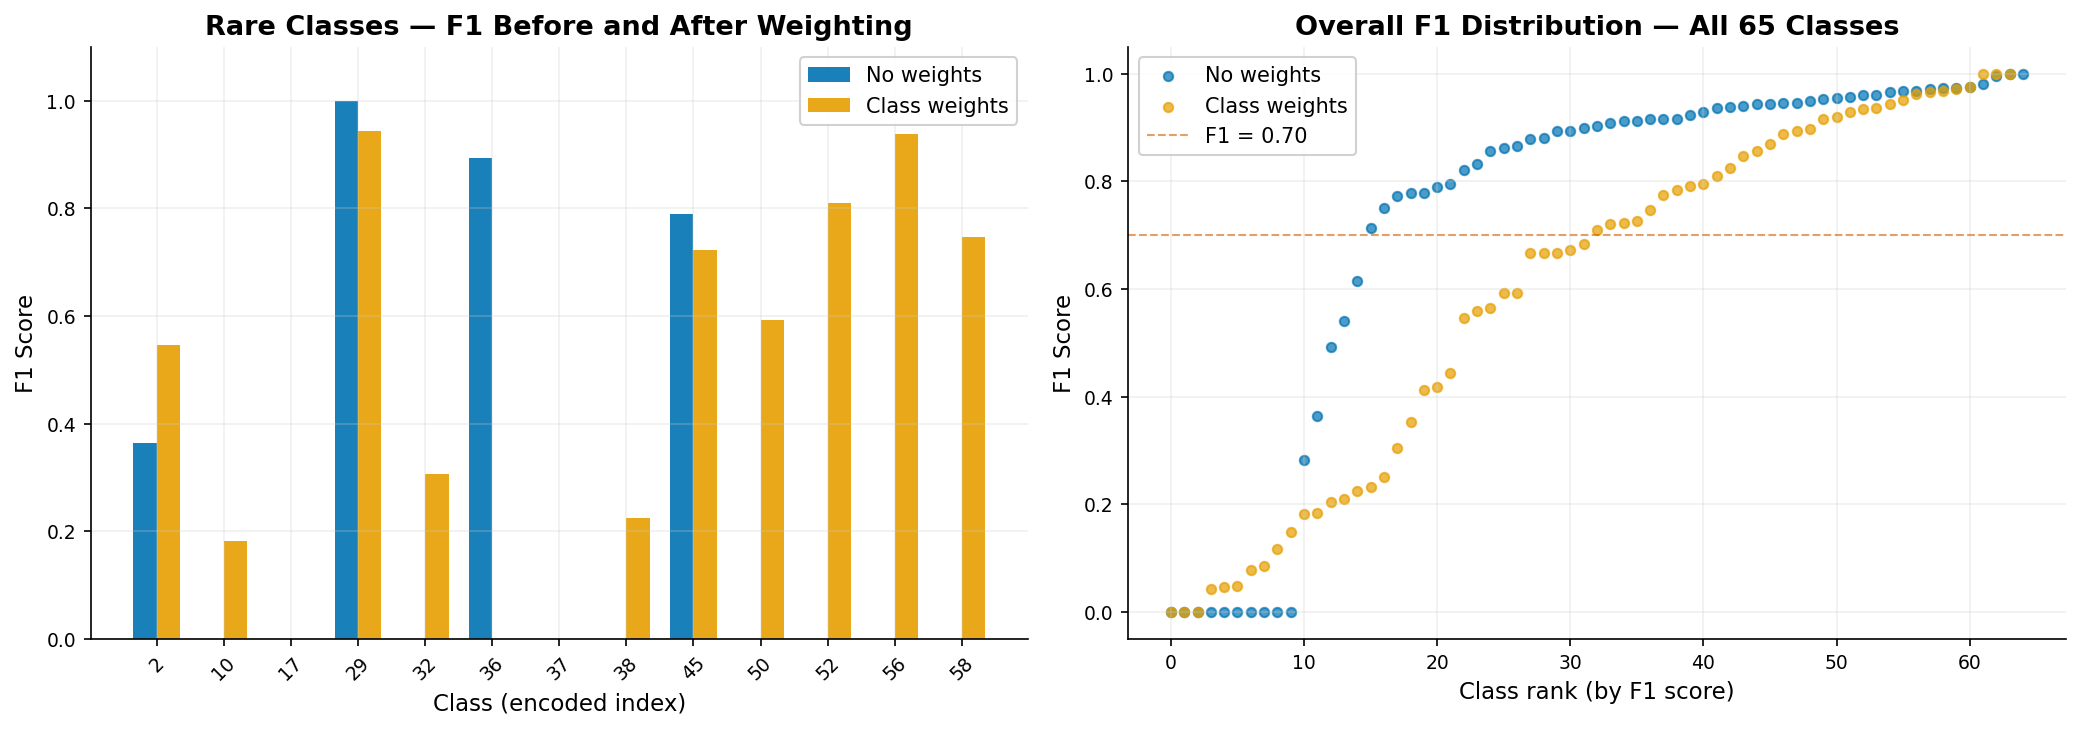

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Rare classes — where we hope weighting helps
rare_base = [f1_baseline[i] for i in rare_classes]
rare_wtd  = [f1_weighted[i] for i in rare_classes]
x = np.arange(len(rare_classes))
width = 0.35

ax1.bar(x - width/2, rare_base, width,
        color=COLORS["blue"],   label="No weights", alpha=0.9)
ax1.bar(x + width/2, rare_wtd,  width,
        color=COLORS["orange"], label="Class weights", alpha=0.9)
ax1.set_xticks(x)
ax1.set_xticklabels([str(i) for i in rare_classes], rotation=45)
ax1.set_ylim(0, 1.1)
ax1.set_xlabel("Class (encoded index)")
ax1.set_ylabel("F1 Score")
ax1.set_title("Rare Classes — F1 Before and After Weighting")
ax1.legend()

# Use the actual length of each f1 array rather than NUM_CLASSES
# so both scatter plots have matching x and y sizes
ax2.scatter(range(len(f1_baseline)), sorted(f1_baseline),
            color=COLORS["blue"],   s=20, alpha=0.7, label="No weights")
ax2.scatter(range(len(f1_weighted)), sorted(f1_weighted),
            color=COLORS["orange"], s=20, alpha=0.7, label="Class weights")
ax2.axhline(0.70, color=COLORS["red"], linestyle="--",
            linewidth=1.0, alpha=0.6, label="F1 = 0.70")
ax2.set_xlabel("Class rank (by F1 score)")
ax2.set_ylabel("F1 Score")
ax2.set_title("Overall F1 Distribution — All 65 Classes")
ax2.legend()

plt.tight_layout()
plt.savefig(f"{PROJECT}/imbalance_f1_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

**Final summary**

In [ ]:
acc_baseline = (y_pred_baseline == y_test).mean()
acc_weighted = (y_pred_weighted == y_test).mean()

macro_f1_baseline = f1_score(y_test, y_pred_baseline, average="macro",  zero_division=0)
macro_f1_weighted = f1_score(y_test, y_pred_weighted, average="macro",  zero_division=0)

rare_f1_baseline  = np.mean([f1_baseline[i] for i in rare_classes])
rare_f1_weighted  = np.mean([f1_weighted[i] for i in rare_classes])

print(f"{'Metric':<30} {'No weights':>12} {'Class weights':>14} {'Change':>8}")
print("-" * 68)
print(f"{'Overall accuracy':<30} {acc_baseline:>12.1%} {acc_weighted:>14.1%} {acc_weighted - acc_baseline:>+8.1%}")
print(f"{'Macro F1 (all classes)':<30} {macro_f1_baseline:>12.3f} {macro_f1_weighted:>14.3f} {macro_f1_weighted - macro_f1_baseline:>+8.3f}")
print(f"{'Mean F1 (rare classes only)':<30} {rare_f1_baseline:>12.3f} {rare_f1_weighted:>14.3f} {rare_f1_weighted - rare_f1_baseline:>+8.3f}")

plt.savefig(f"{PROJECT}/imbalance_summary.png", dpi=150, bbox_inches="tight")

Metric                           No weights  Class weights   Change
--------------------------------------------------------------------
Overall accuracy                      91.5%          43.5%   -48.0%
Macro F1 (all classes)                0.734          0.597   -0.137
Mean F1 (rare classes only)           0.234          0.462   +0.228


<Figure size 960x720 with 0 Axes>